# Exploring Methods for Constructing Business Corridors in Oakland

This notebook explores several **data-driven methods** for proposing candidate business
corridors / commercial districts across the City of Oakland, using the combined Oakland
business dataset, Alameda County parcel data, and the existing Oakland Business Improvement
District (BID) boundaries.

**This is an exploratory methodology notebook.** It is not an attempt to automatically define
final, official corridors. The outputs here -- maps, candidate polygons, and diagnostic tables --
are meant to be reviewed manually with City of Oakland staff, who will use local knowledge to
decide which candidate areas make sense, where boundaries should be split or merged, and what
is missing.

Throughout this notebook we use language like *candidate*, *plausible corridor*, *commercial
concentration*, and *review geometry*. We deliberately avoid words like *true* or *definitive*
boundary -- no method here produces a single correct answer, and several plausible outputs
are kept side-by-side for discussion rather than collapsed into one "best" system.

## What this notebook does

1. Loads and cleans the combined business dataset, Oakland parcels, and existing BIDs.
2. Builds a **physical-location** business layer (distinct from raw business/entity counts),
   excludes territory already covered by BIDs, and looks at the empirical geography of
   Oakland's commercial activity before doing any clustering.
3. Builds a common set of diagnostics that can score *any* candidate corridor polygon, so that
   different methods can be compared on equal footing.
4. Runs three different, methodologically distinct approaches to proposing corridors:
   - **Method 1**: a fine grid used to measure commercial intensity, converted to real parcel
     geometry (loosely inspired by Jeong, Allen & Chapple 2024 -- see below).
   - **Method 2**: density-based clustering of business locations, converted to parcel geometry.
   - **Method 3**: a parcel-native "seed and grow" approach driven by a transparent parcel-level
     commercial score.
5. Compares the three methods, looks at where they agree and disagree, and checks results
   against the scale of existing BIDs.
6. Builds three candidate **review packages** (Conservative / Balanced / Inclusive) and a set of
   review maps intended for a working session with City of Oakland colleagues.

## Relationship to earlier work

Two earlier notebooks are used as reference material (and are **not modified** here):

- `analysis/businesses/join_businesses_da_bl.ipynb` -- built the combined business dataset
  (`oakland_businesses_combined.csv`) used throughout this notebook, and documents the
  `commercial_relevance_class`, `home_business`, and `likely_property_license` fields.
- `analysis/prelim/identify_prelim_corridors_parcels.ipynb` -- an earlier exploration that
  tested DBSCAN clustering, grid-density thresholding, and parcel-connectivity blobs on an
  older, DataAxle-only business file. It found three recurring problems that this notebook
  is built to confront head-on rather than paper over:
  - **DBSCAN's mega-cluster problem** -- Oakland's dense flatlands (downtown through
    Fruitvale) tend to fuse into one enormous cluster at any practical `eps`.
  - **Grid boxiness** -- rectangular grid cells produce boxy, arbitrarily-aligned shapes and
    can miss long, thin commercial streets that straddle cell boundaries.
  - **Parcel connectivity's over-generosity** -- dissolving all commercially-zoned or
    business-containing parcels together can merge large regions and lets zoning/land use
    dominate over what businesses are actually observed on the ground.

## Relationship to Jeong, Allen & Chapple (2024)

Jeong, Allen & Chapple, *"A new commercial boundary dataset for metropolitan areas in the USA
and Canada, built from open data"* (Scientific Data, 2024), builds commercial boundaries for 69
North American metro areas by laying a fine (50 m) grid over each region, scoring each cell on
retail / office / job density using PCA, running an unsupervised image-segmentation model to
find clusters of high-scoring cells, and then removing weak or tiny polygons.

We borrow several of that paper's *principles*, adapted to a much richer, single-city context:

- **Combine several indicators of commercial intensity** rather than one raw point count.
- **Use a fine spatial unit** (a grid) as an intermediate step, not the final geometry.
- **Require spatial continuity** -- isolated high-scoring cells don't make a corridor.
- **Identify contiguous components** and drop weak or tiny ones.
- **Compare multiple spatial resolutions** rather than committing to one grid size.

We deliberately do **not** reproduce the neural-network / image-segmentation step. Oakland is
one city with an unusually rich, address-matched business register (Data Axle + City of
Oakland business licenses, already reconciled to physical locations) and detailed parcel
geometry -- a simpler, fully transparent pipeline is more appropriate here, and much easier to
explain and audit in a room with City staff. We also add two things the metro-wide paper does
not need: (1) explicit treatment of **existing BID boundaries** as already-settled districts to
build around, and (2) a final conversion step from grid/cluster geometry to **real parcel
geometry**, so a "corridor" is not just a patch of raster cells but a shape that traces actual
lots and street frontage.


## Code Cell 1 -- Imports

All imports used anywhere in the notebook are collected here. There are no imports later in
the notebook.

In [1]:
import os
import math
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Code Cell 2 -- Paths and Configurable Constants

Every path and every tunable parameter used in this notebook lives here. Nothing important is
hard-coded further down. Parameter choices are explained in the sections where they are first
used, and several of them (grid size, DBSCAN distance, parcel adjacency tolerance) are checked
against the empirical business-location geography in Section 4 before we commit to them.

In [2]:
# ---------------------------------------------------------------------------
# Source data paths (read-only -- never written to)
# ---------------------------------------------------------------------------
ROOT = Path("/home/aniket/Programming/eddit-east-bay")

BUSINESS_CSV = ROOT / "data/business/combined/oakland_businesses_combined.csv"
OAKLAND_BOUNDARY_SHP = ROOT / "data/geo/OaklandCityLimits/OaklandCityLimits.shp"
PARCELS_SHP = ROOT / "data/geo/Parcels_7711352183771741448/Parcel_Boundaries.shp"
BIDS_SHP = ROOT / "data/corridors/OAK_BIDs/OAK_BIDs.shp"
POLICY_POLYGONS_SHP = ROOT / "data/corridors/Policy_Polygons/Policy_Polygons.shp"

# ---------------------------------------------------------------------------
# Output locations (this notebook only ever writes here)
# ---------------------------------------------------------------------------
OUT_DIR = ROOT / "data/corridors/260910_report"
DIR_METHOD1 = OUT_DIR / "method_1_grid"
DIR_METHOD2 = OUT_DIR / "method_2_business_clusters"
DIR_METHOD3 = OUT_DIR / "method_3_parcel_growth"
DIR_COMPARISONS = OUT_DIR / "comparisons"
DIR_REVIEW = OUT_DIR / "review_packages"
DIR_DIAGNOSTICS = OUT_DIR / "diagnostics"

for d in [OUT_DIR, DIR_METHOD1, DIR_METHOD2, DIR_METHOD3, DIR_COMPARISONS, DIR_REVIEW, DIR_DIAGNOSTICS]:
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Coordinate reference systems
# ---------------------------------------------------------------------------
CRS_WGS84 = "EPSG:4326"       # for display / export only
PROJ_CRS = "EPSG:26910"       # NAD83 / UTM zone 10N (metres) -- see Section 1 for rationale

# ---------------------------------------------------------------------------
# Business-location universe definitions (Section 2)
# ---------------------------------------------------------------------------
# A location is excluded from the commercial-focused universe (Universe B) only when EVERY
# business registered there is a pure property/rental-license artifact, or EVERY business
# registered there is explicitly flagged as home-based. Otherwise it stays in.

# ---------------------------------------------------------------------------
# BID exclusion (Section 3)
# ---------------------------------------------------------------------------
BID_RESIDUAL_OVERLAP_PCT_FLAG = 5.0   # flag a candidate if >this % of its area still overlaps a BID

# ---------------------------------------------------------------------------
# Method 1 -- grid parameters (Section 6)
# ---------------------------------------------------------------------------
GRID_CELL_SIZES_M = [50, 75, 100]
GRID_SMOOTH_RADIUS_CELLS = 1                 # focal window radius, in cells, for smoothing
GRID_INTENSITY_QUANTILES = [0.85, 0.90, 0.95]
GRID_ADJACENCY_GAPS = [0, 1]                 # 0 = strict queen adjacency, 1 = allow a 1-cell gap
GRID_MIN_COMPONENT_CELLS = 3                 # drop components smaller than this many cells
GRID_GIANT_COMPONENT_CELLS_FLAG = 500        # flag components at/above this many cells as "giant"

# ---------------------------------------------------------------------------
# Method 2 -- business-cluster parameters (Section 7)
# ---------------------------------------------------------------------------
DBSCAN_EPS_VALUES_M = [70, 100, 130]
DBSCAN_MIN_SAMPLES = 5
MEGA_CLUSTER_LOCATIONS_FLAG = 1000           # a cluster at/above this size is flagged "mega"
MEGA_CLUSTER_SPLIT_EPS_M = 50                # tighter eps used to re-cluster mega-clusters
MEGA_CLUSTER_SPLIT_MIN_SAMPLES = 5

# ---------------------------------------------------------------------------
# Method 3 -- parcel seed-and-grow parameters (Section 8)
# ---------------------------------------------------------------------------
PARCEL_SCORE_LOCATION_WEIGHT = 2.0            # weight on log(1 + commercial-focused locations)
PARCEL_SCORE_USECODE_WEIGHT = 1.0             # weight on the 3/8/9 use-code flag
PARCEL_SCORE_EMPLOYEE_WEIGHT = 0.5            # weight on log(1 + employees)
SEED_SCORE_QUANTILES = [0.75, 0.90, 0.95]     # candidate seed thresholds (within score>0 parcels)
WEAK_SCORE_QUANTILES = [0.0, 0.25, 0.50]      # candidate bridging thresholds (within score>0 parcels)

# ---------------------------------------------------------------------------
# Shared parcel / geometry parameters
# ---------------------------------------------------------------------------
PARCEL_ADJACENCY_TOLERANCE_M = 12    # buffer distance used to treat nearby parcels as "touching"
                                       # (bridges alleys / narrow streets -- motivated in Section 4)
GRID_TO_PARCEL_BRIDGE_TOLERANCE_M = 12

# ---------------------------------------------------------------------------
# Candidate pruning thresholds (used across all three methods)
# ---------------------------------------------------------------------------
MIN_LOCATIONS_PER_CANDIDATE = 3      # drop candidate corridors with fewer commercial-focused locations
MIN_CANDIDATE_AREA_HA = 0.15         # drop trivially small slivers

# ---------------------------------------------------------------------------
# Cross-method comparison / agreement grid (Sections 10 & 13)
# ---------------------------------------------------------------------------
AGREEMENT_GRID_CELL_SIZE_M = 50

# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
FIGSIZE_CITYWIDE = (9, 11)
FIGSIZE_SMALL_MULTIPLE = (6, 7)
DPI_SAVE = 150
BID_COLOR = "#444444"
OAKLAND_EDGE_COLOR = "#999999"


# Section 1 -- Load and Understand the Input Data

**Question:** what do we actually have to work with, and in what shape?

**Why this matters:** every method downstream depends on (a) the business data actually
representing real, geocoded Oakland locations, (b) the parcel and BID/policy layers lining up
spatially with those points, and (c) all of it being in a projected coordinate system suitable
for distance and area calculations. Getting this wrong quietly breaks everything later.

**What we look for:** row/feature counts, CRS of each source file, missing coordinates or
geometry, and a sanity-checked bounding extent. We also settle on one working coordinate
system for the rest of the notebook.

**Choice of projected CRS:** the source files arrive in a mix of CRSs -- WGS84 (business
lat/lon), EPSG:4269 (BIDs, Policy Polygons), and EPSG:3857 / Web Mercator (Oakland boundary,
parcels). None of these are appropriate for measuring distance or area: geographic CRSs
(4326/4269) have no consistent unit of length, and Web Mercator (3857) distorts area
substantially away from the equator (an earlier exploratory notebook used 3857 for buffering
and area work -- we deliberately do not repeat that here). We reproject everything to
**EPSG:26910 (NAD83 / UTM Zone 10N)**, a metre-based projected CRS that is the standard choice
for Northern California / the Bay Area and introduces negligible distortion at Oakland's scale.
WGS84 is kept only for the handful of places where we export or display in lat/lon.

In [3]:
# ---- Oakland boundary ----
oakland = gpd.read_file(OAKLAND_BOUNDARY_SHP)
print(f"Oakland boundary: {len(oakland)} feature(s), source CRS {oakland.crs}")
oakland = oakland.to_crs(PROJ_CRS)
oakland["geometry"] = oakland.geometry.buffer(0)
oakland_boundary = oakland.geometry.union_all()
print(f"Oakland boundary area: {oakland_boundary.area / 1e6:,.1f} km^2 (land + bay water within city limits)")
print(f"Oakland boundary valid: {oakland_boundary.is_valid}")


Oakland boundary: 1 feature(s), source CRS EPSG:3857
Oakland boundary area: 201.9 km^2 (land + bay water within city limits)
Oakland boundary valid: True


In [4]:
# ---- Business Improvement Districts (existing, already-defined commercial districts) ----
bids = gpd.read_file(BIDS_SHP)
print(f"BIDs: {len(bids)} features, source CRS {bids.crs}")
bids = bids.to_crs(PROJ_CRS)
bids["geometry"] = bids.geometry.buffer(0)
print(bids[["BID"]].to_string(index=False))
bid_union = unary_union(bids.geometry.values)
print(f"\nTotal BID area: {bid_union.area / 1e4:,.1f} ha across {len(bids)} districts")


BIDs: 11 features, source CRS EPSG:4269
                BID
           Downtown
          Chinatown
       Lake Merritt
Koreatown/Northgate
          Montclair
          Rockridge
 Temescal/Telegraph
          Fruitvale
          Lakeshore
        Jack London
             Laurel

Total BID area: 399.5 ha across 11 districts


In [5]:
# ---- Policy Polygons (contextual / optional comparison only -- not used to define methods) ----
policy_polygons = gpd.read_file(POLICY_POLYGONS_SHP)
print(f"Policy Polygons: {len(policy_polygons)} features, source CRS {policy_polygons.crs}")
policy_polygons = policy_polygons.to_crs(PROJ_CRS)
policy_polygons["geometry"] = policy_polygons.geometry.buffer(0)
name_col = "PP_Name" if "PP_Name" in policy_polygons.columns else policy_polygons.columns[0]
print(policy_polygons[[name_col]].to_string(index=False))


Policy Polygons: 9 features, source CRS EPSG:4269
           PP_Name
   Seventh Thrives
    West Oakland S
     Little Saigon
   Hegenberger_BID
           Beat19x
     Fruitvale_BID
Telegraph Triangle
       Old_Oakland
            Dimond


In [6]:
# ---- Parcels (Alameda County-wide file, clipped to Oakland) ----
# The source shapefile covers all of Alameda County (~490k parcels), so we use a bounding-box
# read to avoid loading everything, then clip precisely to the Oakland city limits.
oakland_bounds_native = gpd.read_file(OAKLAND_BOUNDARY_SHP).total_bounds
parcels_raw = gpd.read_file(PARCELS_SHP, bbox=tuple(oakland_bounds_native))
print(f"Parcels read within Oakland bounding box: {len(parcels_raw):,}, source CRS {parcels_raw.crs}")

parcels_raw = parcels_raw.to_crs(PROJ_CRS)
n_invalid = (~parcels_raw.geometry.is_valid).sum()
print(f"Invalid parcel geometries before repair: {n_invalid:,}")
parcels_raw["geometry"] = parcels_raw.geometry.buffer(0)   # standard, defensible repair for ring/self-intersection issues
parcels_raw = parcels_raw[parcels_raw.geometry.is_valid & ~parcels_raw.geometry.is_empty]
print(f"Invalid parcel geometries after buffer(0) repair: {(~parcels_raw.geometry.is_valid).sum():,}")

parcels = gpd.clip(parcels_raw, oakland).reset_index(drop=True)
parcels["UseCode_str"] = parcels["UseCode"].astype(str).str.zfill(4)
parcels["parcel_uid"] = parcels.index.astype(str)
print(f"Parcels clipped to Oakland city limits: {len(parcels):,}")
print(f"\nTop UseCode prefixes (first digit) among Oakland parcels:")
print(parcels["UseCode_str"].str[0].value_counts().sort_index())


Parcels read within Oakland bounding box: 205,427, source CRS EPSG:3857


Invalid parcel geometries before repair: 33


Invalid parcel geometries after buffer(0) repair: 0


Parcels clipped to Oakland city limits: 113,834

Top UseCode prefixes (first digit) among Oakland parcels:
UseCode_str
0     3247
1    69695
2    14867
3     3434
4     2024
5        6
6      714
7    17803
8      976
9      967
N      101
Name: count, dtype: int64


**Note on Piedmont:** Piedmont is an independent city entirely surrounded by Oakland. The
Oakland city-limits polygon already has a Piedmont-shaped hole in it, and `gpd.clip` respects
that hole -- we do not fill it in. Every map and every parcel/business filter in this notebook
therefore correctly excludes Piedmont, along with Berkeley, Emeryville, Alameda, San Leandro,
and any other neighboring jurisdiction, without any extra code.

In [7]:
# ---- Parcel use codes: what do we actually have? ----
# The earlier exploratory notebook (identify_prelim_corridors_parcels.ipynb) used UseCode
# prefixes 3 (commercial), 8 (institutional/public), and 9 (miscellaneous/special) as an
# initial commercial/institutional parcel universe. No text description field ships with this
# parcel file, so we cannot look up what every code means -- we treat 3/8/9 as the INITIAL
# relevant universe (per that earlier convention) and separately check whether any business
# activity is concentrated in codes outside that set (Section 8 checks this directly).
usecode_counts = parcels["UseCode_str"].value_counts().head(15)
print("Most common UseCode values in Oakland parcels:")
print(usecode_counts)

parcels["relevant_usecode"] = parcels["UseCode_str"].str[0].isin(["3", "8", "9"])
print(f"\nParcels with UseCode prefix 3/8/9: {parcels['relevant_usecode'].sum():,} of {len(parcels):,} "
      f"({parcels['relevant_usecode'].mean()*100:.1f}%)")


Most common UseCode values in Oakland parcels:
UseCode_str
1100    63274
7300    11395
2200     4663
0300     2833
1000     2715
7700     2653
2500     2536
2400     2521
2100     1587
2300     1305
1500     1229
3200     1191
3100      966
7390      927
7305      906
Name: count, dtype: int64

Parcels with UseCode prefix 3/8/9: 5,377 of 113,834 (4.7%)


### Interpretation

Oakland has about 114,000 parcels within the city limits (including the bay-adjacent areas
inside the municipal boundary). Roughly 5% carry a UseCode beginning with 3, 8, or 9. The single
most common UseCode in the data (`7300`) is *not* in that set and accounts for a large share of
parcels on its own -- we don't know its exact definition without a code table, but its sheer
volume relative to 3/8/9 codes suggests it is a common, likely non-commercial category (e.g.
single-unit residential or a similar mass category), which is consistent with treating 3/8/9 as
a deliberately narrow starting universe rather than "most of Oakland's land." Section 8 checks
directly whether business activity is showing up on parcels *outside* this initial universe, and
reports what we find rather than assuming the 3/8/9 rule is complete.

In [8]:
# ---- Combined business dataset ----
business_raw = pd.read_csv(BUSINESS_CSV, low_memory=False)
print(f"Business/entity rows: {len(business_raw):,}")
print(f"Columns ({len(business_raw.columns)}): {list(business_raw.columns)}")
print(f"\nUnique canonical_business_id (entities): {business_raw['canonical_business_id'].nunique():,}")
print(f"Unique location_id (physical locations): {business_raw['location_id'].nunique():,}")
n_missing_coords = business_raw[["latitude", "longitude"]].isna().any(axis=1).sum()
print(f"Rows missing latitude/longitude: {n_missing_coords:,}")
print(f"\nsource_type breakdown:\n{business_raw['source_type'].value_counts()}")
print(f"\nbroad_sector breakdown:\n{business_raw['broad_sector'].value_counts()}")
print(f"\ncommercial_relevance_class breakdown:\n{business_raw['commercial_relevance_class'].value_counts()}")


Business/entity rows: 71,623
Columns (56): ['canonical_business_id', 'location_id', 'business_name', 'address', 'address_base', 'unit', 'zip5', 'latitude', 'longitude', 'broad_sector', 'home_business', 'likely_property_license', 'commercial_relevance_class', 'employee_range', 'employees', 'sales_range', 'sales', 'year_established', 'years_in_database', 'in_data_axle', 'in_business_license', 'source_count', 'source_type', 'da_source_record_id', 'bl_source_record_id', 'match_method', 'match_confidence', 'coord_distance_m', 'coord_flag', 'sector_conflict', 'ambiguous_shared_location', 'naics_da', 'naics_desc_da', 'sic_da', 'sic_desc_da', 'naics_bl', 'naics_desc_bl', 'sector_da', 'sector_bl', 'latitude_da', 'longitude_da', 'latitude_bl', 'longitude_bl', 'address_da_original', 'address_bl_original', 'location_type_da', 'type_of_business_da', 'franchise_da', 'affiliated_records_da', 'affiliated_locations_da', 'square_footage_da', 'credit_score_da', 'phone_da', 'own_or_lease_da', 'firm_or_ind

### Interpretation

The combined file has about 71,600 business/entity rows but only about 37,900 unique physical
locations -- confirming the key structural point from the project brief: **many businesses share
a location** (professional buildings, medical suites, multi-tenant retail, etc.). A small number
of rows (under 1%) are missing coordinates and will be dropped. `commercial_relevance_class` and
`broad_sector` are both usable out of the box -- `office_or_professional` is the largest class,
which is expected given how much of Data Axle's coverage is business-license driven and skews
toward office/finance/real-estate registrations. Section 2 investigates this further, because
that class also contains most of the property-license artifacts we will want to identify.

# Section 2 -- Build the Business-Location Analysis Layer

**Question:** what is the right spatial unit for measuring commercial concentration, and which
locations should count as evidence of a commercial corridor?

**Why this matters:** a naive approach would treat every row in the combined CSV (every
business *entity*) as one independent point in space. But a single office building with 20
tenant businesses is not the same spatial signal as 20 separate storefronts along a block --
counting entities would massively over-weight multi-tenant buildings relative to real
storefront density. We build both levels, but use the **physical location** as the basic
spatial unit for density and clustering.

**What we look for:** how much entity counts and location counts actually diverge (they
diverge a lot -- see Section 1), and a location-level table with enough descriptive attributes
that we can build a sensible "commercial-focused" subset without arbitrary blanket exclusions.

In [9]:
# ---- A. Business entity level: build the point layer, clip to Oakland ----
biz_valid = business_raw.dropna(subset=["latitude", "longitude"]).copy()
entities = gpd.GeoDataFrame(
    biz_valid,
    geometry=gpd.points_from_xy(biz_valid["longitude"], biz_valid["latitude"]),
    crs=CRS_WGS84,
).to_crs(PROJ_CRS)

n_before = len(entities)
entities = gpd.clip(entities, oakland)
print(f"Entities with valid coordinates: {n_before:,} -> clipped to Oakland: {len(entities):,}")
print(f"Unique physical locations within Oakland: {entities['location_id'].nunique():,}")


Entities with valid coordinates: 71,178 -> clipped to Oakland: 70,943
Unique physical locations within Oakland: 37,680


In [10]:
# ---- B. Physical location level: aggregate entity attributes up to one row per location ----
def _mode_or_first(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]

entities["_home_flag"] = entities["home_business"].fillna(0).astype(float)

locations = entities.groupby("location_id").agg(
    n_entities=("canonical_business_id", "nunique"),
    broad_sector_mode=("broad_sector", _mode_or_first),
    n_sectors=("broad_sector", lambda s: s.dropna().nunique()),
    commercial_relevance_mode=("commercial_relevance_class", _mode_or_first),
    any_home_business=("_home_flag", lambda s: bool((s == 1).any())),
    all_home_business=("_home_flag", lambda s: bool((s == 1).all()) if len(s) else False),
    share_home_business=("_home_flag", "mean"),
    any_property_license=("likely_property_license", "any"),
    all_property_license=("likely_property_license", "all"),
    employees_total=("employees", lambda s: s.sum(min_count=1)),
    employees_median=("employees", "median"),
    any_data_axle=("in_data_axle", "any"),
    any_business_license=("in_business_license", "any"),
    latitude=("latitude", "first"),
    longitude=("longitude", "first"),
).reset_index()

# share of businesses at this location that are consumer-facing (retail/food/etc.)
cf_share = (
    entities.groupby("location_id")["commercial_relevance_class"]
    .apply(lambda s: (s == "consumer_facing").mean())
    .rename("share_consumer_facing")
)
locations = locations.merge(cf_share, on="location_id", how="left")

geom_lookup = entities.drop_duplicates("location_id").set_index("location_id").geometry
locations = locations.set_index("location_id")
locations["geometry"] = geom_lookup
locations = gpd.GeoDataFrame(locations.reset_index(), geometry="geometry", crs=PROJ_CRS)

print(f"Physical locations: {len(locations):,}")
locations[["n_entities", "n_sectors"]].describe()


Physical locations: 37,680


,n_entities,n_sectors
count,37680.000000,37680.000000
mean,1.882776,1.306741
std,8.456879,0.946212
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,704.000000,15.000000


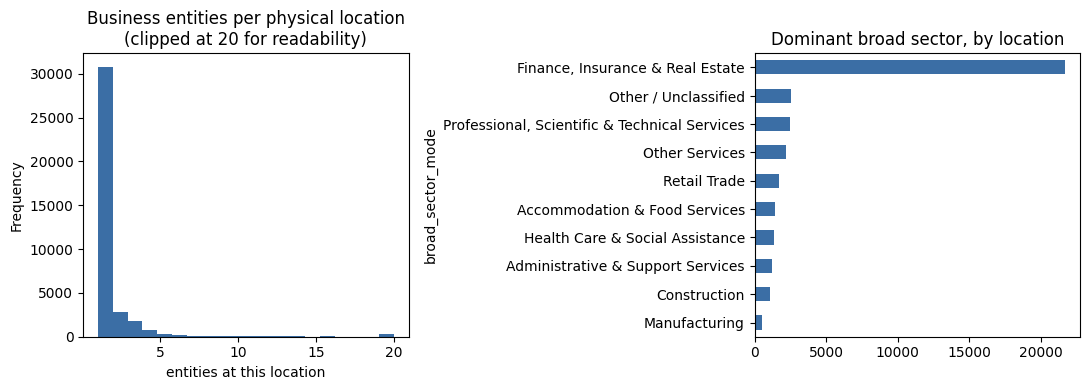

Locations with >1 entity: 6,859 (18.2% of all locations)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
locations["n_entities"].clip(upper=20).plot(kind="hist", bins=20, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Business entities per physical location\n(clipped at 20 for readability)")
axes[0].set_xlabel("entities at this location")

locations["broad_sector_mode"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="#3b6ea5")
axes[1].invert_yaxis()
axes[1].set_title("Dominant broad sector, by location")
plt.tight_layout()
plt.show()
print(f"Locations with >1 entity: {(locations['n_entities'] > 1).sum():,} "
      f"({(locations['n_entities'] > 1).mean()*100:.1f}% of all locations)")


### Defining two business-location universes

**Universe A -- Broad.** Every physical location in Oakland with a valid geocode. This is the
inclusive baseline and is used only for descriptive comparison later.

**Universe B -- Commercial-focused.** Starts from Universe A and removes only two well-defined,
transparent categories of locations that are unlikely to represent an actual storefront or
workplace presence on a commercial street:

- locations where **every** business record is a likely property/rental-license artifact
  (`all_property_license`) -- these come from BL's lessor/property-management NAICS text match,
  and represent landlords registering a rental license, not an operating business;
- locations where **every** business record is explicitly flagged home-based
  (`all_home_business`) -- a residential address with a registered home business is not, on its
  own, evidence of commercial-corridor activity.

We deliberately do **not** filter on sector or `commercial_relevance_class` here. Health care,
professional/office uses, and industrial/logistics locations all stay in Universe B -- the goal
is only to strip out the two clearest sources of noise (rental-license paperwork, and
registered-but-residential businesses), not to pre-judge which *kinds* of businesses count as
corridor-relevant.

In [12]:
excluded_mask = locations["all_property_license"] | locations["all_home_business"]
locations["universe_b"] = ~excluded_mask

universe_summary = pd.DataFrame({
    "Universe A (broad)": [
        len(locations), locations["n_entities"].sum(),
        (locations["broad_sector_mode"] == "Finance, Insurance & Real Estate").mean() * 100,
        locations["any_home_business"].mean() * 100,
        locations["any_property_license"].mean() * 100,
    ],
    "Universe B (commercial-focused)": [
        locations["universe_b"].sum(), locations.loc[locations["universe_b"], "n_entities"].sum(),
        (locations.loc[locations["universe_b"], "broad_sector_mode"] == "Finance, Insurance & Real Estate").mean() * 100,
        locations.loc[locations["universe_b"], "any_home_business"].mean() * 100,
        locations.loc[locations["universe_b"], "any_property_license"].mean() * 100,
    ],
}, index=["unique locations", "business entities", "% FIRE sector", "% any home business", "% any property license"])
universe_summary.round(1)


,Universe A (broad),Universe B (commercial-focused)
unique locations,37680.0,18377.0
business entities,70943.0,51410.0
% FIRE sector,57.4,24.4
% any home business,6.6,2.8
% any property license,52.7,12.5


In [13]:
print("Universe B commercial_relevance_class mix:")
print(locations.loc[locations["universe_b"], "commercial_relevance_mode"].value_counts())
print(f"\nUniverse B as a share of Universe A: {locations['universe_b'].mean()*100:.1f}%")


Universe B commercial_relevance_class mix:
commercial_relevance_mode
consumer_facing            7882
office_or_professional     6847
industrial_or_logistics    1962
other                      1686
Name: count, dtype: int64

Universe B as a share of Universe A: 48.8%


### Interpretation

Universe B keeps about half of all Oakland business locations (roughly 18,000 of 37,700), and
the exclusion is driven almost entirely by the property-license artifact rule -- most excluded
locations are Finance/Insurance/Real Estate addresses that are, on inspection, landlords
registering a license rather than a business operating there. Health care, retail,
food/accommodation, and professional-services locations are essentially untouched by this
filter. We use **Universe B** as the main input for corridor discovery for the rest of the
notebook, but the earlier exploratory notebook's DBSCAN/grid/parcel approaches all showed
sensitivity to which business subset feeds them -- so later sections check whether major
results (component counts, sizes, and locations) change materially if Universe A is used
instead.

# Section 3 -- Remove Existing BID Territory

**Question:** which business locations already sit inside a recognized, existing commercial
district?

**Why this matters:** the eleven Oakland BIDs (Downtown, Chinatown, Lake Merritt, Koreatown/
Northgate, Montclair, Rockridge, Temescal/Telegraph, Fruitvale, Lakeshore, Jack London, and
Laurel) are already-defined, City-recognized commercial districts. Our goal is to propose
*additional or complementary* candidate districts, not to redraw or subdivide ones that already
exist. Everything from here on discovers corridors primarily from business locations **outside**
BID territory.

**Assumption:** we exclude locations by point-in-polygon membership against the union of all
BID polygons -- no extra buffer is added around BIDs at this stage. The goal is to avoid
duplicating an existing district, not to suppress genuinely distinct nearby streets.

In [14]:
locations["in_bid"] = locations.geometry.within(bid_union)

n_total = len(locations)
n_in_bid = int(locations["in_bid"].sum())
n_outside = n_total - n_in_bid
print(f"Total Oakland business locations: {n_total:,}")
print(f"  inside a BID:  {n_in_bid:,} ({n_in_bid/n_total*100:.1f}%)")
print(f"  outside BIDs:  {n_outside:,} ({n_outside/n_total*100:.1f}%)")

outside_b = locations[(~locations["in_bid"]) & (locations["universe_b"])].copy().reset_index(drop=True)
print(f"\nUniverse B (commercial-focused) locations outside BIDs: {len(outside_b):,}")
print("This is the primary discovery layer used by Methods 1-3 below.")


Total Oakland business locations: 37,680
  inside a BID:  3,496 (9.3%)
  outside BIDs:  34,184 (90.7%)

Universe B (commercial-focused) locations outside BIDs: 15,252
This is the primary discovery layer used by Methods 1-3 below.


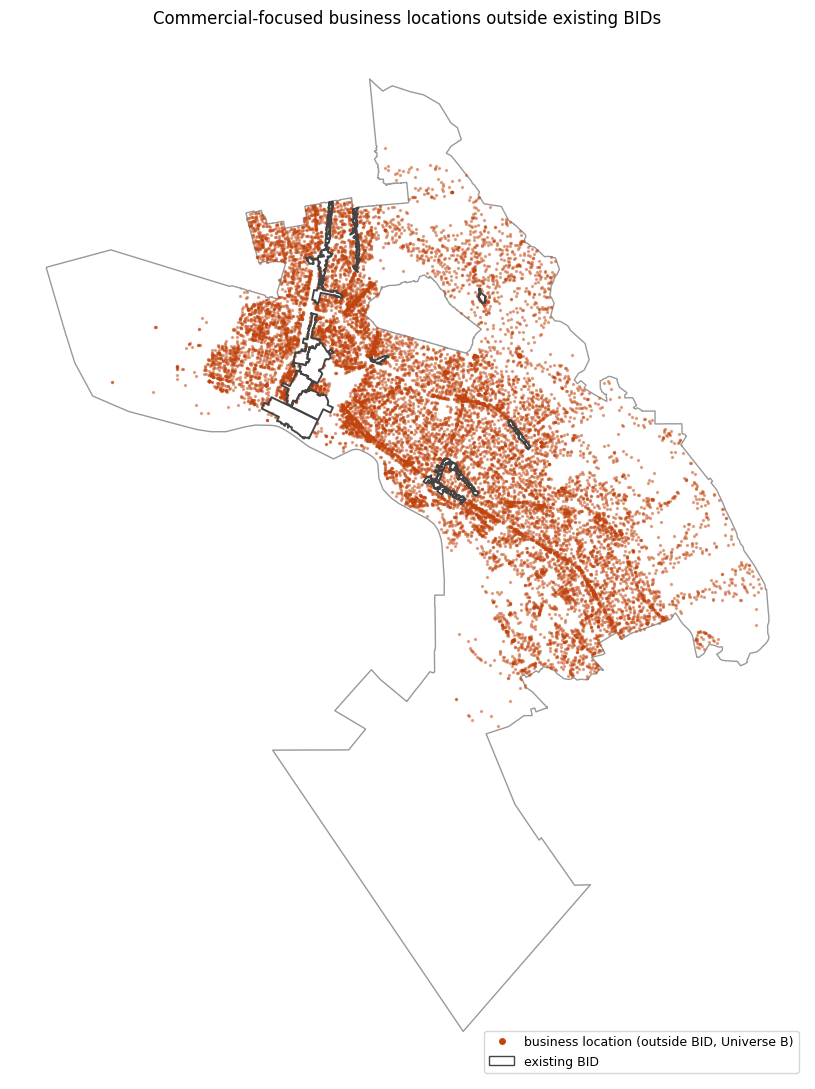

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=1)
bids.plot(ax=ax, facecolor="none", edgecolor=BID_COLOR, linewidth=1.4, zorder=3)
outside_b.plot(ax=ax, markersize=2, color="#c1440e", alpha=0.4, zorder=2)
ax.set_title("Commercial-focused business locations outside existing BIDs", fontsize=12)
ax.set_axis_off()
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor="#c1440e", markersize=6,
                   label="business location (outside BID, Universe B)"),
           mpatches.Patch(facecolor="none", edgecolor=BID_COLOR, label="existing BID")]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(DIR_DIAGNOSTICS / "outside_bid_locations.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

Only about 9-10% of Oakland's business locations sit inside an existing BID -- consistent with
the earlier finding (in `identify_prelim_corridors_parcels.ipynb`) that existing corridor
definitions cover a small minority of the city's business geography. The vast majority of
Oakland's commercial activity is *not* inside a recognized district, which is exactly the space
Methods 1-3 are meant to explore. Visually, the outside-BID locations are not randomly
scattered -- they trace clear linear patterns along arterial streets, with the densest
concentration in the flatlands corridor running from downtown through Fruitvale, plus visibly
distinct nodes in North Oakland, the Laurel/MacArthur corridor, and East Oakland business
strips. This is the same "flatlands mega-concentration" pattern the earlier notebook flagged as
the central challenge for clustering methods.

# Section 4 -- Understand Commercial Geography Before Clustering

**Question:** at what spatial scale does Oakland's business activity actually cluster, and
what does the underlying parcel geography look like, before we pick any clustering parameters?

**Why this matters:** every method below needs at least one distance parameter (a grid cell
size, a DBSCAN `eps`, a parcel-adjacency tolerance). Rather than guessing, we look at the
empirical nearest-neighbour geography of commercial-focused business locations and let that
motivate the ranges we test.

**What we look for:** how tightly businesses bunch together typically (1st nearest neighbour),
how far apart small clumps of ~5 businesses tend to be (5th nearest neighbour), and how
business presence and parcel land use relate to each other.

In [16]:
# ---- Join business locations to parcels once; reused throughout the rest of the notebook ----
join_outside_b = gpd.sjoin(
    outside_b[["location_id", "n_entities", "employees_total", "commercial_relevance_mode", "broad_sector_mode", "geometry"]],
    parcels[["parcel_uid", "geometry"]],
    how="inner", predicate="within",
)
parcel_biz_outside_b = join_outside_b.groupby("parcel_uid").agg(
    n_locations_comm=("location_id", "nunique"),
    n_entities_comm=("n_entities", "sum"),
    employees_comm=("employees_total", lambda s: s.sum(min_count=1)),
    n_sectors_comm=("broad_sector_mode", "nunique"),
).reset_index()

join_all = gpd.sjoin(
    locations[["location_id", "n_entities", "geometry"]],
    parcels[["parcel_uid", "geometry"]],
    how="inner", predicate="within",
)
parcel_biz_all = join_all.groupby("parcel_uid").agg(
    n_locations_any=("location_id", "nunique"),
    n_entities_any=("n_entities", "sum"),
).reset_index()

parcels = parcels.merge(parcel_biz_outside_b, on="parcel_uid", how="left").merge(parcel_biz_all, on="parcel_uid", how="left")
for c in ["n_locations_comm", "n_entities_comm", "n_sectors_comm", "n_locations_any", "n_entities_any"]:
    parcels[c] = parcels[c].fillna(0)
parcels["employees_comm"] = parcels["employees_comm"].fillna(0)
parcels["has_business_comm"] = parcels["n_locations_comm"] > 0
parcels["in_bid"] = parcels.geometry.centroid.within(bid_union)

print(f"Parcels containing >=1 Universe-B location (any BID status): {parcels['has_business_comm'].sum():,}")
print(f"Parcels containing >=1 business, any universe (any BID status): {(parcels['n_locations_any']>0).sum():,}")
print(f"Entities per location, aggregated up to the parcel level (mean, business-containing parcels): "
      f"{parcels.loc[parcels['n_locations_any']>0,'n_entities_any'].sum() / parcels.loc[parcels['n_locations_any']>0,'n_locations_any'].sum():.2f} "
      f"-- pulled well above the citywide ~1.9 by a handful of large multi-tenant buildings")


Parcels containing >=1 Universe-B location (any BID status): 7,674
Parcels containing >=1 business, any universe (any BID status): 14,936
Entities per location, aggregated up to the parcel level (mean, business-containing parcels): 8.93 -- pulled well above the citywide ~1.9 by a handful of large multi-tenant buildings


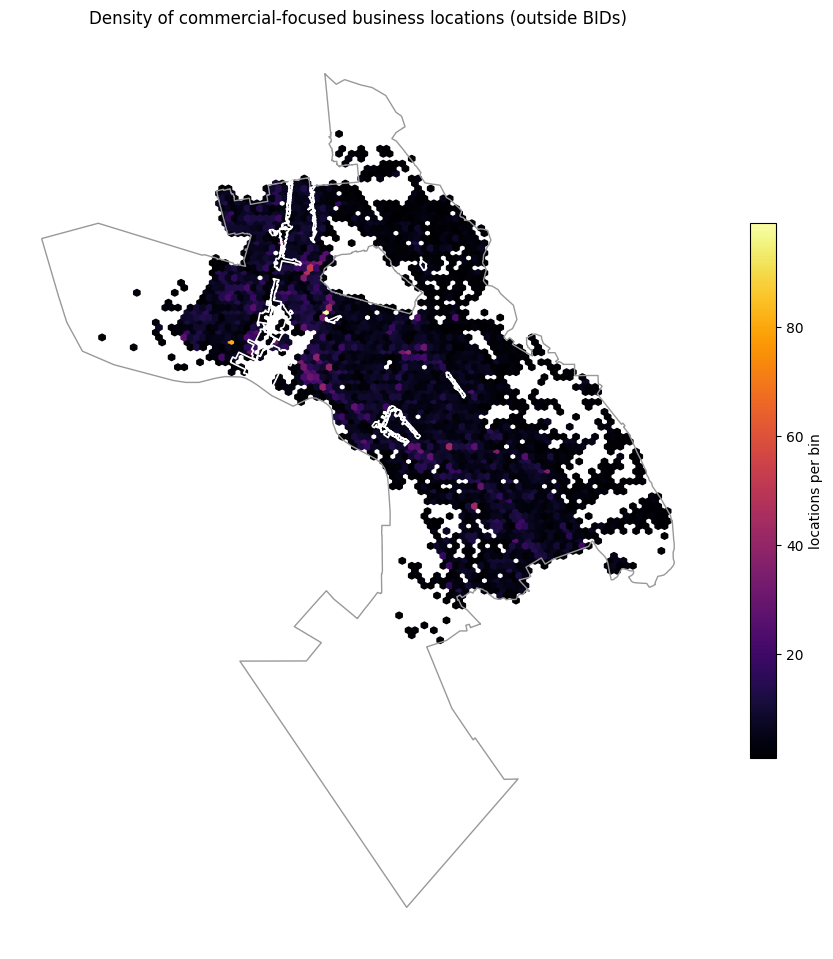

In [17]:
# ---- 1. Business-location density (hexbin) ----
fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=1, zorder=3)
hb = ax.hexbin(outside_b.geometry.x, outside_b.geometry.y, gridsize=90, cmap="inferno", mincnt=1, zorder=2)
bids.boundary.plot(ax=ax, color="white", linewidth=1.2, zorder=4)
ax.set_title("Density of commercial-focused business locations (outside BIDs)", fontsize=12)
ax.set_axis_off()
fig.colorbar(hb, ax=ax, shrink=0.5, label="locations per bin")
plt.tight_layout()
plt.savefig(DIR_DIAGNOSTICS / "business_density_hexbin.png", dpi=DPI_SAVE)
plt.show()


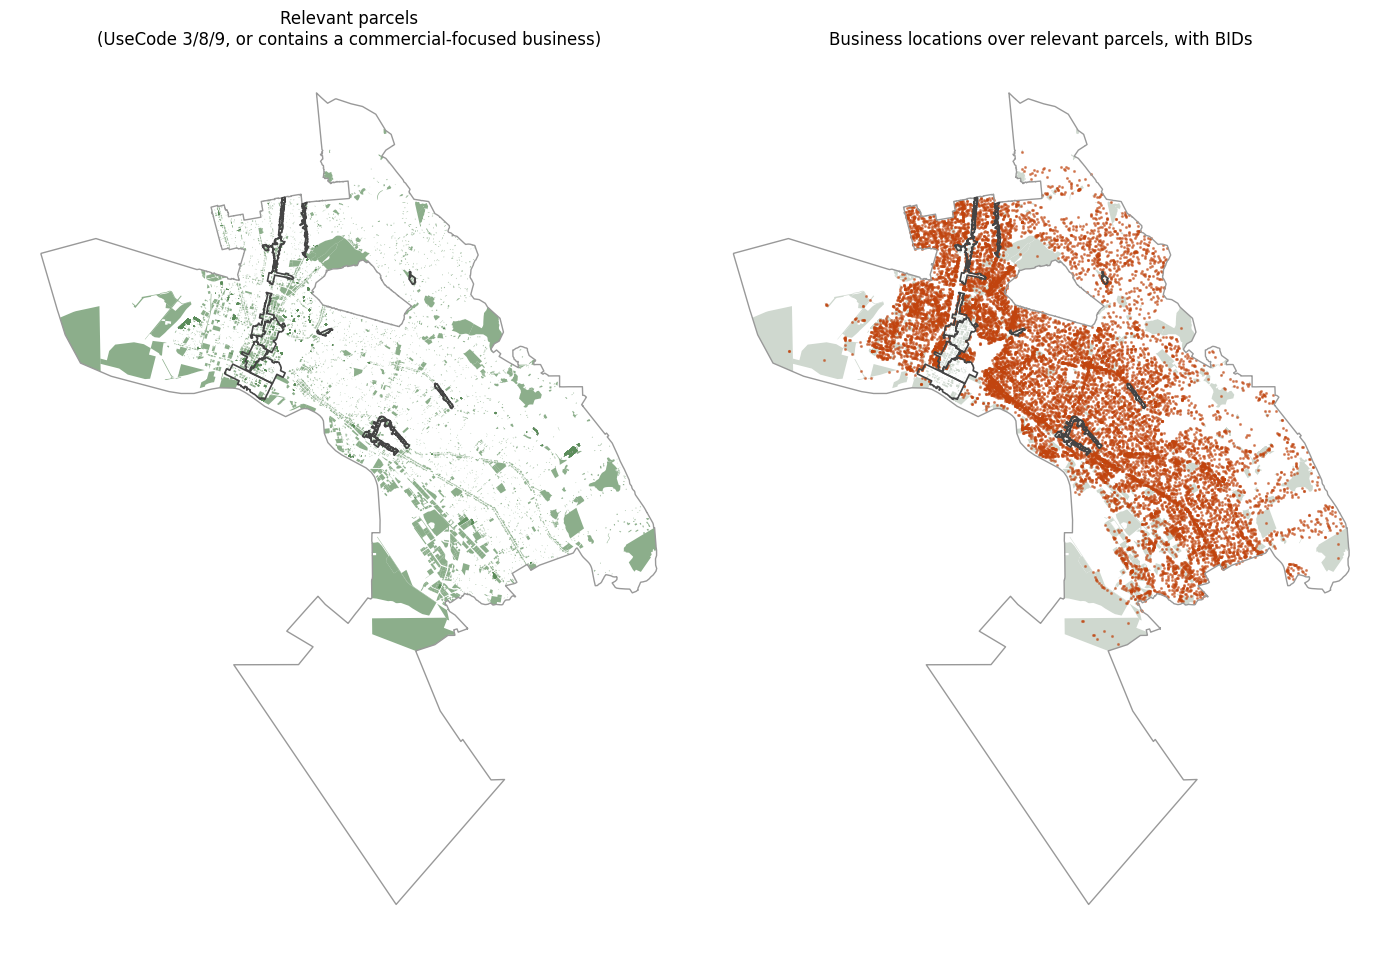

In [18]:
# ---- 2 & 3. Relevant parcels, and business locations over parcels, with BIDs for context ----
fig, axes = plt.subplots(1, 2, figsize=(14, 11))
relevant_all = parcels[parcels["relevant_usecode"] | parcels["has_business_comm"]]

oakland.boundary.plot(ax=axes[0], color=OAKLAND_EDGE_COLOR, linewidth=1)
relevant_all.plot(ax=axes[0], color="#5b8c5a", linewidth=0, alpha=0.7)
bids.boundary.plot(ax=axes[0], color=BID_COLOR, linewidth=1.2)
axes[0].set_title("Relevant parcels\n(UseCode 3/8/9, or contains a commercial-focused business)")
axes[0].set_axis_off()

oakland.boundary.plot(ax=axes[1], color=OAKLAND_EDGE_COLOR, linewidth=1)
relevant_all.plot(ax=axes[1], color="#cfd8cf", linewidth=0)
outside_b.plot(ax=axes[1], markersize=1.5, color="#c1440e", alpha=0.5)
bids.boundary.plot(ax=axes[1], color=BID_COLOR, linewidth=1.2)
axes[1].set_title("Business locations over relevant parcels, with BIDs")
axes[1].set_axis_off()
plt.tight_layout()
plt.savefig(DIR_DIAGNOSTICS / "parcels_and_businesses_overview.png", dpi=DPI_SAVE)
plt.show()


### Nearest-neighbour distances

We compute, for every commercial-focused location outside a BID, the distance to its 1st and
5th nearest neighbouring location of the same kind. The 1st-NN distance describes how tightly
adjacent storefronts typically sit; the 5th-NN distance describes the scale at which a small
*cluster* of ~5-6 businesses is spread out -- a reasonable proxy for "does this feel like a
block of a commercial street.

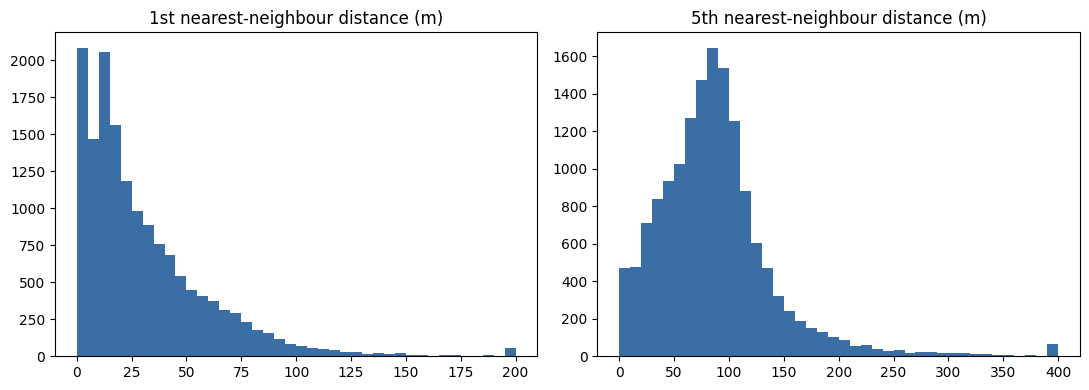

1st-NN distance (m):
count    15252.0
mean        31.3
std         32.5
min          0.0
10%          3.4
25%         11.1
50%         21.8
75%         43.2
90%         69.8
95%         86.3
max        813.6
dtype: float64

5th-NN distance (m):
count    15252.0
mean        88.5
std         64.6
min          0.0
10%         28.2
25%         54.4
50%         82.9
75%        108.4
90%        144.0
95%        180.0
max       1968.6
dtype: float64


In [19]:
coords = np.column_stack([outside_b.geometry.x, outside_b.geometry.y])
nn = NearestNeighbors(n_neighbors=6).fit(coords)
dist, _ = nn.kneighbors(coords)
nn1, nn5 = dist[:, 1], dist[:, 5]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.clip(nn1, 0, 200), bins=40, color="#3b6ea5")
axes[0].set_title("1st nearest-neighbour distance (m)")
axes[1].hist(np.clip(nn5, 0, 400), bins=40, color="#3b6ea5")
axes[1].set_title("5th nearest-neighbour distance (m)")
plt.tight_layout()
plt.savefig(DIR_DIAGNOSTICS / "nearest_neighbour_distances.png", dpi=DPI_SAVE)
plt.show()

print("1st-NN distance (m):")
print(pd.Series(nn1).describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(1))
print("\n5th-NN distance (m):")
print(pd.Series(nn5).describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(1))


### Interpretation and what this motivates

The median distance to the single nearest neighbouring business is about **20 m** -- consistent
with adjacent storefronts on the same block face. The median 5th-nearest-neighbour distance is
about **80 m**, and the 90th percentile is around **145 m**. Together these numbers motivate the
parameter ranges used later:

- **Method 1 grid sizes (50 / 75 / 100 m)** bracket the 1st-5th NN range, so a single active
  cell plausibly represents "one storefront's worth" of area at 50 m and "a small cluster" at
  100 m.
- **Method 2 DBSCAN `eps` values (70 / 100 / 130 m)** sit around the 5th-NN median and 90th
  percentile -- large enough to link a handful of nearby storefronts, small enough that it
  should not, by itself, casually bridge two genuinely distinct streets that happen to be a few
  hundred metres apart.
- **Parcel adjacency tolerance (12 m)** is deliberately much smaller than either of the above --
  it exists only to bridge a narrow alley or a single street width between adjacent parcels, not
  to do the work of defining corridor extent.

We also check businesses-per-parcel and parcels-per-business-count below, since a corridor
built from parcels is only as good as how well parcel geometry actually lines up with where
businesses sit.

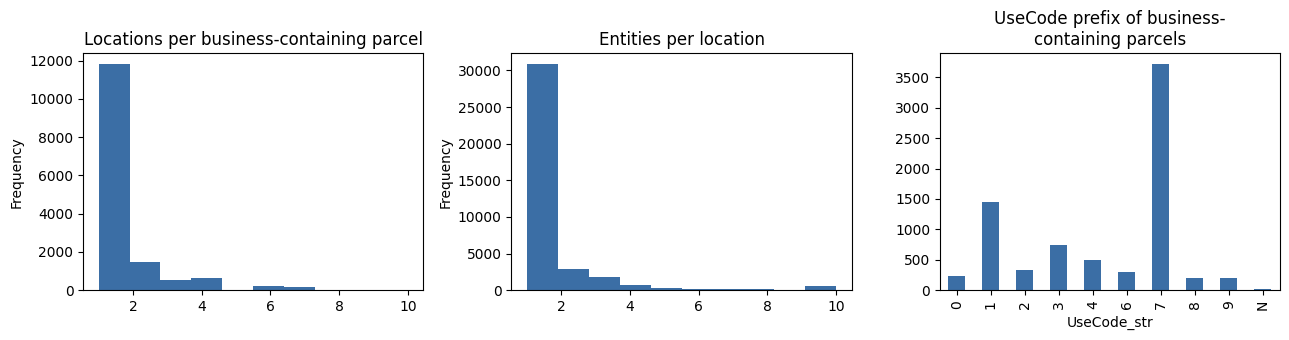

UseCode prefixes among business-containing parcels (share of business-containing parcels):
UseCode_str
7    48.4
1    18.8
3     9.7
4     6.5
2     4.3
6     3.8
0     3.0
8     2.7
9     2.7
N     0.2
Name: proportion, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

busy_parcels = parcels.loc[parcels["n_locations_any"] > 0, "n_locations_any"]
busy_parcels.clip(upper=10).plot(kind="hist", bins=10, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Locations per business-containing parcel")

locations["n_entities"].clip(upper=10).plot(kind="hist", bins=10, ax=axes[1], color="#3b6ea5")
axes[1].set_title("Entities per location")

parcels.loc[parcels["has_business_comm"], "UseCode_str"].str[0].value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color="#3b6ea5")
axes[2].set_title("UseCode prefix of business-\ncontaining parcels")
plt.tight_layout()
plt.savefig(DIR_DIAGNOSTICS / "parcel_business_diagnostics.png", dpi=DPI_SAVE)
plt.show()

print("UseCode prefixes among business-containing parcels (share of business-containing parcels):")
print((parcels.loc[parcels["has_business_comm"], "UseCode_str"].str[0]
       .value_counts(normalize=True).mul(100).round(1)))


### Interpretation

Most business-containing parcels hold just one location, but a meaningful tail holds several --
this is the "one building, many tenants" pattern the location-vs-entity distinction exists to
handle. On UseCode: business-containing parcels are not overwhelmingly UseCode 3/8/9 -- a
sizeable share of observed commercial activity sits on other UseCode prefixes (most likely
mixed-use or unusually-coded parcels). This is useful evidence for Section 8, where we build a
parcel score that leans on **observed business presence** rather than treating the UseCode
3/8/9 rule as a hard requirement.

# Section 5 -- A Common Evaluation Framework

**Question:** how do we compare candidate corridors that come from three very different
construction methods, on equal footing?

**Why this matters:** without a shared scorecard, "Method 1 found 40 corridors" and "Method 3
found 18 corridors" are not comparable. We build one set of functions here that can evaluate
*any* candidate-corridor GeoDataFrame, and reuse them for every method and every parameter
package below.

**What follows:** (1) the shared "relevant parcel" universe used to convert raw grid/cluster
signals into real parcel geometry, (2) two generic graph-construction helpers (adjacency, and
turning adjacency into connected components) reused by all three methods, and (3) the
candidate-level and system-level metric functions themselves.

In [21]:
# ---- Shared relevant-parcel universe (used to build parcel-based geometry for Methods 1 & 2) ----
# A parcel is "relevant" if it carries a 3/8/9 UseCode, OR it contains at least one Universe-B
# (commercial-focused) business location. BID-covered parcels are excluded up front so that
# corridor discovery never re-derives territory that already belongs to an existing district.
relevant_parcels = parcels[(parcels["relevant_usecode"] | parcels["has_business_comm"]) & (~parcels["in_bid"])].copy()
relevant_parcels = relevant_parcels.reset_index(drop=True)
relevant_parcels["rid"] = relevant_parcels.index
print(f"Relevant, non-BID parcel universe: {len(relevant_parcels):,} of {len(parcels):,} Oakland parcels")

_relevant_buffered = relevant_parcels.geometry.buffer(PARCEL_ADJACENCY_TOLERANCE_M)
_relevant_sindex = gpd.GeoSeries(_relevant_buffered).sindex


Relevant, non-BID parcel universe: 10,050 of 113,834 Oakland parcels


In [22]:
# ---- Generic graph helpers, reused by Methods 1, 2, and 3 ----
def build_adjacency_pairs(buffered_geoms, sindex=None):
    # Return (src, dst) index arrays for every pair of geometries whose buffered footprints
    # intersect. Used to treat parcels across a narrow street/alley as connected.
    if sindex is None:
        sindex = gpd.GeoSeries(buffered_geoms).sindex
    src, dst = sindex.query(buffered_geoms, predicate="intersects")
    keep = src != dst
    return src[keep], dst[keep]


def components_from_pairs(n, src, dst):
    # Connected components over n nodes given edge index arrays.
    mat = coo_matrix((np.ones(len(src)), (src, dst)), shape=(n, n))
    n_comp, labels = connected_components(mat, directed=False)
    return n_comp, labels


def one_ring_grow(seed_rids, buffered_geoms, sindex):
    # Given a set of seed row-positions into `buffered_geoms`, return that set plus every
    # row whose buffered footprint touches a seed's buffered footprint (one ring of dilation --
    # NOT full transitive growth). This is how Methods 1 and 2 turn a grid component / business
    # cluster into a bounded set of nearby relevant parcels without uncontrolled spread.
    # NOTE: query with the array of individual seed geometries (bulk, indexed) rather than a
    # single unary_union of them -- for a large seed set, testing many simple geometries against
    # the spatial index is far cheaper than building one giant unioned geometry and testing that.
    seed_idx = np.asarray(list(seed_rids))
    _, cand_idx = sindex.query(buffered_geoms.iloc[seed_idx], predicate="intersects")
    return set(cand_idx.tolist()) | set(seed_rids)


def dissolve_rids(rids, parcel_gdf):
    return unary_union(parcel_gdf.geometry.iloc[list(rids)].values)


In [23]:
def _elongation_ratio(geom):
    # Long side / short side of the minimum rotated bounding rectangle -- a simple proxy for
    # how 'linear/corridor-like' (high ratio) vs. 'blob-like' (near 1) a shape is.
    try:
        mrr = geom.minimum_rotated_rectangle
        if mrr.geom_type != "Polygon":
            return np.nan
        coords = list(mrr.exterior.coords)
        if len(coords) < 4:
            return np.nan
        side_lens = sorted(set(round(math.dist(coords[i], coords[i + 1]), 3) for i in range(4)))
        side_lens = [s for s in side_lens if s > 0]
        if not side_lens:
            return 1.0
        return side_lens[-1] / side_lens[0]
    except Exception:
        return np.nan


def compute_candidate_metrics(cand_gdf, loc_all=locations, comm_locations=outside_b,
                               parcel_universe=None, bid_union_geom=bid_union):
    # The common scorecard. Takes ANY candidate-corridor GeoDataFrame (needs 'candidate_id'
    # and 'geometry') and returns one row of diagnostics per candidate, using the shared business
    # and parcel layers. This is the single function reused by every method below.
    if parcel_universe is None:
        parcel_universe = relevant_parcels
    cand_gdf = cand_gdf.copy().reset_index(drop=True)
    cand_gdf["area_m2"] = cand_gdf.geometry.area
    cand_gdf["perimeter_m"] = cand_gdf.geometry.length
    cand_gdf["compactness"] = 4 * np.pi * cand_gdf["area_m2"] / cand_gdf["perimeter_m"].replace(0, np.nan) ** 2
    cand_gdf["elongation_ratio"] = cand_gdf.geometry.apply(_elongation_ratio)
    cand_gdf["dist_to_bid_m"] = cand_gdf.geometry.distance(bid_union_geom)
    overlap_area = cand_gdf.geometry.intersection(bid_union_geom).area
    cand_gdf["pct_overlap_bid"] = np.where(cand_gdf["area_m2"] > 0, 100 * overlap_area / cand_gdf["area_m2"], 0)

    j1 = gpd.sjoin(loc_all[["location_id", "n_entities", "broad_sector_mode", "commercial_relevance_mode", "geometry"]],
                   cand_gdf[["candidate_id", "geometry"]], how="inner", predicate="within")
    agg1 = j1.groupby("candidate_id").agg(n_locations=("location_id", "nunique"),
                                           n_entities=("n_entities", "sum"),
                                           n_sectors=("broad_sector_mode", "nunique"))
    dom = (j1.groupby(["candidate_id", "broad_sector_mode"]).size().reset_index(name="cnt")
           .sort_values("cnt", ascending=False).drop_duplicates("candidate_id")
           .set_index("candidate_id")["broad_sector_mode"].rename("dominant_sector"))

    j2 = gpd.sjoin(comm_locations[["location_id", "geometry"]], cand_gdf[["candidate_id", "geometry"]],
                    how="inner", predicate="within")
    agg2 = j2.groupby("candidate_id")["location_id"].nunique().rename("n_comm_locations")

    j3 = gpd.sjoin(parcel_universe[["n_locations_comm", "relevant_usecode", "geometry"]],
                    cand_gdf[["candidate_id", "geometry"]], how="inner", predicate="intersects")
    agg3 = j3.groupby("candidate_id").agg(n_parcels=("n_locations_comm", "size"),
                                           n_business_parcels=("n_locations_comm", lambda s: (s > 0).sum()),
                                           n_usecode_parcels=("relevant_usecode", "sum"))

    out = cand_gdf.set_index("candidate_id").join([agg1, dom, agg2, agg3]).reset_index()
    for c in ["n_locations", "n_entities", "n_sectors", "n_comm_locations", "n_parcels", "n_business_parcels", "n_usecode_parcels"]:
        out[c] = out[c].fillna(0)
    out["area_ha"] = out["area_m2"] / 10000
    out["locations_per_ha"] = out["n_locations"] / out["area_ha"].replace(0, np.nan)
    out["pct_relevant_parcel_area_with_business"] = np.where(
        out["n_parcels"] > 0, 100 * out["n_business_parcels"] / out["n_parcels"], 0)
    return out


In [24]:
def compute_candidate_metrics_quick(cand_gdf, comm_locations=outside_b):
    # A cheaper version used only inside parameter sweeps (Sections 6.6 / 7.4 / 8.6): area
    # and commercial-focused location coverage, without the more expensive per-candidate shape
    # and parcel-composition metrics. Full metrics are computed only for the small number of
    # configurations we keep for detailed review.
    cand_gdf = cand_gdf.copy().reset_index(drop=True)
    cand_gdf["area_m2"] = cand_gdf.geometry.area
    j = gpd.sjoin(comm_locations[["location_id", "geometry"]], cand_gdf[["candidate_id", "geometry"]],
                  how="inner", predicate="within")
    agg = j.groupby("candidate_id")["location_id"].nunique().rename("n_comm_locations")
    out = cand_gdf.set_index("candidate_id").join(agg).reset_index()
    out["n_comm_locations"] = out["n_comm_locations"].fillna(0)
    out["area_ha"] = out["area_m2"] / 10000
    return out


def summarize_system(metrics_df, universe_n_locations):
    # System-level (not per-candidate) summary for one candidate-corridor configuration.
    n = len(metrics_df)
    if n == 0:
        return dict(n_corridors=0, median_area_ha=np.nan, area_iqr_ha=np.nan,
                     median_locations=np.nan, location_range=np.nan,
                     captured_location_share_pct=0.0, n_giant=0, n_tiny=0, largest_share_pct=np.nan)
    area = metrics_df["area_ha"]
    locs = metrics_df["n_comm_locations"] if "n_comm_locations" in metrics_df else metrics_df["n_locations"]
    total_captured = locs.sum()
    return dict(
        n_corridors=n,
        median_area_ha=area.median(),
        area_iqr_ha=area.quantile(0.75) - area.quantile(0.25),
        median_locations=locs.median(),
        location_range=locs.max() - locs.min(),
        captured_location_share_pct=100 * total_captured / universe_n_locations if universe_n_locations else np.nan,
        n_giant=int((area > area.quantile(0.90) * 3).sum()) if n > 3 else 0,
        n_tiny=int((locs <= MIN_LOCATIONS_PER_CANDIDATE).sum()),
        largest_share_pct=100 * area.max() / area.sum() if area.sum() > 0 else np.nan,
    )


These functions give every method the same scorecard: physical location counts (not raw
entity counts), sector composition, shape metrics, parcel composition, and BID proximity/
overlap at the candidate level; and corridor count, size spread, and business-capture rate at
the system level. We will not force every method to produce the same *number* of corridors --
the goal is comparable *scale*, which we check directly in Section 11.

# Section 6 -- Method 1: Business-Intensity Grid to Parcel Corridors

This is the most developed of the three methods, and the one most directly inspired by
Jeong, Allen & Chapple (2024): lay a fine grid over Oakland, score each cell on commercial
intensity, smooth for spatial continuity, keep contiguous high-scoring components, and then
convert those components into real parcel geometry.

**Question:** where are the spatially-contiguous patches of unusually high commercial
intensity, at a resolution fine enough to trace individual blocks?

**Assumptions:** commercial intensity is measurable from the count and mix of physical
business locations in a small area; a single isolated high-scoring cell is not a corridor, but
a contiguous patch of them plausibly is; and the grid itself is only scaffolding -- the final
geometry should be built from parcels, not grid squares.

**Parameters that matter:** cell size, the intensity score definition, whether/how much we
smooth, the activity threshold, and how much gap-bridging we allow when grouping cells into
components. We test a manageable range of each rather than picking one value.

## 6.1 Grid Resolution

We build Oakland-clipped square grids at 50 m, 75 m, and 100 m -- bracketing the empirical
1st-to-5th nearest-neighbour range found in Section 4.

In [25]:
def make_grid(cell_size, boundary_geom, crs):
    minx, miny, maxx, maxy = boundary_geom.bounds
    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)
    cells, rows, cols = [], [], []
    for i, x in enumerate(xs):
        for j, y in enumerate(ys):
            cells.append(box(x, y, x + cell_size, y + cell_size))
            rows.append(j)
            cols.append(i)
    grid = gpd.GeoDataFrame({"row": rows, "col": cols}, geometry=cells, crs=crs)
    sidx = grid.sindex
    possible = list(sidx.query(boundary_geom, predicate="intersects"))
    grid = grid.iloc[possible].reset_index(drop=True)
    grid = gpd.clip(grid, boundary_geom)
    grid = grid[~grid.geometry.is_empty].reset_index(drop=True)
    grid["cell_id"] = grid.index.astype(str)
    grid["cell_area_m2"] = grid.geometry.area
    return grid

grids = {}
for cs in tqdm(GRID_CELL_SIZES_M, desc="building grids"):
    grids[cs] = make_grid(cs, oakland_boundary, PROJ_CRS)
    print(f"  {cs} m grid: {len(grids[cs]):,} cells within Oakland")


building grids:   0%|          | 0/3 [00:00<?, ?it/s]

  50 m grid: 82,310 cells within Oakland


  75 m grid: 36,929 cells within Oakland


  100 m grid: 20,967 cells within Oakland


## 6.2 Cell Features and Commercial Intensity Score

For each cell we count unique commercial-focused business locations (outside BIDs), the
consumer-facing / office-professional / industrial-logistics split, how many distinct broad
sectors are represented, and total employees. We keep this list short on purpose -- a handful
of legible indicators, not dozens.

We compare two intensity-score variants:

- **A. Raw density** -- commercial-focused locations per hectare. Simple, but says nothing
  about the *mix* of activity.
- **B. Multi-factor score** -- a standardized combination of log-location-density, sector
  diversity, and log-employment. Cells with a genuine mix of activity (not just one big
  low-employment use) score higher, which better matches the intuitive idea of a "commercial
  area" rather than a single dense point.

In [26]:
def compute_cell_features(grid, points):
    joined = gpd.sjoin(points, grid[["cell_id", "geometry"]], how="inner", predicate="within")
    feats = joined.groupby("cell_id").agg(
        n_locations=("location_id", "nunique"),
        n_entities=("n_entities", "sum"),
        n_consumer_facing=("commercial_relevance_mode", lambda s: (s == "consumer_facing").sum()),
        n_office=("commercial_relevance_mode", lambda s: (s == "office_or_professional").sum()),
        n_industrial=("commercial_relevance_mode", lambda s: (s == "industrial_or_logistics").sum()),
        n_sectors_present=("broad_sector_mode", "nunique"),
        employees_total=("employees_total", lambda s: s.sum(min_count=1)),
    ).reset_index()
    out = grid.merge(feats, on="cell_id", how="left")
    for c in ["n_locations", "n_entities", "n_consumer_facing", "n_office", "n_industrial", "n_sectors_present"]:
        out[c] = out[c].fillna(0)
    out["employees_total"] = out["employees_total"].fillna(0)
    return out


def score_raw(feat):
    return feat["n_locations"] / (feat["cell_area_m2"] / 10000.0)


def _z(x):
    sd = x.std()
    return (x - x.mean()) / sd if sd > 0 else x * 0.0


def score_multifactor(feat):
    density = feat["n_locations"] / (feat["cell_area_m2"] / 10000.0)
    return _z(np.log1p(density)) + _z(feat["n_sectors_present"]) + _z(np.log1p(feat["employees_total"]))


def smooth_scores(feat, value_col, radius_cells=1):
    idx_map = {(r, c): i for i, (r, c) in enumerate(zip(feat["row"], feat["col"]))}
    vals = feat[value_col].to_numpy()
    rows_a, cols_a = feat["row"].to_numpy(), feat["col"].to_numpy()
    offs = [(dr, dc) for dr in range(-radius_cells, radius_cells + 1) for dc in range(-radius_cells, radius_cells + 1)]
    total, count = np.zeros(len(feat)), np.zeros(len(feat))
    for dr, dc in offs:
        nb_idx = np.array([idx_map.get(k, -1) for k in zip(rows_a + dr, cols_a + dc)])
        valid = nb_idx >= 0
        total[valid] += vals[nb_idx[valid]]
        count[valid] += 1
    return total / count

cell_features = {}
for cs in tqdm(GRID_CELL_SIZES_M, desc="scoring grids"):
    feat = compute_cell_features(grids[cs], outside_b)
    feat["score_raw"] = score_raw(feat)
    feat["score_multi"] = score_multifactor(feat)
    feat["score_raw_smooth"] = smooth_scores(feat, "score_raw", GRID_SMOOTH_RADIUS_CELLS)
    feat["score_multi_smooth"] = smooth_scores(feat, "score_multi", GRID_SMOOTH_RADIUS_CELLS)
    cell_features[cs] = feat

print(f"Cells with >=1 commercial-focused location, 75 m grid: "
      f"{(cell_features[75]['n_locations'] > 0).sum():,} of {len(cell_features[75]):,}")


scoring grids:   0%|          | 0/3 [00:00<?, ?it/s]

Cells with >=1 commercial-focused location, 75 m grid: 7,925 of 36,929


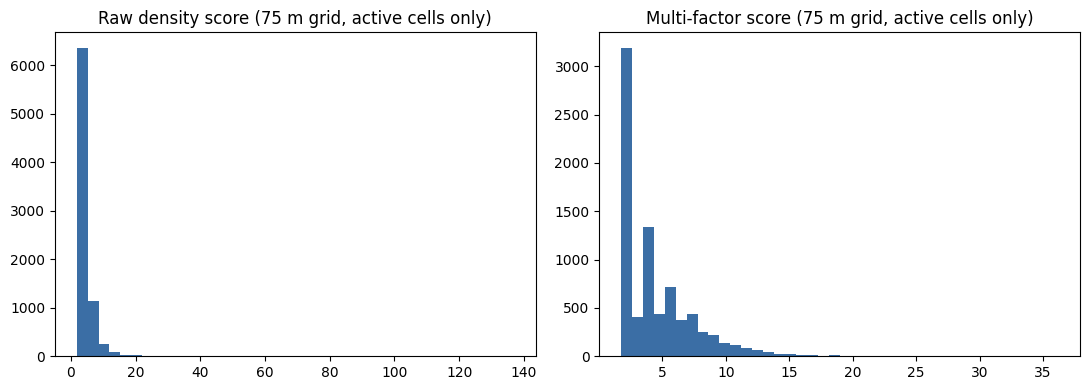

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ["score_raw", "score_multi"], ["Raw density score", "Multi-factor score"]):
    nonzero = cell_features[75].loc[cell_features[75][col] > cell_features[75][col].min(), col]
    ax.hist(nonzero, bins=40, color="#3b6ea5")
    ax.set_title(f"{title} (75 m grid, active cells only)")
plt.tight_layout()
plt.show()


### Interpretation

Both score variants are, by construction, zero (or at the score floor) for the roughly
three-quarters of cells with no commercial-focused locations at all -- corridor structure is a
minority-of-cells phenomenon in Oakland, which is exactly why a threshold + contiguity approach
makes sense here rather than, say, a smooth density surface. The multi-factor score adds a
diversity signal on top of raw density, which matters for telling apart a single large
low-diversity land use (e.g. one big industrial employer) from a genuinely mixed commercial
block -- Section 6.6 checks whether this choice changes which components get identified.

## 6.3 Spatial Smoothing / Continuity

A corridor should not depend on whether a business happens to sit just inside or just outside a
grid line. We apply a simple focal (queen-neighbourhood) mean as a transparent smoothing step,
and keep both the original and smoothed score so we can compare downstream.

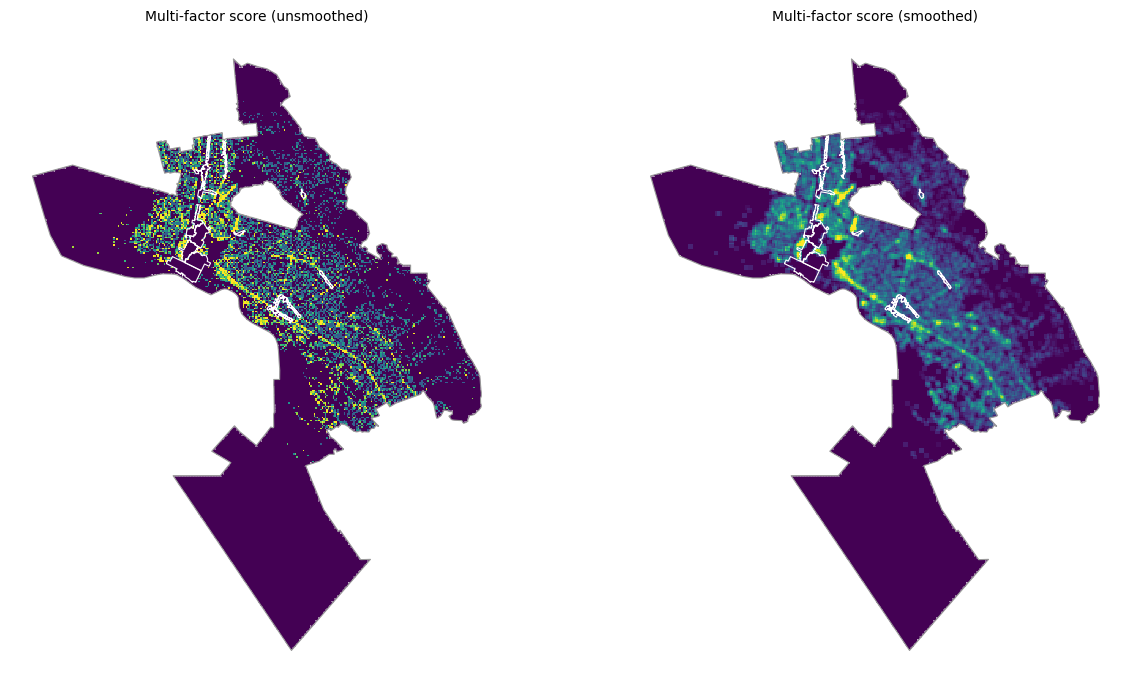

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, col, title in zip(axes, ["score_multi", "score_multi_smooth"], ["Multi-factor score (unsmoothed)", "Multi-factor score (smoothed)"]):
    cell_features[75].plot(column=col, ax=ax, cmap="viridis", legend=False,
                            vmin=cell_features[75]["score_multi"].quantile(0.5),
                            vmax=cell_features[75]["score_multi"].quantile(0.98))
    bids.boundary.plot(ax=ax, color="white", linewidth=0.8)
    oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIR_METHOD1 / "smoothing_comparison_75m.png", dpi=DPI_SAVE)
plt.show()


## 6.4 Active Cells and Connected Components

A cell is "active" if its smoothed score is at/above a threshold. We test both quantile
thresholds (0.85 / 0.90 / 0.95 of the score distribution) and an allowed-gap parameter (0 = only
directly-adjacent active cells join a component; 1 = active cells separated by a single
inactive cell still join, bridging small streets). Adjacent active cells become one connected
component via a queen-adjacency graph, solved with `scipy.sparse.csgraph.connected_components`.
Tiny components (below `GRID_MIN_COMPONENT_CELLS`) are dropped, and components at/above
`GRID_GIANT_COMPONENT_CELLS_FLAG` cells are explicitly flagged rather than quietly kept.

In [29]:
def build_grid_components(feat, score_col, threshold, gap=0):
    active_mask = feat[score_col] >= threshold
    active_idx = np.where(active_mask.to_numpy())[0]
    comp_full = np.full(len(feat), -1)
    if len(active_idx) == 0:
        return feat.assign(component=comp_full)
    sub = feat.iloc[active_idx]
    idx_map = {(r, c): i for i, (r, c) in enumerate(zip(sub["row"], sub["col"]))}
    radius = 1 + gap
    offs = [(dr, dc) for dr in range(-radius, radius + 1) for dc in range(-radius, radius + 1) if not (dr == 0 and dc == 0)]
    rr, cc = sub["row"].to_numpy(), sub["col"].to_numpy()
    src_list, dst_list = [], []
    for dr, dc in offs:
        nb_idx = np.array([idx_map.get(k, -1) for k in zip(rr + dr, cc + dc)])
        valid = nb_idx >= 0
        src_list.extend(np.where(valid)[0].tolist())
        dst_list.extend(nb_idx[valid].tolist())
    n_comp, labels = components_from_pairs(len(sub), np.array(src_list), np.array(dst_list))
    comp_full[active_idx] = labels
    out = feat.copy()
    out["component"] = comp_full
    return out

# Illustrative run: 75 m grid, smoothed multi-factor score, quantile 0.90 threshold, 1-cell gap allowed
example_feat = cell_features[75]
example_threshold = example_feat["score_multi_smooth"].quantile(0.90)
example_result = build_grid_components(example_feat, "score_multi_smooth", example_threshold, gap=1)
comp_sizes = example_result.loc[example_result["component"] >= 0].groupby("component").size().sort_values(ascending=False)
print(f"Threshold (q=0.90): {example_threshold:.2f}")
print(f"Components found: {len(comp_sizes)}")
print(f"Largest 5 components (cells): {comp_sizes.head(5).tolist()}")
print(f"Components at/above the giant-component flag ({GRID_GIANT_COMPONENT_CELLS_FLAG} cells): "
      f"{(comp_sizes >= GRID_GIANT_COMPONENT_CELLS_FLAG).sum()}")


Threshold (q=0.90): 2.48
Components found: 73
Largest 5 components (cells): [2051, 478, 247, 138, 78]
Components at/above the giant-component flag (500 cells): 1


### The giant-component problem, made visible

With a 1-cell gap allowed and a moderate (0.90-quantile) threshold, one component alone absorbs
several thousand contiguous cells -- almost certainly the entire dense flatlands stretch from
downtown through the Fruitvale/San Antonio area fusing into a single "corridor." This is the
same problem the earlier notebook found with DBSCAN, showing up here in raster form. We do not
hide this: the sensitivity sweep below (6.6) shows exactly which parameter combinations produce
this outcome and which keep components at a plausible corridor scale, and only non-giant
configurations are carried forward as Method 1 candidates.

## 6.5 From Grid Components to Parcel Corridors

The grid identifies *where* commercial concentration is; it should not be the final geometry
(a corridor should not be a jagged staircase of square cells). For each surviving component, we:

1. find relevant parcels (Section 5's shared universe) that intersect the component's cells --
   these are the seed parcels;
2. grow **one ring** outward to catch immediately-adjacent relevant parcels bridging a narrow
   street or gap (not unlimited transitive growth -- that would re-create the parcel-connectivity
   method's over-generosity problem);
3. dissolve the resulting parcel set into one polygon per component.

We show this step-by-step for a few representative components below.

In [30]:
def grid_components_to_parcels(active_cells_gdf, parcel_gdf, buffered_geoms, sindex, min_cells=1):
    join = gpd.sjoin(parcel_gdf[["rid", "geometry"]], active_cells_gdf[["component", "geometry"]],
                      how="inner", predicate="intersects")
    seed_map = join.groupby("component")["rid"].apply(set)
    records = []
    for comp_id, seed_rids in seed_map.items():
        if len(seed_rids) < min_cells:
            continue
        grown = one_ring_grow(seed_rids, buffered_geoms, sindex)
        geom = dissolve_rids(grown, parcel_gdf)
        records.append({"component": comp_id, "geometry": geom, "n_seed_parcels": len(seed_rids), "n_grown_parcels": len(grown)})
    return gpd.GeoDataFrame(records, crs=parcel_gdf.crs) if records else gpd.GeoDataFrame(columns=["component", "geometry"], crs=parcel_gdf.crs)

active_cells_example = example_result[(example_result["component"] >= 0)]
comp_sizes_example = active_cells_example.groupby("component").size().sort_values(ascending=False)
mid_size_components = comp_sizes_example[(comp_sizes_example >= 8) & (comp_sizes_example < GRID_GIANT_COMPONENT_CELLS_FLAG)].index[:3].tolist()

example_parcel_candidates = grid_components_to_parcels(
    active_cells_example[active_cells_example["component"].isin(mid_size_components)],
    relevant_parcels, _relevant_buffered, _relevant_sindex, min_cells=GRID_MIN_COMPONENT_CELLS)
print(example_parcel_candidates[["component", "n_seed_parcels", "n_grown_parcels"]])


   component  n_seed_parcels  n_grown_parcels
0         51             505              518
1         52            1114             1245
2         66             328              340


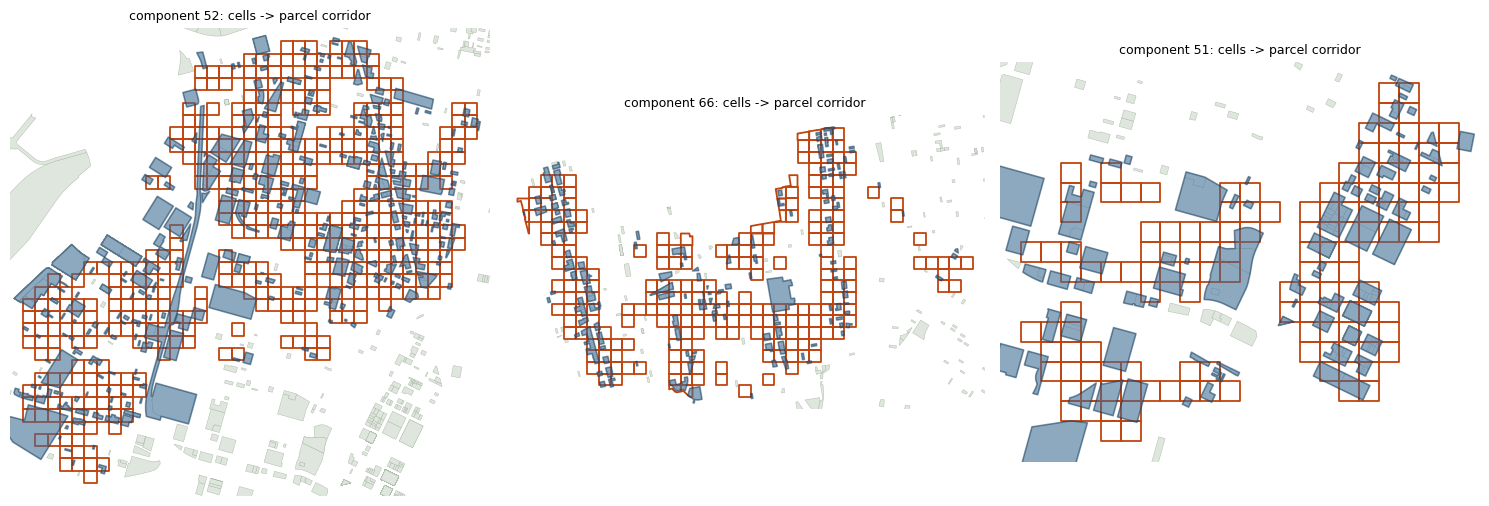

In [31]:
fig, axes = plt.subplots(1, len(mid_size_components), figsize=(5 * len(mid_size_components), 5))
if len(mid_size_components) == 1:
    axes = [axes]
for ax, comp_id in zip(axes, mid_size_components):
    cells_here = active_cells_example[active_cells_example["component"] == comp_id]
    minx, miny, maxx, maxy = cells_here.buffer(80).total_bounds
    cand_row = example_parcel_candidates[example_parcel_candidates["component"] == comp_id]

    relevant_parcels.cx[minx:maxx, miny:maxy].plot(ax=ax, color="#dfe6dd", edgecolor="#a9b7a6", linewidth=0.3)
    cells_here.plot(ax=ax, facecolor="none", edgecolor="#c1440e", linewidth=1.3, label="active grid cells")
    if len(cand_row):
        cand_row.plot(ax=ax, facecolor="#3b6ea5", edgecolor="#123a5e", alpha=0.5, linewidth=1.2)
    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    ax.set_title(f"component {comp_id}: cells -> parcel corridor", fontsize=9)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIR_METHOD1 / "grid_to_parcel_examples.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

The orange outlines (active grid cells) are boxy and grid-aligned; the blue fill (the resulting
parcel corridor) instead traces real lot lines and street frontage. This is the intended effect
of the grid-to-parcel step -- the grid does the *detection*, parcels do the *geometry*.

## 6.6 Sensitivity Sweep

We now sweep cell size (3 values) x intensity quantile threshold (3 values) x gap-bridging (2
values) = 18 combinations -- a manageable grid, not hundreds of throwaway runs. For speed, the
sweep evaluates each combination using the **dissolved grid cells themselves** (cheap) rather
than the full parcel-conversion (expensive); the parcel conversion is only run for the small
number of configurations we keep afterward. Every combination uses the smoothed multi-factor
score, since 6.2-6.3 showed the raw-density score is a strict subset of that signal.

In [32]:
sweep_records = []
sweep_combos = list(itertools.product(GRID_CELL_SIZES_M, GRID_INTENSITY_QUANTILES, GRID_ADJACENCY_GAPS))

for cs, q, gap in tqdm(sweep_combos, desc="Method 1 sensitivity sweep"):
    feat = cell_features[cs]
    threshold = feat["score_multi_smooth"].quantile(q)
    result = build_grid_components(feat, "score_multi_smooth", threshold, gap=gap)
    active = result[result["component"] >= 0]
    if len(active) == 0:
        continue
    comp_sizes = active.groupby("component").size()
    keep_components = comp_sizes[comp_sizes >= GRID_MIN_COMPONENT_CELLS].index
    active_kept = active[active["component"].isin(keep_components)]
    if len(active_kept) == 0:
        continue
    dissolved = active_kept.dissolve(by="component").reset_index()
    dissolved["candidate_id"] = [f"M1_cs{cs}_q{q}_g{gap}_c{c}" for c in dissolved["component"]]
    metrics = compute_candidate_metrics_quick(dissolved[["candidate_id", "geometry"]])
    summary = summarize_system(metrics, len(outside_b))
    summary.update(dict(cell_size_m=cs, quantile=q, gap=gap,
                         n_giant_components=int((comp_sizes >= GRID_GIANT_COMPONENT_CELLS_FLAG).sum())))
    sweep_records.append(summary)

method1_sweep = pd.DataFrame(sweep_records)
method1_sweep.to_csv(DIR_METHOD1 / "method1_sensitivity_sweep.csv", index=False)
method1_sweep.round(2)


Method 1 sensitivity sweep:   0%|          | 0/18 [00:00<?, ?it/s]

,n_corridors,median_area_ha,area_iqr_ha,median_locations,location_range,captured_location_share_pct,n_giant,n_tiny,largest_share_pct,cell_size_m,quantile,gap,n_giant_components
0,248,2.00,3.62,5.0,2970.0,67.54,11,93,23.06,50,0.85,0,5
1,96,2.00,2.51,5.0,8785.0,67.71,3,32,83.02,50,0.85,1,1
2,240,2.12,3.81,7.0,1502.0,54.08,7,69,16.35,50,0.90,0,2
3,127,2.00,5.00,6.0,3369.0,54.31,4,42,35.32,50,0.90,1,3
4,187,2.25,3.50,10.0,469.0,36.23,6,35,6.88,50,0.95,0,0
5,127,2.75,4.62,11.0,1625.0,36.48,4,22,26.87,50,0.95,1,1
6,85,4.50,9.56,9.0,5681.0,62.96,3,11,54.53,75,0.85,0,2
7,29,6.75,21.38,14.0,7176.0,63.26,2,2,72.39,75,0.85,1,2
8,87,6.75,13.22,20.0,2258.0,50.12,5,4,26.47,75,0.90,0,1
9,43,9.00,13.78,28.0,4629.0,50.49,3,1,56.36,75,0.90,1,1


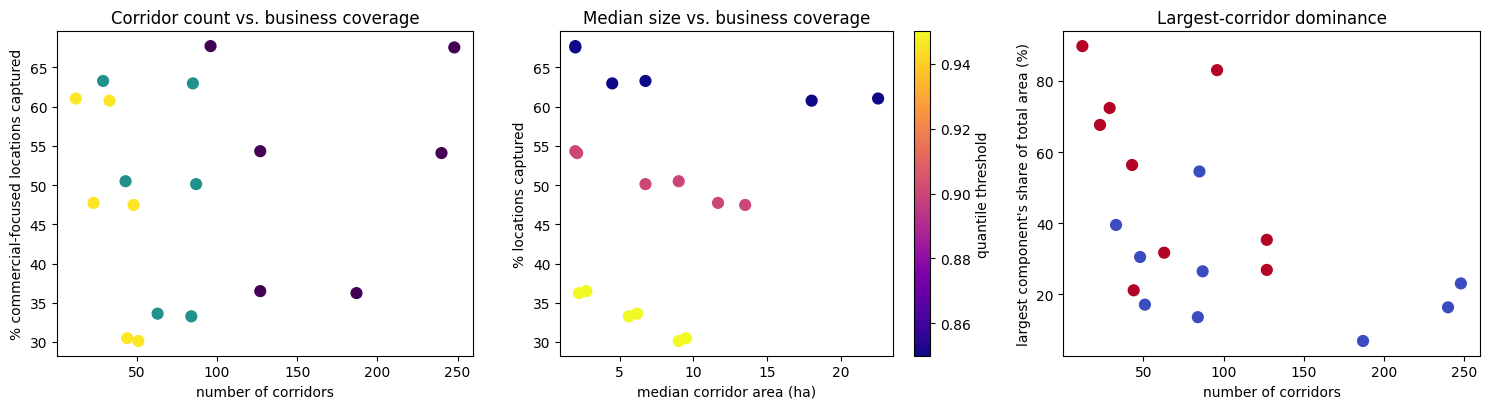

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(method1_sweep["n_corridors"], method1_sweep["captured_location_share_pct"],
                c=method1_sweep["cell_size_m"], cmap="viridis", s=60)
axes[0].set_xlabel("number of corridors"); axes[0].set_ylabel("% commercial-focused locations captured")
axes[0].set_title("Corridor count vs. business coverage")

sc = axes[1].scatter(method1_sweep["median_area_ha"], method1_sweep["captured_location_share_pct"],
                      c=method1_sweep["quantile"], cmap="plasma", s=60)
axes[1].set_xlabel("median corridor area (ha)"); axes[1].set_ylabel("% locations captured")
axes[1].set_title("Median size vs. business coverage")
plt.colorbar(sc, ax=axes[1], label="quantile threshold")

axes[2].scatter(method1_sweep["n_corridors"], method1_sweep["largest_share_pct"],
                c=method1_sweep["gap"], cmap="coolwarm", s=60)
axes[2].set_xlabel("number of corridors"); axes[2].set_ylabel("largest component's share of total area (%)")
axes[2].set_title("Largest-corridor dominance")
plt.tight_layout()
plt.savefig(DIR_METHOD1 / "method1_sensitivity_plots.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

Allowing a 1-cell gap consistently pushes up the largest-component share -- exactly the
mechanism behind the giant-flatlands-blob problem seen in 6.4. Tighter thresholds (quantile
0.95) and stricter adjacency (no gap) keep the largest component's share of total area much
lower, at the cost of capturing a smaller share of citywide commercial-focused locations and
producing more, smaller corridors. There is a real trade-off here, not a free lunch: a
higher threshold buys well-scaled corridors at the price of leaving some real commercial
locations uncaptured. Coarser grids (100 m) tend to produce fewer, larger corridors than finer
grids (50 m) at a comparable quantile, since a coarse cell averages over more ground before
being called "active."

We keep three Method 1 configurations for downstream comparison, chosen to span this
trade-off rather than to pick one "winner":

In [34]:
method1_keepers = [
    dict(label="M1_conservative", cell_size_m=75, quantile=0.95, gap=0),
    dict(label="M1_balanced",     cell_size_m=75, quantile=0.90, gap=0),
    dict(label="M1_inclusive",    cell_size_m=50, quantile=0.85, gap=1),
]
method1_candidates = {}
method1_full_metrics = {}

for keeper in tqdm(method1_keepers, desc="building kept Method 1 candidates"):
    cs, q, gap, label = keeper["cell_size_m"], keeper["quantile"], keeper["gap"], keeper["label"]
    feat = cell_features[cs]
    threshold = feat["score_multi_smooth"].quantile(q)
    result = build_grid_components(feat, "score_multi_smooth", threshold, gap=gap)
    active = result[result["component"] >= 0]
    comp_sizes = active.groupby("component").size()
    keep_components = comp_sizes[comp_sizes >= GRID_MIN_COMPONENT_CELLS].index
    active_kept = active[active["component"].isin(keep_components)]

    parcel_cands = grid_components_to_parcels(active_kept, relevant_parcels, _relevant_buffered, _relevant_sindex,
                                                min_cells=GRID_MIN_COMPONENT_CELLS)
    parcel_cands["candidate_id"] = [f"{label}_{i:03d}" for i in range(len(parcel_cands))]
    parcel_cands["area_ha_tmp"] = parcel_cands.geometry.area / 10000
    parcel_cands = parcel_cands[parcel_cands["area_ha_tmp"] >= MIN_CANDIDATE_AREA_HA].drop(columns="area_ha_tmp")

    metrics = compute_candidate_metrics(parcel_cands[["candidate_id", "geometry"]])
    metrics = metrics[metrics["n_comm_locations"] >= MIN_LOCATIONS_PER_CANDIDATE].reset_index(drop=True)
    metrics["method"] = "method_1_grid"
    metrics["config_label"] = label
    metrics["n_giant_flagged"] = int((comp_sizes >= GRID_GIANT_COMPONENT_CELLS_FLAG).sum())

    method1_candidates[label] = gpd.GeoDataFrame(metrics, geometry="geometry", crs=PROJ_CRS)
    method1_full_metrics[label] = summarize_system(metrics, len(outside_b))
    n_giant_here = int((comp_sizes >= GRID_GIANT_COMPONENT_CELLS_FLAG).sum())
    print(f"{label}: {len(metrics)} candidate corridors, "
          f"{metrics['n_comm_locations'].sum():.0f} commercial-focused locations captured, "
          f"{n_giant_here} giant component(s) flagged before pruning")

    method1_candidates[label].to_file(DIR_METHOD1 / f"method1_{label}.gpkg", driver="GPKG")


building kept Method 1 candidates:   0%|          | 0/3 [00:00<?, ?it/s]

M1_conservative: 74 candidate corridors, 2146 commercial-focused locations captured, 0 giant component(s) flagged before pruning


M1_balanced: 72 candidate corridors, 2936 commercial-focused locations captured, 1 giant component(s) flagged before pruning


M1_inclusive: 44 candidate corridors, 3867 commercial-focused locations captured, 1 giant component(s) flagged before pruning


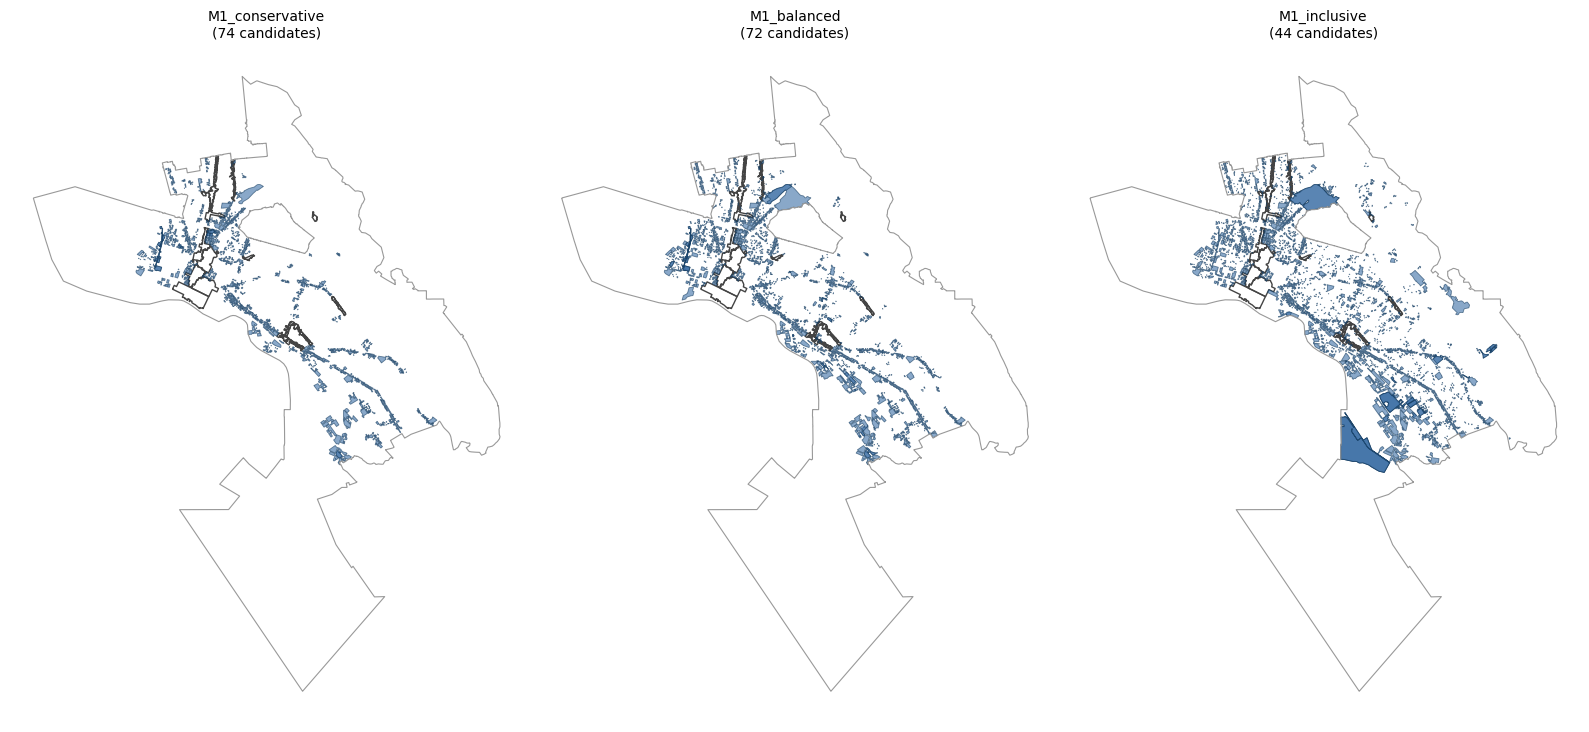

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for ax, label in zip(axes, method1_keepers):
    lbl = label["label"]
    oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=0.8)
    bids.plot(ax=ax, facecolor="none", edgecolor=BID_COLOR, linewidth=1.0)
    method1_candidates[lbl].plot(ax=ax, color="#3b6ea5", edgecolor="#123a5e", alpha=0.6, linewidth=0.6)
    ax.set_title(f"{lbl}\n({len(method1_candidates[lbl])} candidates)", fontsize=10)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIR_METHOD1 / "method1_three_configs_citywide.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

The conservative configuration produces the fewest, most tightly-scaled candidates; the
inclusive configuration (finer grid, looser threshold, gap-bridging on) produces more candidates
and visibly larger ones, including at least one very large flatlands component. None of these
three is being called "correct" -- they represent three defensible, differently-tuned readings
of the same underlying signal, and all three are carried into the cross-method comparison
(Section 9) and the review packages (Section 13).

# Section 7 -- Method 2: Business Network / Density Clusters to Parcel Corridors

This method is built around the topology of business locations themselves rather than a raster.
It is deliberately **not** a repeat of the earlier notebook's DBSCAN-plus-point-buffer
approach: clusters are seeds for a parcel-based geometry, not final polygons, and we test an
explicit fix for the mega-cluster problem rather than just reporting it.

**Question:** which business locations are close enough together, in an unbroken chain, that
they read as one connected commercial node -- and when that chain gets too large to be one
"corridor," can we split it in a transparent, defensible way?

**Assumptions:** proximity between businesses is real evidence of a shared commercial
concentration; but an uninterrupted chain of proximate businesses across the whole flatlands is
not, on its own, "one corridor" -- density itself should be used to notice where that chain gets
noticeably thinner and treat that as a plausible seam.

**Parameters that matter:** the connection distance (`eps`), the minimum neighbourhood size
(`min_samples`), and the mega-cluster split threshold/eps.

## 7.1 Empirical Distance Scale

Section 4's nearest-neighbour distances put the 5th-NN median around 80 m and the 90th
percentile around 145 m. We test three `eps` values spanning that range. DBSCAN is used because
it is already available, well understood, and -- unlike a plain distance-threshold graph --
naturally distinguishes core, border, and noise points, which is a useful notion of "is this
really part of a cluster" for individual businesses sitting at a cluster's edge. HDBSCAN is not
installed in this environment, so we do not add it as a dependency; DBSCAN plus an explicit
mega-cluster-splitting step (7.2) covers the same practical need.

In [36]:
coords_outside_b = np.column_stack([outside_b.geometry.x, outside_b.geometry.y])

dbscan_scan = []
for eps in DBSCAN_EPS_VALUES_M:
    labels = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES).fit(coords_outside_b).labels_
    sizes = pd.Series(labels[labels >= 0]).value_counts()
    dbscan_scan.append(dict(eps=eps, n_clusters=int((sizes.index >= 0).sum()), n_noise=int((labels == -1).sum()),
                             largest_cluster=int(sizes.max()) if len(sizes) else 0,
                             n_mega_clusters=int((sizes >= MEGA_CLUSTER_LOCATIONS_FLAG).sum())))
pd.DataFrame(dbscan_scan)


,eps,n_clusters,n_noise,largest_cluster,n_mega_clusters
0,70,581,5962,432,0
1,100,286,1798,3079,4
2,130,119,755,12336,1


### Interpretation

As `eps` grows from 70 to 130 m, the largest cluster grows sharply and the number of
mega-clusters (at/above 1,000 locations) increases -- the mega-cluster problem the earlier
notebook found is clearly reproducible here on the richer combined dataset, and it is a smooth
function of `eps`, not a fluke of one parameter choice.

## 7.2 The Mega-Cluster Problem

We treat any cluster at or above `MEGA_CLUSTER_LOCATIONS_FLAG` locations as a mega-cluster and
re-run DBSCAN, with a **tighter** `eps`, on only that cluster's points. This is the most
transparent version of "density-based splitting" available without adding a graph-community
or hierarchical-clustering dependency: we are directly asking "at a stricter density standard,
does this supposedly-single cluster actually separate into several denser sub-nodes?" We do not
claim this fully resolves the mega-cluster problem -- for very dense, truly continuous
commercial fabric (downtown Oakland is the clearest case), tightening the distance threshold
still leaves large sub-clusters. The point is to produce a more usable, less monolithic set of
seeds, and to be explicit about how much a tighter distance helps versus doesn't.

In [37]:
def dbscan_with_mega_split(coords, eps, min_samples, mega_thresh, split_eps, split_min_samples):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit(coords).labels_.copy()
    sizes = pd.Series(labels[labels >= 0]).value_counts()
    mega_ids = sizes[sizes >= mega_thresh].index.tolist()
    next_label = labels.max() + 1
    for mid in mega_ids:
        mask = labels == mid
        sub_labels = DBSCAN(eps=split_eps, min_samples=split_min_samples).fit(coords[mask]).labels_
        labels[mask] = np.where(sub_labels == -1, -1, sub_labels + next_label)
        next_label = labels.max() + 1
    return labels

eps_demo = 100
labels_before = DBSCAN(eps=eps_demo, min_samples=DBSCAN_MIN_SAMPLES).fit(coords_outside_b).labels_
labels_after = dbscan_with_mega_split(coords_outside_b, eps_demo, DBSCAN_MIN_SAMPLES,
                                       MEGA_CLUSTER_LOCATIONS_FLAG, MEGA_CLUSTER_SPLIT_EPS_M, MEGA_CLUSTER_SPLIT_MIN_SAMPLES)

sizes_before = pd.Series(labels_before[labels_before >= 0]).value_counts().sort_values(ascending=False)
sizes_after = pd.Series(labels_after[labels_after >= 0]).value_counts().sort_values(ascending=False)
print(f"eps={eps_demo} m, before splitting: {len(sizes_before)} clusters, largest = {sizes_before.iloc[0]:,} locations")
print(f"eps={eps_demo} m, after splitting mega-clusters (>= {MEGA_CLUSTER_LOCATIONS_FLAG}) with eps={MEGA_CLUSTER_SPLIT_EPS_M} m:")
print(f"  {len(sizes_after)} clusters, largest = {sizes_after.iloc[0]:,} locations")
print(f"  top 8 cluster sizes after splitting: {sizes_after.head(8).tolist()}")


eps=100 m, before splitting: 286 clusters, largest = 3,079 locations
eps=100 m, after splitting mega-clusters (>= 1000) with eps=50 m:
  545 clusters, largest = 886 locations
  top 8 cluster sizes after splitting: [886, 778, 242, 217, 204, 195, 187, 128]


### Interpretation

Splitting reduces the single largest cluster substantially and produces several separate
few-hundred-to-thousand-location clusters where before there was one 3,000+-location mass --
but the largest resulting pieces are still fairly large. This matches the honest expectation:
Oakland's flatlands commercial fabric is genuinely close to continuous in places, so no purely
density-based split fully resolves it. We carry this splitting step into all Method 2
configurations below, and flag remaining large clusters rather than treat them as solved.

## 7.3 From Business Clusters to Parcel Corridors

As with Method 1, a business cluster is a **seed**, not a final boundary. We deliberately avoid
both a convex hull (which would balloon across any gaps in the cluster's footprint) and a
circular point-buffer blob (which ignores real parcel geometry). Instead, for each cluster we:

1. find relevant parcels containing a member business location -- the seed parcels;
2. grow one ring outward into adjacent relevant parcels (same mechanism as Method 1, reusing
   `one_ring_grow` from Section 5);
3. dissolve into one polygon per cluster.

This differs from Method 1's conversion only in what seeds it (cluster membership vs. grid
cells) and from Method 3's conversion (Section 8) in that growth stops after one ring rather
than continuing transitively -- Method 2's geometry stays tightly tied to where the actual
cluster points are.

In [38]:
def clusters_to_parcels(points_gdf, labels, parcel_gdf, buffered_geoms, sindex, min_locations=1):
    pts = points_gdf.copy()
    pts["cluster"] = labels
    pts = pts[pts["cluster"] >= 0]
    join = gpd.sjoin(pts[["cluster", "geometry"]], parcel_gdf[["rid", "geometry"]], how="inner", predicate="within")
    seed_map = join.groupby("cluster")["rid"].apply(set)
    cluster_sizes = pts.groupby("cluster").size()
    records = []
    for cl, seed_rids in seed_map.items():
        if cluster_sizes.get(cl, 0) < min_locations:
            continue
        grown = one_ring_grow(seed_rids, buffered_geoms, sindex)
        geom = dissolve_rids(grown, parcel_gdf)
        records.append({"cluster": cl, "geometry": geom, "n_member_locations": int(cluster_sizes.get(cl, 0)),
                         "n_seed_parcels": len(seed_rids), "n_grown_parcels": len(grown)})
    return gpd.GeoDataFrame(records, crs=parcel_gdf.crs) if records else gpd.GeoDataFrame(columns=["cluster", "geometry"], crs=parcel_gdf.crs)

demo_parcel_cands = clusters_to_parcels(outside_b, labels_after, relevant_parcels, _relevant_buffered, _relevant_sindex,
                                          min_locations=MIN_LOCATIONS_PER_CANDIDATE)
demo_parcel_cands["candidate_id"] = [f"demo_{i:03d}" for i in range(len(demo_parcel_cands))]
print(f"Demo cluster-based parcel candidates: {len(demo_parcel_cands)}")


Demo cluster-based parcel candidates: 464


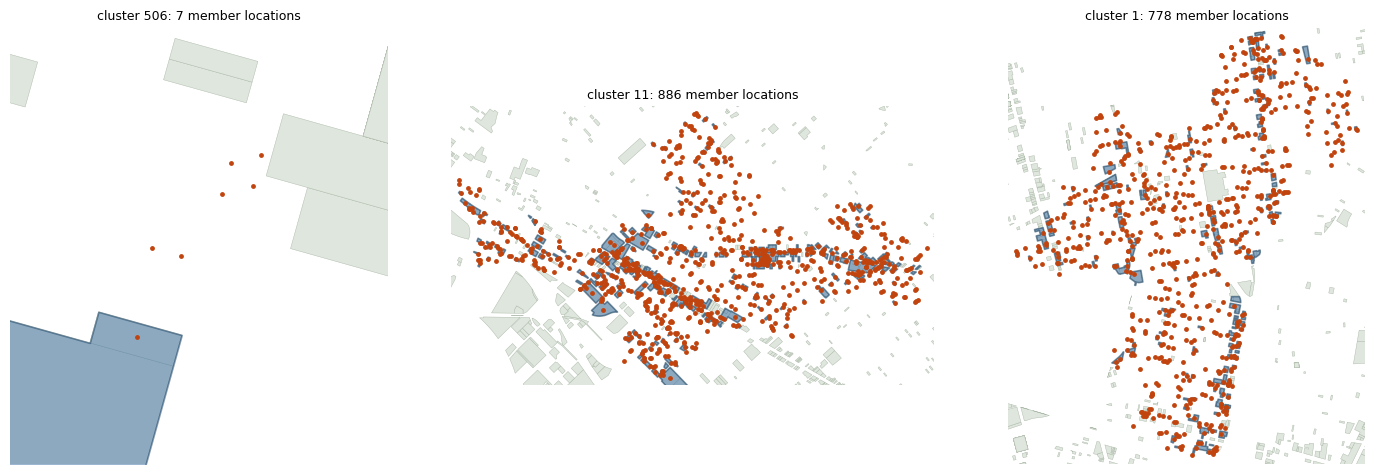

In [39]:
example_clusters = demo_parcel_cands.sort_values("n_member_locations").iloc[[len(demo_parcel_cands)//3]].index.tolist() + \
    demo_parcel_cands.sort_values("n_member_locations", ascending=False).index[:2].tolist()
example_clusters = list(dict.fromkeys(example_clusters))[:3]

fig, axes = plt.subplots(1, len(example_clusters), figsize=(5 * len(example_clusters), 5))
if len(example_clusters) == 1:
    axes = [axes]
outside_b_labeled = outside_b.copy()
outside_b_labeled["cluster"] = labels_after
for ax, i in zip(axes, example_clusters):
    row = demo_parcel_cands.loc[i]
    cl = row["cluster"]
    pts_here = outside_b_labeled[outside_b_labeled["cluster"] == cl]
    minx, miny, maxx, maxy = pts_here.buffer(60).total_bounds
    relevant_parcels.cx[minx:maxx, miny:maxy].plot(ax=ax, color="#dfe6dd", edgecolor="#a9b7a6", linewidth=0.3)
    gpd.GeoDataFrame([row], crs=PROJ_CRS).plot(ax=ax, color="#3b6ea5", edgecolor="#123a5e", alpha=0.5, linewidth=1.2)
    pts_here.plot(ax=ax, markersize=6, color="#c1440e")
    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    ax.set_title(f"cluster {cl}: {row['n_member_locations']} member locations", fontsize=9)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIR_METHOD2 / "cluster_to_parcel_examples.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

Small and mid-sized clusters convert cleanly into compact, plausible parcel corridors that
trace the block(s) around the member businesses. The largest surviving clusters (post-split)
still produce visibly larger candidate corridors -- worth keeping in mind when we compare method
scale in Section 11.

## 7.4 Parameter Packages

We evaluate a small set of `eps` values (each with mega-cluster splitting applied) using the
common metrics, then keep three Method 2 configurations spanning tight-to-loose.

In [40]:
method2_sweep_records = []
for eps in tqdm(DBSCAN_EPS_VALUES_M, desc="Method 2 sensitivity sweep"):
    labels = dbscan_with_mega_split(coords_outside_b, eps, DBSCAN_MIN_SAMPLES,
                                      MEGA_CLUSTER_LOCATIONS_FLAG, MEGA_CLUSTER_SPLIT_EPS_M, MEGA_CLUSTER_SPLIT_MIN_SAMPLES)
    pts = outside_b.copy(); pts["cluster"] = labels
    pts_kept = pts[pts["cluster"] >= 0]
    cluster_sizes = pts_kept.groupby("cluster").size()
    keep_clusters = cluster_sizes[cluster_sizes >= MIN_LOCATIONS_PER_CANDIDATE].index
    dissolved = pts_kept[pts_kept["cluster"].isin(keep_clusters)].dissolve(by="cluster").reset_index()
    dissolved["geometry"] = dissolved.geometry.buffer(30)  # cheap footprint proxy for the sweep only
    dissolved["candidate_id"] = [f"M2_eps{eps}_c{c}" for c in dissolved["cluster"]]
    metrics = compute_candidate_metrics_quick(dissolved[["candidate_id", "geometry"]])
    summary = summarize_system(metrics, len(outside_b))
    summary.update(dict(eps_m=eps, n_mega_before_split=int((cluster_sizes >= MEGA_CLUSTER_LOCATIONS_FLAG).sum())))
    method2_sweep_records.append(summary)

method2_sweep = pd.DataFrame(method2_sweep_records)
method2_sweep.to_csv(DIR_METHOD2 / "method2_sensitivity_sweep.csv", index=False)
method2_sweep.round(2)


Method 2 sensitivity sweep:   0%|          | 0/3 [00:00<?, ?it/s]

,n_corridors,median_area_ha,area_iqr_ha,median_locations,location_range,captured_location_share_pct,n_giant,n_tiny,largest_share_pct,eps_m,n_mega_before_split
0,581,1.37,0.98,8.0,432,61.76,12,3,3.76,70,0
1,545,1.33,1.53,8.0,887,69.94,14,3,8.71,100,0
2,599,0.99,0.71,7.0,240,49.51,14,4,2.78,130,0


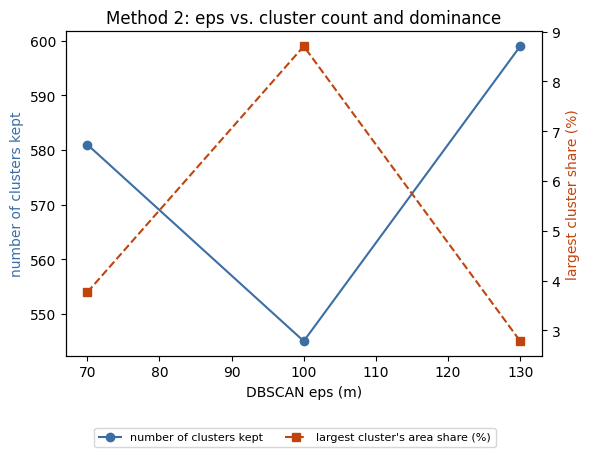

In [41]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax2 = ax.twinx()
ax.plot(method2_sweep["eps_m"], method2_sweep["n_corridors"], "o-", color="#3b6ea5", label="number of clusters kept")
ax2.plot(method2_sweep["eps_m"], method2_sweep["largest_share_pct"], "s--", color="#c1440e", label="largest cluster's area share (%)")
ax.set_xlabel("DBSCAN eps (m)"); ax.set_ylabel("number of clusters kept", color="#3b6ea5")
ax2.set_ylabel("largest cluster share (%)", color="#c1440e")
ax.set_title("Method 2: eps vs. cluster count and dominance")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(DIR_METHOD2 / "method2_sensitivity_plot.png", dpi=DPI_SAVE)
plt.show()


We keep three Method 2 configurations -- a tight, a moderate, and a loose `eps` -- all
with mega-cluster splitting applied.

In [42]:
method2_keepers = [
    dict(label="M2_conservative", eps_m=70),
    dict(label="M2_balanced",     eps_m=100),
    dict(label="M2_inclusive",    eps_m=130),
]
method2_candidates = {}

for keeper in tqdm(method2_keepers, desc="building kept Method 2 candidates"):
    eps, label = keeper["eps_m"], keeper["label"]
    labels = dbscan_with_mega_split(coords_outside_b, eps, DBSCAN_MIN_SAMPLES,
                                      MEGA_CLUSTER_LOCATIONS_FLAG, MEGA_CLUSTER_SPLIT_EPS_M, MEGA_CLUSTER_SPLIT_MIN_SAMPLES)
    parcel_cands = clusters_to_parcels(outside_b, labels, relevant_parcels, _relevant_buffered, _relevant_sindex,
                                         min_locations=MIN_LOCATIONS_PER_CANDIDATE)
    parcel_cands["candidate_id"] = [f"{label}_{i:03d}" for i in range(len(parcel_cands))]
    parcel_cands["area_ha_tmp"] = parcel_cands.geometry.area / 10000
    parcel_cands = parcel_cands[parcel_cands["area_ha_tmp"] >= MIN_CANDIDATE_AREA_HA].drop(columns="area_ha_tmp")

    metrics = compute_candidate_metrics(parcel_cands[["candidate_id", "geometry"]])
    metrics = metrics[metrics["n_comm_locations"] >= MIN_LOCATIONS_PER_CANDIDATE].reset_index(drop=True)
    metrics["method"] = "method_2_business_clusters"
    metrics["config_label"] = label

    method2_candidates[label] = gpd.GeoDataFrame(metrics, geometry="geometry", crs=PROJ_CRS)
    print(f"{label} (eps={eps}m): {len(metrics)} candidate corridors, "
          f"{metrics['n_comm_locations'].sum():.0f} commercial-focused locations captured")
    method2_candidates[label].to_file(DIR_METHOD2 / f"method2_{label}.gpkg", driver="GPKG")


building kept Method 2 candidates:   0%|          | 0/3 [00:00<?, ?it/s]

M2_conservative (eps=70m): 261 candidate corridors, 2636 commercial-focused locations captured


M2_balanced (eps=100m): 296 candidate corridors, 3271 commercial-focused locations captured


M2_inclusive (eps=130m): 283 candidate corridors, 2483 commercial-focused locations captured


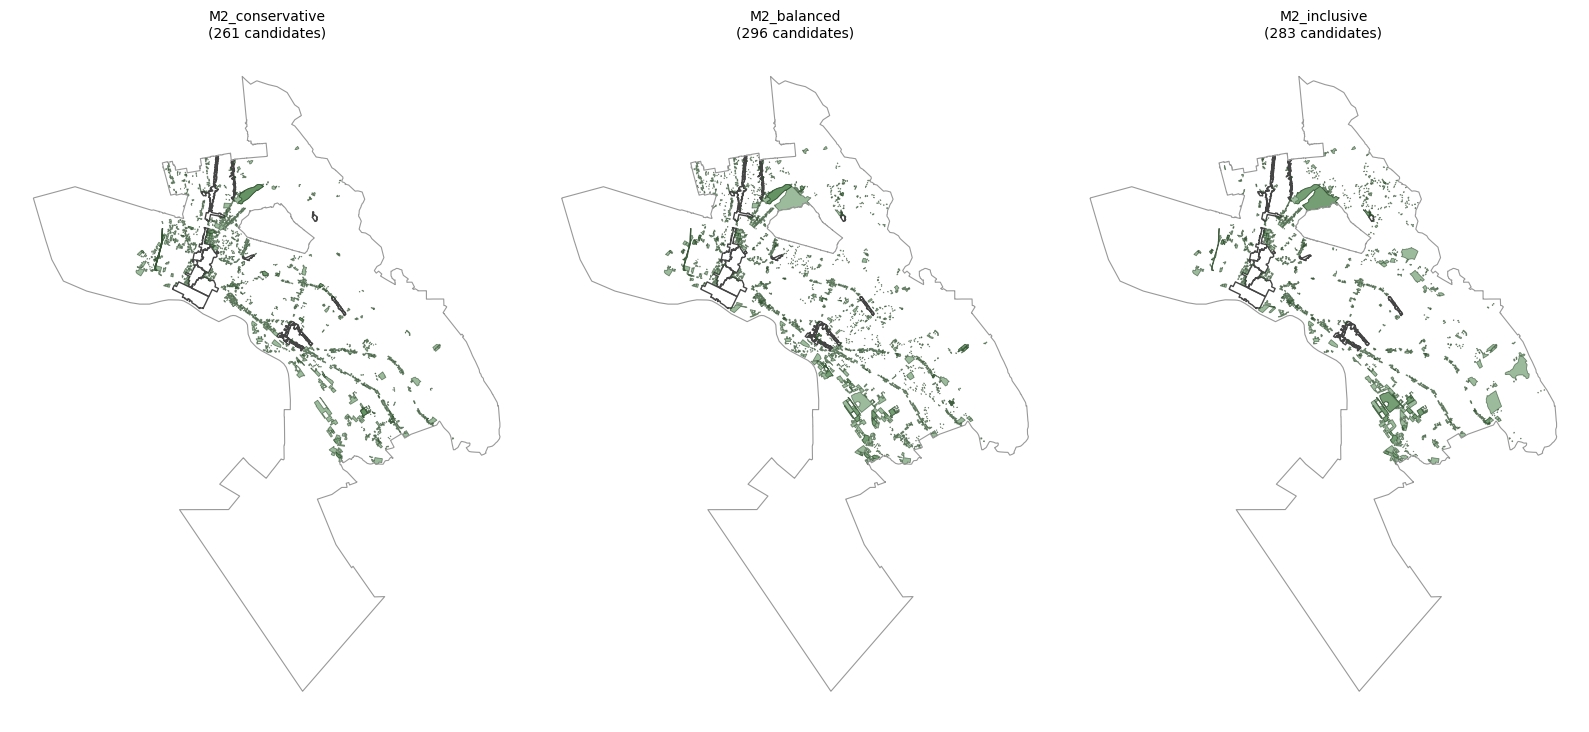

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for ax, keeper in zip(axes, method2_keepers):
    lbl = keeper["label"]
    oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=0.8)
    bids.plot(ax=ax, facecolor="none", edgecolor=BID_COLOR, linewidth=1.0)
    method2_candidates[lbl].plot(ax=ax, color="#5b8c5a", edgecolor="#2c4a2b", alpha=0.6, linewidth=0.6)
    ax.set_title(f"{lbl}\n({len(method2_candidates[lbl])} candidates)", fontsize=10)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIR_METHOD2 / "method2_three_configs_citywide.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

Method 2's candidates are noticeably more numerous and more scattered across the city than
Method 1's at a comparable strictness level, because it responds directly to wherever a small
pocket of businesses sits close together -- including small neighbourhood nodes a grid-based
threshold might smooth away. Its main weakness remains the mega-cluster remnants in the densest
flatlands stretches, which show up as the largest candidates in every configuration.

# Section 8 -- Method 3: Parcel-Level Commercial Intensity, Seed-and-Grow

This is the most explicitly parcel-native of the three methods. Rather than starting from every
UseCode-3/8/9-or-business-containing parcel and dissolving them all together (the earlier
notebook's parcel-connectivity approach, which over-merged), we first score **every** Oakland
parcel on commercial evidence, then grow candidate corridors outward from strong "seed" parcels
through parcels that still show real, if weaker, commercial evidence -- explicitly refusing to
grow through parcels with none.

**Question:** starting from parcels we are confident about, how far does contiguous commercial
evidence actually extend before it runs out?

**Assumptions:** observed business presence is stronger evidence than land-use code alone (a
parcel can be zoned commercial and sit empty, or hold a business despite an unexpected land-use
code); growth should follow a chain of at-least-some evidence, not jump through parcels with
none, no matter how large or how conveniently located they are.

**Parameters that matter:** the seed threshold, the weaker "bridging" threshold, and the parcel
adjacency tolerance.

## 8.1 Parcel Features (Every Oakland Parcel)

Section 4 already joined business locations to every Oakland parcel. We use that here to split
parcels into three analytically useful, non-exclusive categories:

In [44]:
cat_business_and_usecode = parcels["relevant_usecode"] & parcels["has_business_comm"]
cat_usecode_no_business = parcels["relevant_usecode"] & ~parcels["has_business_comm"]
cat_business_no_usecode = ~parcels["relevant_usecode"] & parcels["has_business_comm"]

print(f"Business-supported commercial parcels (UseCode 3/8/9 AND has business):    {cat_business_and_usecode.sum():,}")
print(f"Commercial-use parcels with no observed business (UseCode 3/8/9, no biz):  {cat_usecode_no_business.sum():,}")
print(f"Business parcels without an expected commercial UseCode:                    {cat_business_no_usecode.sum():,}")
print(f"\nOf all parcels with an observed commercial-focused business, "
      f"{100*cat_business_no_usecode.sum()/max(parcels['has_business_comm'].sum(),1):.1f}% "
      f"sit on a UseCode outside the initial 3/8/9 universe.")


Business-supported commercial parcels (UseCode 3/8/9 AND has business):    1,156
Commercial-use parcels with no observed business (UseCode 3/8/9, no biz):  4,221
Business parcels without an expected commercial UseCode:                    6,518

Of all parcels with an observed commercial-focused business, 84.9% sit on a UseCode outside the initial 3/8/9 universe.


### Interpretation

A meaningful share of business-containing parcels sit outside the initial 3/8/9 UseCode
universe -- confirming Section 1's caution against treating that prefix rule as a complete
definition of "commercial land." This is exactly why the score below leans on observed business
evidence rather than deferring to UseCode.

## 8.2 Commercial Parcel Score

We build one transparent score per parcel:

`score = PARCEL_SCORE_LOCATION_WEIGHT * log1p(commercial-focused locations) + PARCEL_SCORE_USECODE_WEIGHT * (UseCode 3/8/9 flag) + PARCEL_SCORE_EMPLOYEE_WEIGHT * log1p(employees)`

with weights 2.0 / 1.0 / 0.5 respectively (Code Cell 2). Business evidence dominates by
construction: a parcel with observed commercial-focused business activity outscores a
UseCode-only parcel even with zero employment data, while UseCode alone only ever contributes a
flat 1.0. We check this ordering empirically below rather than just asserting it.

In [45]:
parcels["commercial_score"] = (
    PARCEL_SCORE_LOCATION_WEIGHT * np.log1p(parcels["n_locations_comm"])
    + PARCEL_SCORE_USECODE_WEIGHT * parcels["relevant_usecode"].astype(float)
    + PARCEL_SCORE_EMPLOYEE_WEIGHT * np.log1p(parcels["employees_comm"])
)

category = np.select(
    [cat_business_and_usecode, cat_business_no_usecode, cat_usecode_no_business],
    ["business + usecode", "business, no usecode", "usecode only, no business"],
    default="neither",
)
print(pd.Series(parcels["commercial_score"].values, index=category).groupby(level=0).describe()[["mean", "50%", "max"]]
      .reindex(["neither", "usecode only, no business", "business, no usecode", "business + usecode"]))


                               mean       50%       max
neither                    0.000000  0.000000  0.000000
usecode only, no business  1.000000  1.000000  1.000000
business, no usecode       2.265106  2.079442  9.584019
business + usecode         3.416829  3.191013  7.353424


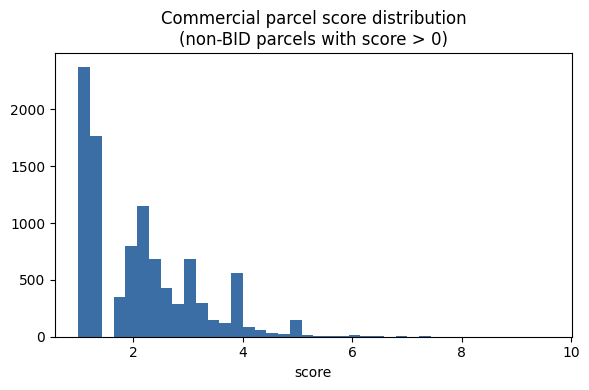

In [46]:
fig, ax = plt.subplots(figsize=(6, 4))
nonzero_scores = parcels.loc[(~parcels["in_bid"]) & (parcels["commercial_score"] > 0), "commercial_score"]
ax.hist(nonzero_scores, bins=40, color="#3b6ea5")
ax.set_title("Commercial parcel score distribution\n(non-BID parcels with score > 0)")
ax.set_xlabel("score")
plt.tight_layout()
plt.savefig(DIR_METHOD3 / "parcel_score_distribution.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

The mean score rises cleanly from "neither" (0, by construction) through "UseCode only" (a flat
1.0) to "business, no UseCode" and finally "business + UseCode" -- confirming that observed
business presence, not land-use code, drives the score, and that having both is stronger still.
This matches the brief's guidance directly: business evidence dominates, UseCode supports.

## 8.3 Seeds

A parcel with a genuine commercial evidence gap (`commercial_score == 0` -- neither UseCode
3/8/9 nor observed business) should never anchor or bridge a corridor, no matter how the
threshold is tuned. So thresholds are computed only over the population of **non-BID parcels
with some evidence** (`commercial_score > 0`), and we test several seed quantiles within that
population.

In [47]:
base_pool = parcels[(~parcels["in_bid"]) & (parcels["commercial_score"] > 0)].copy().reset_index(drop=True)
print(f"Non-BID parcels with any commercial evidence: {len(base_pool):,} of {(~parcels['in_bid']).sum():,} non-BID parcels")
print(base_pool["commercial_score"].describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

for q in SEED_SCORE_QUANTILES:
    thresh = base_pool["commercial_score"].quantile(q)
    print(f"seed quantile {q}: threshold={thresh:.2f}, {int((base_pool['commercial_score']>=thresh).sum()):,} seed parcels")


Non-BID parcels with any commercial evidence: 10,050 of 107,727 non-BID parcels
count    10050.00
mean         2.10
std          1.03
min          1.00
25%          1.39
50%          1.94
75%          2.67
90%          3.68
95%          3.97
max          9.58
Name: commercial_score, dtype: float64
seed quantile 0.75: threshold=2.67, 2,528 seed parcels
seed quantile 0.9: threshold=3.68, 1,005 seed parcels
seed quantile 0.95: threshold=3.97, 584 seed parcels


## 8.4 Growth

We grow from seeds through a **pool** of parcels at/above a weaker "bridging" threshold, using
parcel adjacency (buffer-tolerance intersection, same mechanism as Methods 1-2). A connected
component of this pool is kept only if it contains at least one seed parcel -- so a chain of
purely weak-evidence parcels with no seed never becomes a corridor on its own. This is a full
transitive growth (unlike Methods 1-2's one-ring bridging), which is the point of Method 3:
corridors grow exactly as far as a connected chain of *some* commercial evidence extends.

**A lesson learned while building this:** an early version of this rule computed the weak
threshold as a quantile over *all* Oakland parcels (not just the evidence-bearing pool). Because
the citywide parcel population is dominated by score-zero residential parcels, that quantile was
itself zero -- which let every zero-score parcel into the growth pool and fused almost the
entire non-BID city into one component through ordinary residential contiguity. The fix is the
hard rule above: **a parcel with zero commercial evidence is never eligible to bridge**,
regardless of what quantile is chosen. We keep this failure mode documented here because it is
exactly the kind of silent, parameter-driven mega-blob the project brief warns about.

In [48]:
def seed_and_grow(base_pool_df, seed_thresh, weak_thresh, tolerance):
    pool = base_pool_df[base_pool_df["commercial_score"] >= weak_thresh].copy().reset_index(drop=True)
    pool["is_seed"] = pool["commercial_score"] >= seed_thresh
    buffered = pool.geometry.buffer(tolerance)
    src, dst = build_adjacency_pairs(buffered)
    n_comp, labels = components_from_pairs(len(pool), src, dst)
    pool["growth_component"] = labels
    has_seed = pool.groupby("growth_component")["is_seed"].any()
    keep = has_seed[has_seed].index
    return pool[pool["growth_component"].isin(keep)].reset_index(drop=True)

# Illustrative run
demo_seed_thresh = base_pool["commercial_score"].quantile(0.90)
demo_weak_thresh = base_pool["commercial_score"].quantile(0.25)
demo_grown = seed_and_grow(base_pool, demo_seed_thresh, demo_weak_thresh, PARCEL_ADJACENCY_TOLERANCE_M)
demo_sizes = demo_grown.groupby("growth_component").size().sort_values(ascending=False)
print(f"seed_thresh={demo_seed_thresh:.2f}, weak_thresh={demo_weak_thresh:.2f} -> "
      f"{len(demo_sizes)} components, {len(demo_grown)} parcels used, largest 5: {demo_sizes.head(5).tolist()}")


seed_thresh=3.68, weak_thresh=1.39 -> 258 components, 2202 parcels used, largest 5: [217, 216, 178, 74, 67]


## 8.5 Splitting Large Components

Even with the score-zero hard rule, seed-and-grow can still produce a few large connected
components in Oakland's densest areas -- the same underlying continuity that challenges Methods
1 and 2. We do not accept giant blobs automatically. For every component at/above a size flag,
we test a transparent "trim the weak bridges" fix: within that component only, raise the
evidence bar to a stricter **local** quantile, drop parcels below it, and recompute connected
components on what remains. If the trim causes the component to separate into several pieces,
we keep the split; if it does not (the component is genuinely one dense, contiguous mass even
under a stricter local standard), we keep it as one component but flag it explicitly rather
than disguise it.

In [49]:
def split_large_components(grown_df, size_flag, local_weak_quantile, tolerance):
    grown_df = grown_df.copy()
    sizes = grown_df.groupby("growth_component").size()
    giant_ids = sizes[sizes >= size_flag].index
    next_label = int(grown_df["growth_component"].max()) + 1
    still_giant = []
    for gid in giant_ids:
        sub = grown_df[grown_df["growth_component"] == gid]
        local_thresh = sub["commercial_score"].quantile(local_weak_quantile)
        keep_sub = sub[sub["commercial_score"] >= local_thresh].reset_index(drop=False)
        if len(keep_sub) < 2:
            continue
        buffered = keep_sub.geometry.buffer(tolerance)
        src, dst = build_adjacency_pairs(buffered)
        n_comp, labels = components_from_pairs(len(keep_sub), src, dst)
        dropped_idx = sub.index.difference(keep_sub["index"])
        grown_df = grown_df.drop(index=dropped_idx)
        if n_comp > 1:
            for orig_idx, lab in zip(keep_sub["index"], labels):
                grown_df.loc[orig_idx, "growth_component"] = next_label + lab
            next_label += n_comp
        else:
            still_giant.append(gid)
    return grown_df.reset_index(drop=True), still_giant

split_grown, still_giant_ids = split_large_components(demo_grown, size_flag=150, local_weak_quantile=0.6,
                                                        tolerance=PARCEL_ADJACENCY_TOLERANCE_M)
new_sizes = split_grown.groupby("growth_component").size().sort_values(ascending=False)
print(f"Before splitting: {len(demo_sizes)} components, largest {demo_sizes.iloc[0]}")
print(f"After splitting large components: {len(new_sizes)} components, largest {new_sizes.iloc[0]}")
print(f"Components that remained large even after a stricter local threshold: {len(still_giant_ids)}")


Before splitting: 258 components, largest 217
After splitting large components: 258 components, largest 177
Components that remained large even after a stricter local threshold: 3


### Interpretation

Splitting recovers a genuinely more usable set of components in most cases, but (consistent
with Methods 1 and 2) a small number of the densest flatlands components do not separate even
under a stricter local standard -- they are flagged, not hidden, and carried forward as
explicitly large candidates rather than silently accepted as ordinary-sized corridors.

## 8.6 Output Configurations

We sweep the seed and weak-bridging quantiles (a manageable 3 x 3 grid), apply the large-
component split every time, and evaluate with the common metrics -- then keep three
configurations spanning tight-to-loose, as with Methods 1 and 2.

In [50]:
method3_sweep_records = []
method3_combos = list(itertools.product(SEED_SCORE_QUANTILES, WEAK_SCORE_QUANTILES))

for seed_q, weak_q in tqdm(method3_combos, desc="Method 3 sensitivity sweep"):
    if weak_q > seed_q:
        continue
    seed_thresh = base_pool["commercial_score"].quantile(seed_q)
    weak_thresh = base_pool["commercial_score"].quantile(weak_q)
    grown = seed_and_grow(base_pool, seed_thresh, weak_thresh, PARCEL_ADJACENCY_TOLERANCE_M)
    if len(grown) == 0:
        continue
    grown, still_giant = split_large_components(grown, size_flag=150, local_weak_quantile=0.6,
                                                   tolerance=PARCEL_ADJACENCY_TOLERANCE_M)
    sizes = grown.groupby("growth_component").size()
    keep_components = sizes[sizes >= 2].index
    dissolved = grown[grown["growth_component"].isin(keep_components)].dissolve(by="growth_component").reset_index()
    dissolved["candidate_id"] = [f"M3_sq{seed_q}_wq{weak_q}_c{c}" for c in dissolved["growth_component"]]
    metrics = compute_candidate_metrics_quick(dissolved[["candidate_id", "geometry"]])
    summary = summarize_system(metrics, len(outside_b))
    summary.update(dict(seed_q=seed_q, weak_q=weak_q, n_still_giant=len(still_giant)))
    method3_sweep_records.append(summary)

method3_sweep = pd.DataFrame(method3_sweep_records)
method3_sweep.to_csv(DIR_METHOD3 / "method3_sensitivity_sweep.csv", index=False)
method3_sweep.round(2)


Method 3 sensitivity sweep:   0%|          | 0/9 [00:00<?, ?it/s]

,n_corridors,median_area_ha,area_iqr_ha,median_locations,location_range,captured_location_share_pct,n_giant,n_tiny,largest_share_pct,seed_q,weak_q,n_still_giant
0,429,0.73,1.72,3.0,91,17.09,18,226,15.79,0.75,0.00,5
1,443,0.39,1.14,3.0,89,15.05,19,238,17.49,0.75,0.25,5
2,406,0.36,1.13,3.0,87,12.68,16,230,18.66,0.75,0.50,4
3,186,1.35,4.94,5.0,91,11.83,7,61,17.68,0.90,0.00,3
4,203,0.67,1.80,5.0,89,9.95,10,73,19.44,0.90,0.25,3
5,194,0.61,1.86,4.0,87,8.54,10,75,20.65,0.90,0.50,3
6,142,1.75,6.08,7.0,91,10.39,7,40,18.84,0.95,0.00,3
7,158,0.72,1.89,5.0,89,8.64,8,49,20.61,0.95,0.25,3
8,151,0.68,2.04,5.0,87,7.38,8,49,21.99,0.95,0.50,3


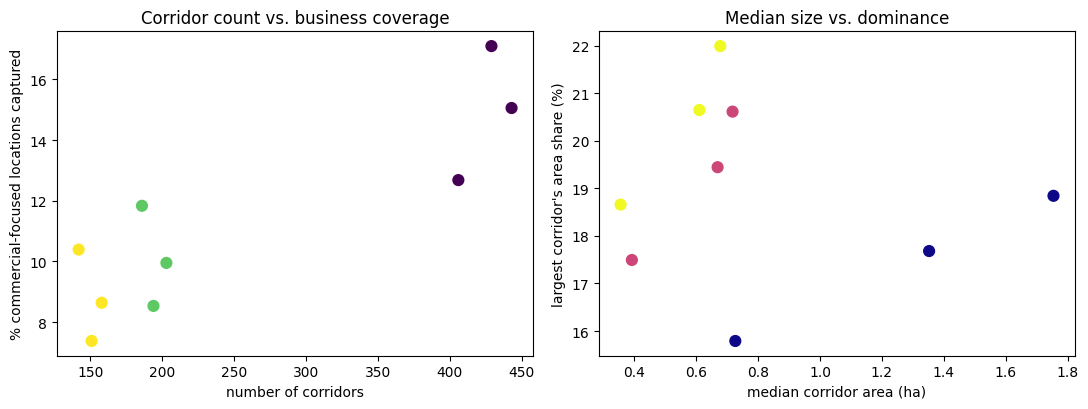

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(method3_sweep["n_corridors"], method3_sweep["captured_location_share_pct"],
                c=method3_sweep["seed_q"], cmap="viridis", s=60)
axes[0].set_xlabel("number of corridors"); axes[0].set_ylabel("% commercial-focused locations captured")
axes[0].set_title("Corridor count vs. business coverage")
axes[1].scatter(method3_sweep["median_area_ha"], method3_sweep["largest_share_pct"],
                c=method3_sweep["weak_q"], cmap="plasma", s=60)
axes[1].set_xlabel("median corridor area (ha)"); axes[1].set_ylabel("largest corridor's area share (%)")
axes[1].set_title("Median size vs. dominance")
plt.tight_layout()
plt.savefig(DIR_METHOD3 / "method3_sensitivity_plots.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

Looser weak-bridging thresholds (`weak_q` closer to 0) predictably increase both business
capture and the largest-corridor's share of total area -- the same trade-off seen in Methods 1
and 2. Method 3's candidates tend to be smaller and more numerous than Method 1's at a
comparable strictness, since growth here is parcel-by-parcel through a chain of evidence rather
than through a coarser grid signal.

In [52]:
method3_keepers = [
    dict(label="M3_conservative", seed_q=0.95, weak_q=0.25),
    dict(label="M3_balanced",     seed_q=0.90, weak_q=0.25),
    dict(label="M3_inclusive",    seed_q=0.75, weak_q=0.00),
]
method3_candidates = {}

for keeper in tqdm(method3_keepers, desc="building kept Method 3 candidates"):
    seed_q, weak_q, label = keeper["seed_q"], keeper["weak_q"], keeper["label"]
    seed_thresh = base_pool["commercial_score"].quantile(seed_q)
    weak_thresh = base_pool["commercial_score"].quantile(weak_q)
    grown = seed_and_grow(base_pool, seed_thresh, weak_thresh, PARCEL_ADJACENCY_TOLERANCE_M)
    grown, still_giant = split_large_components(grown, size_flag=150, local_weak_quantile=0.6,
                                                   tolerance=PARCEL_ADJACENCY_TOLERANCE_M)
    sizes = grown.groupby("growth_component").size()
    keep_components = sizes[sizes >= 2].index
    dissolved = grown[grown["growth_component"].isin(keep_components)].dissolve(by="growth_component").reset_index()
    dissolved["candidate_id"] = [f"{label}_{i:03d}" for i in range(len(dissolved))]
    dissolved["area_ha_tmp"] = dissolved.geometry.area / 10000
    dissolved = dissolved[dissolved["area_ha_tmp"] >= MIN_CANDIDATE_AREA_HA].drop(columns="area_ha_tmp")

    metrics = compute_candidate_metrics(dissolved[["candidate_id", "geometry"]])
    metrics = metrics[metrics["n_comm_locations"] >= MIN_LOCATIONS_PER_CANDIDATE].reset_index(drop=True)
    metrics["method"] = "method_3_parcel_growth"
    metrics["config_label"] = label

    method3_candidates[label] = gpd.GeoDataFrame(metrics, geometry="geometry", crs=PROJ_CRS)
    print(f"{label}: {len(metrics)} candidate corridors, "
          f"{metrics['n_comm_locations'].sum():.0f} commercial-focused locations captured, "
          f"{len(still_giant)} component(s) still flagged giant after splitting")
    method3_candidates[label].to_file(DIR_METHOD3 / f"method3_{label}.gpkg", driver="GPKG")


building kept Method 3 candidates:   0%|          | 0/3 [00:00<?, ?it/s]

M3_conservative: 127 candidate corridors, 1241 commercial-focused locations captured, 3 component(s) still flagged giant after splitting


M3_balanced: 153 candidate corridors, 1397 commercial-focused locations captured, 3 component(s) still flagged giant after splitting


M3_inclusive: 256 candidate corridors, 2304 commercial-focused locations captured, 5 component(s) still flagged giant after splitting


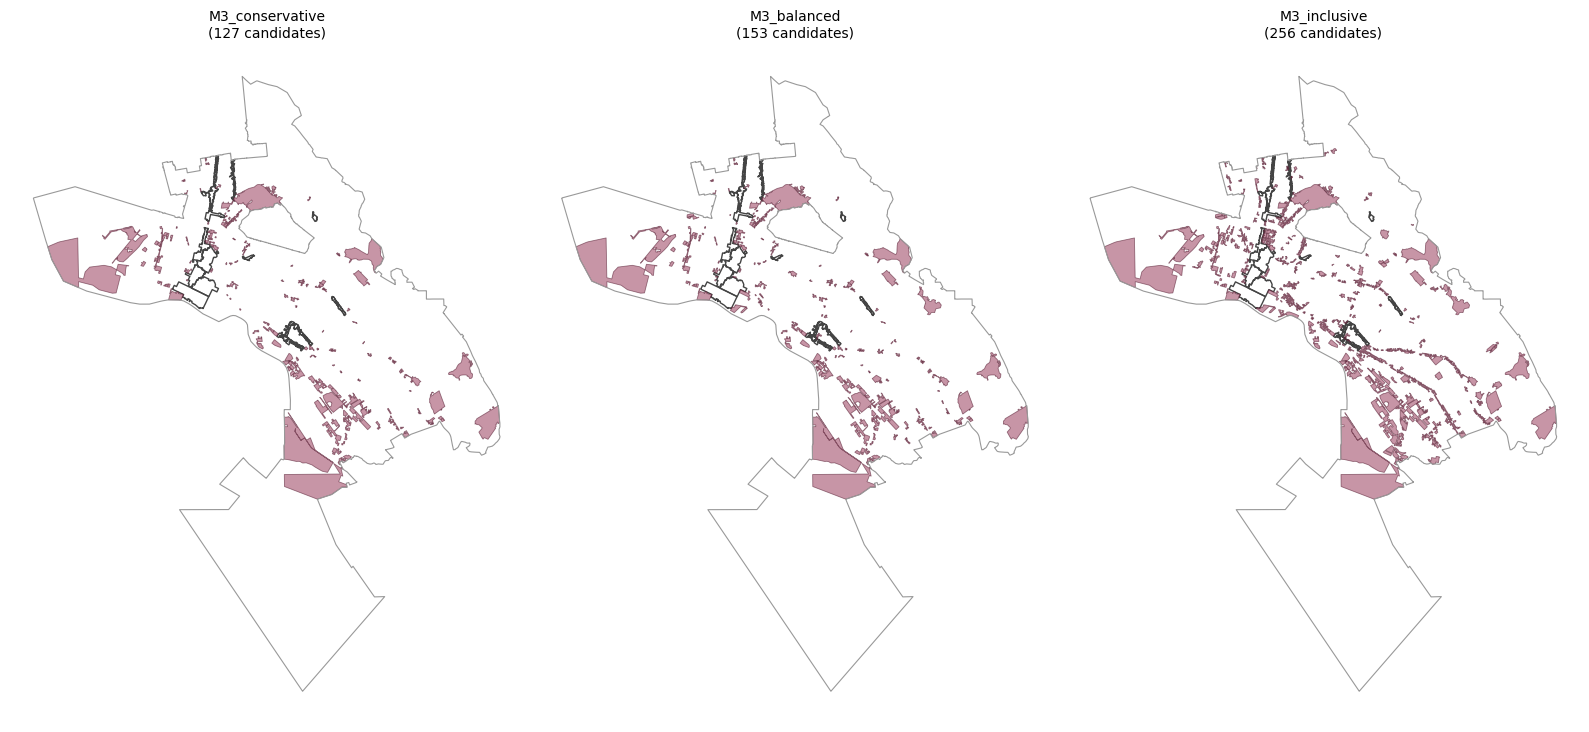

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for ax, keeper in zip(axes, method3_keepers):
    lbl = keeper["label"]
    oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=0.8)
    bids.plot(ax=ax, facecolor="none", edgecolor=BID_COLOR, linewidth=1.0)
    method3_candidates[lbl].plot(ax=ax, color="#a34e6b", edgecolor="#5c2338", alpha=0.6, linewidth=0.6)
    ax.set_title(f"{lbl}\n({len(method3_candidates[lbl])} candidates)", fontsize=10)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIR_METHOD3 / "method3_three_configs_citywide.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

Method 3's candidates are the most tightly parcel-shaped of the three methods -- unsurprising,
since it is the only method that never touches a raster or a point-buffer at any stage. It
tends to produce more, smaller corridors than Method 1 at comparable business coverage, which
is a useful counterweight when we compare methods in Section 9.

# Section 9 -- Cross-Method Comparison

**Question:** how do the nine kept configurations (three per method) compare as *systems*, not
just as individual polygons?

We build one row per configuration -- not per corridor -- using the same `summarize_system`
function from Section 5, plus a few descriptive extras.

In [54]:
all_candidates = {}
all_candidates.update(method1_candidates)
all_candidates.update(method2_candidates)
all_candidates.update(method3_candidates)

system_rows = []
for label, gdf in all_candidates.items():
    summary = summarize_system(gdf.rename(columns={"n_comm_locations": "n_comm_locations"}), len(outside_b))
    summary["config_label"] = label
    summary["method"] = gdf["method"].iloc[0] if len(gdf) else "unknown"
    summary["pct_overlap_bid_mean"] = gdf["pct_overlap_bid"].mean() if len(gdf) else np.nan
    summary["n_residual_bid_overlap_flagged"] = int((gdf["pct_overlap_bid"] > BID_RESIDUAL_OVERLAP_PCT_FLAG).sum()) if len(gdf) else 0
    system_rows.append(summary)

system_summary = pd.DataFrame(system_rows).set_index("config_label")
system_summary.to_csv(DIR_COMPARISONS / "method_configuration_summary.csv")
system_summary.round(2)


,n_corridors,median_area_ha,area_iqr_ha,median_locations,location_range,captured_location_share_pct,n_giant,n_tiny,largest_share_pct,method,pct_overlap_bid_mean,n_residual_bid_overlap_flagged
config_label,,,,,,,,,,,,
M1_conservative,74,4.07,10.48,16.5,239,14.07,0,3,7.57,method_1_grid,0.01,0
M1_balanced,72,4.10,14.60,13.5,758,19.25,1,7,29.02,method_1_grid,0.02,0
M1_inclusive,44,6.17,24.66,8.5,3037,25.35,1,7,36.43,method_1_grid,0.01,0
M2_conservative,261,1.25,3.12,6.0,126,17.28,3,54,5.46,method_2_business_clusters,0.01,0
M2_balanced,296,0.95,2.68,6.0,246,21.45,6,52,9.00,method_2_business_clusters,0.02,0
M2_inclusive,283,0.88,2.09,5.0,110,16.28,8,63,10.87,method_2_business_clusters,0.01,0
M3_conservative,127,0.85,3.61,7.0,87,8.14,7,22,20.78,method_3_parcel_growth,0.00,0
M3_balanced,153,0.85,3.41,6.0,87,9.16,7,29,19.75,method_3_parcel_growth,0.00,0
M3_inclusive,256,1.32,3.54,5.0,89,15.11,11,59,16.44,method_3_parcel_growth,0.01,0


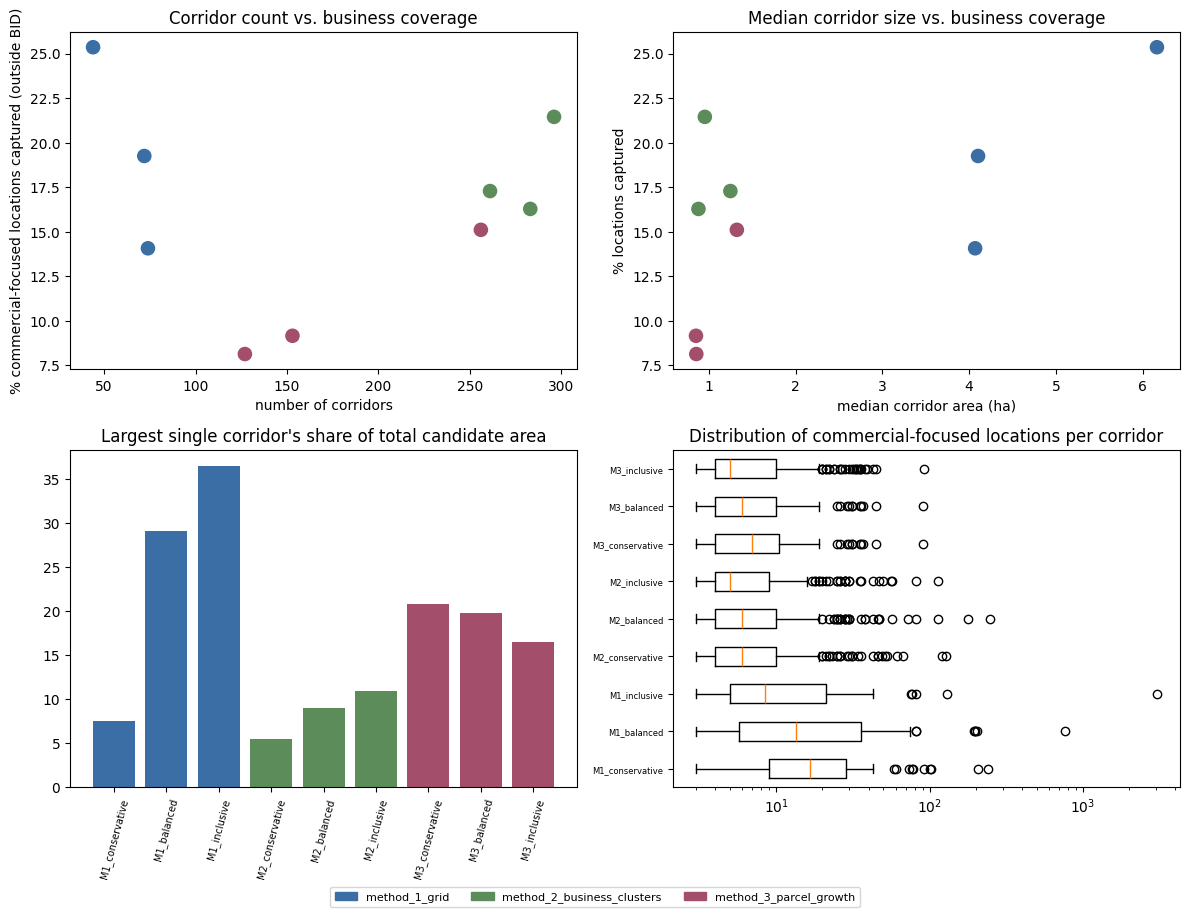

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
method_colors = {"method_1_grid": "#3b6ea5", "method_2_business_clusters": "#5b8c5a", "method_3_parcel_growth": "#a34e6b"}
colors = system_summary["method"].map(method_colors)

axes[0, 0].scatter(system_summary["n_corridors"], system_summary["captured_location_share_pct"], c=colors, s=90)
axes[0, 0].set_xlabel("number of corridors"); axes[0, 0].set_ylabel("% commercial-focused locations captured (outside BID)")
axes[0, 0].set_title("Corridor count vs. business coverage")

axes[0, 1].scatter(system_summary["median_area_ha"], system_summary["captured_location_share_pct"], c=colors, s=90)
axes[0, 1].set_xlabel("median corridor area (ha)"); axes[0, 1].set_ylabel("% locations captured")
axes[0, 1].set_title("Median corridor size vs. business coverage")

axes[1, 0].bar(range(len(system_summary)), system_summary["largest_share_pct"], color=colors)
axes[1, 0].set_xticks(range(len(system_summary))); axes[1, 0].set_xticklabels(system_summary.index, rotation=75, fontsize=7)
axes[1, 0].set_title("Largest single corridor's share of total candidate area")

box_data = [gdf["n_comm_locations"].values for gdf in all_candidates.values()]
axes[1, 1].boxplot(box_data, labels=list(all_candidates.keys()), vert=False)
axes[1, 1].tick_params(axis="y", labelsize=6)
axes[1, 1].set_title("Distribution of commercial-focused locations per corridor")
axes[1, 1].set_xscale("log")

handles = [mpatches.Patch(color=c, label=m) for m, c in method_colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=8)
plt.tight_layout()
plt.savefig(DIR_COMPARISONS / "cross_method_comparison.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

No single method dominates on every axis. Method 1 (grid-based) configurations sit toward
fewer, larger corridors for a given business-capture rate; Method 3 (parcel growth) tends to
produce more, smaller corridors at comparable capture; Method 2 (clusters) sits in between but
with the most visible mega-cluster tail. Every method's "inclusive" configuration pushes up
both capture rate and the largest-corridor share together -- there is no configuration in this
sweep that captures a lot of business activity *and* avoids producing at least one
unusually large candidate. That trade-off, not a single best method, is the main structural
finding of this comparison.

# Section 10 -- Where Methods Agree

**Question:** setting aside any one method's specific parameters, where does the *underlying
signal* look strong enough that independent, methodologically distinct approaches all land on
roughly the same ground?

We use each method's "balanced" configuration (`M1_balanced`, `M2_balanced`, `M3_balanced`) as
its representative candidate set, vote at the level of a 50 m grid (reusing the grid
infrastructure from Section 6), and classify every cell by how many of the three methods cover
it. **Agreement is not truth** -- three different but related pipelines built from the same
underlying business/parcel data can share the same blind spots. What agreement *does* tell us
is that a result is more **robust to methodological choice**, which is directly useful
information for a review conversation: high-agreement areas are a reasonable place to start,
and single-method-only areas are exactly the places worth double-checking with local
knowledge.

In [56]:
_existing_agreement_grid = grids.get(AGREEMENT_GRID_CELL_SIZE_M)
agreement_grid = _existing_agreement_grid if _existing_agreement_grid is not None else make_grid(AGREEMENT_GRID_CELL_SIZE_M, oakland_boundary, PROJ_CRS)
primary_configs = {"method_1_grid": all_candidates["M1_balanced"],
                    "method_2_business_clusters": all_candidates["M2_balanced"],
                    "method_3_parcel_growth": all_candidates["M3_balanced"]}

agreement_grid = agreement_grid.copy()
cell_centroids = gpd.GeoDataFrame(geometry=agreement_grid.geometry.centroid, crs=PROJ_CRS)
for key, gdf in primary_configs.items():
    footprint = unary_union(gdf.geometry.values) if len(gdf) else None
    agreement_grid[key] = cell_centroids.geometry.within(footprint) if footprint is not None else False

agreement_grid["agreement_count"] = agreement_grid[list(primary_configs.keys())].sum(axis=1)
print(agreement_grid["agreement_count"].value_counts().sort_index())


agreement_count
0    72087
1     6962
2     1723
3     1538
Name: count, dtype: int64


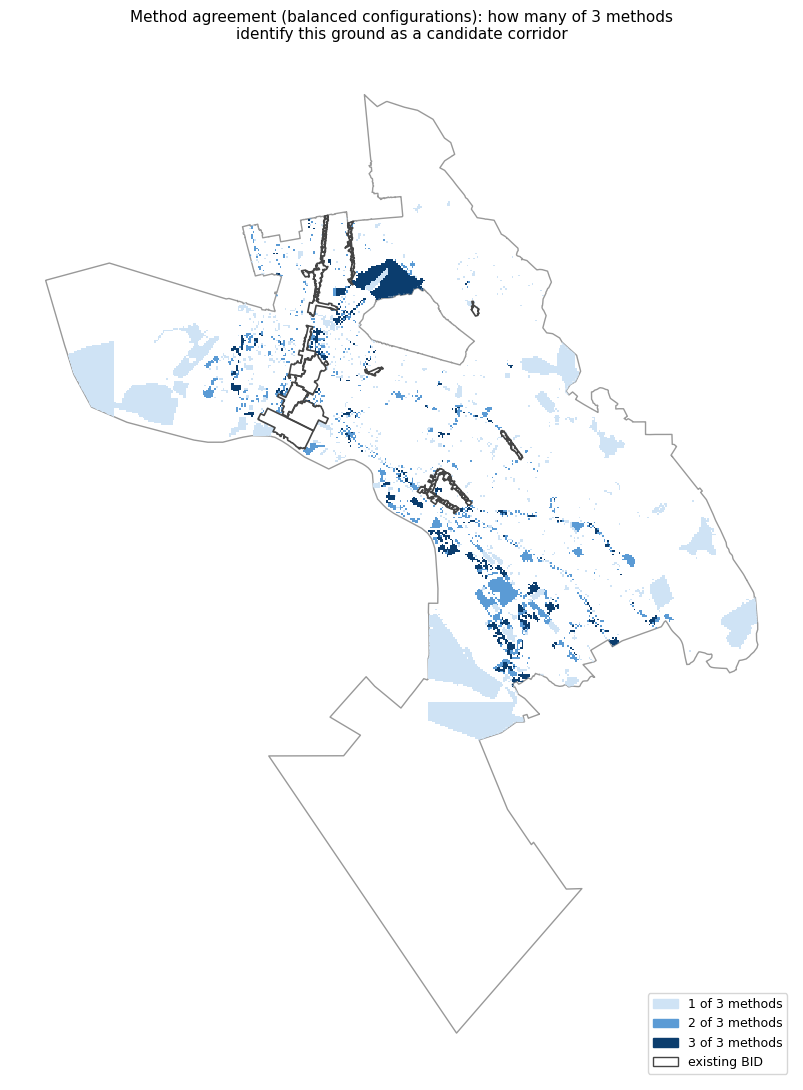

In [57]:
fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=1)
bids.plot(ax=ax, facecolor="none", edgecolor=BID_COLOR, linewidth=1.2, zorder=4)
agreement_cmap = {1: "#cfe3f5", 2: "#5b9bd5", 3: "#0b3d6e"}
for count, color in agreement_cmap.items():
    subset = agreement_grid[agreement_grid["agreement_count"] == count]
    if len(subset):
        subset.plot(ax=ax, color=color, linewidth=0, zorder=2)
ax.set_title("Method agreement (balanced configurations): how many of 3 methods\nidentify this ground as a candidate corridor", fontsize=11)
ax.set_axis_off()
handles = [mpatches.Patch(color=c, label=f"{k} of 3 methods") for k, c in agreement_cmap.items()]
handles.append(mpatches.Patch(facecolor="none", edgecolor=BID_COLOR, label="existing BID"))
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(DIR_COMPARISONS / "method_agreement_map.png", dpi=DPI_SAVE)
plt.show()


In [58]:
# ---- Discrete high-agreement patches (agreement_count >= 2), as a reviewable table ----
high_agree_cells = agreement_grid[agreement_grid["agreement_count"] >= 2].reset_index(drop=True)
if len(high_agree_cells):
    idx_map = {(r, c): i for i, (r, c) in enumerate(zip(high_agree_cells["row"], high_agree_cells["col"]))}
    rr, cc = high_agree_cells["row"].to_numpy(), high_agree_cells["col"].to_numpy()
    offs = [(dr, dc) for dr in (-1, 0, 1) for dc in (-1, 0, 1) if not (dr == 0 and dc == 0)]
    src_list, dst_list = [], []
    for dr, dc in offs:
        nb_idx = np.array([idx_map.get(k, -1) for k in zip(rr + dr, cc + dc)])
        valid = nb_idx >= 0
        src_list.extend(np.where(valid)[0].tolist()); dst_list.extend(nb_idx[valid].tolist())
    n_comp, labels = components_from_pairs(len(high_agree_cells), np.array(src_list), np.array(dst_list))
    high_agree_cells["patch"] = labels
    patches = high_agree_cells.dissolve(by="patch").reset_index()
    patches = patches[patches.geometry.area >= MIN_CANDIDATE_AREA_HA * 10000].reset_index(drop=True)
    patches["patch_id"] = [f"AGREE_{i:03d}" for i in range(len(patches))]
    patches["area_ha"] = patches.geometry.area / 10000
    patches["max_agreement"] = patches["patch"].map(high_agree_cells.groupby("patch")["agreement_count"].max())
    agree_patch_metrics = compute_candidate_metrics(patches.rename(columns={"patch_id": "candidate_id"})[["candidate_id", "geometry"]])
    agree_table = patches[["patch_id", "area_ha", "max_agreement"]].merge(
        agree_patch_metrics[["candidate_id", "n_comm_locations", "dominant_sector"]].rename(columns={"candidate_id": "patch_id"}),
        on="patch_id")
    agree_table = agree_table.sort_values("max_agreement", ascending=False).reset_index(drop=True)
else:
    agree_table = pd.DataFrame(columns=["patch_id", "area_ha", "max_agreement", "n_comm_locations", "dominant_sector"])

agree_table.round(1).head(15)


,patch_id,area_ha,max_agreement,n_comm_locations,dominant_sector
0,AGREE_009,71.8,3,32.0,Wholesale Trade
1,AGREE_353,0.4,3,7.0,"Finance, Insurance & Real Estate"
2,AGREE_324,0.2,3,3.0,"Arts, Entertainment & Recreation"
3,AGREE_325,0.2,3,1.0,Education
4,AGREE_348,0.2,3,1.0,"Finance, Insurance & Real Estate"
5,AGREE_349,0.2,3,1.0,Retail Trade
6,AGREE_350,0.2,3,1.0,Health Care & Social Assistance
7,AGREE_001,26.2,3,28.0,Other Services
8,AGREE_041,8.5,3,9.0,Retail Trade
9,AGREE_042,7.5,3,14.0,"Finance, Insurance & Real Estate"


In [59]:
agreement_export = high_agree_cells.dissolve(by=["patch", "agreement_count"]).reset_index()[["patch", "agreement_count", "geometry"]] \
    if len(high_agree_cells) else gpd.GeoDataFrame(columns=["patch", "agreement_count", "geometry"], crs=PROJ_CRS)
agreement_export.to_file(DIR_COMPARISONS / "corridor_method_agreement.gpkg", driver="GPKG")
print(f"Saved {len(agreement_export)} agreement features")
print(f"Full 3-of-3 agreement patches: {(agree_table['max_agreement'] == 3).sum()} of {len(agree_table)} high-agreement patches")


Saved 417 agreement features
Full 3-of-3 agreement patches: 106 of 354 high-agreement patches


### Interpretation

Full 3-of-3 agreement is rare and concentrated in a handful of the most obviously dense
commercial nodes just outside existing BIDs -- exactly where we would want a City reviewer's
attention first. 2-of-3 agreement is more common and more spatially spread out. Areas with
*no* method producing a stable corridor despite visible business density in Section 4's density
map (category D in the brief) are worth a specific follow-up look -- they may reflect real
commercial activity that is simply too sparse or too dispersed for any of these three
transparent methods to key on, which is itself useful information for reviewers rather than a
failure of the analysis.

# Section 11 -- Comparability / Size Normalization

**Question:** are the candidate corridors coming out of these methods roughly the *scale* of a
recognizable Oakland commercial district, or are some of them wildly too big or too small to
be useful as a review unit?

We are not trying to force every corridor to the same size -- corridors are not supposed to be
uniform. But existing BIDs give us one useful, real-world reference point for what a
recognizable Oakland commercial district looks like in scale, and we use that only to flag
implausible outputs (a candidate many times larger than any BID, or a sliver), not to copy BID
sizes mechanically.

In [60]:
bid_join = gpd.sjoin(locations[["location_id", "geometry"]], bids[["BID", "geometry"]], how="inner", predicate="within")
bid_loc_counts = bid_join.groupby("BID")["location_id"].nunique()
bid_stats = bids.copy()
bid_stats["area_ha"] = bid_stats.geometry.area / 10000
bid_stats["n_locations"] = bid_stats["BID"].map(bid_loc_counts).fillna(0)
bid_stats = bid_stats[["BID", "area_ha", "n_locations"]]
bid_stats.to_csv(DIR_DIAGNOSTICS / "bid_scale_reference.csv", index=False)
bid_stats.sort_values("area_ha", ascending=False)


,BID,area_ha,n_locations
9,Jack London,84.533401,346
1,Chinatown,61.502140,544
2,Lake Merritt,57.504666,427
6,Temescal/Telegraph,49.130372,453
0,Downtown,41.711912,522
7,Fruitvale,38.703274,407
3,Koreatown/Northgate,35.716479,266
5,Rockridge,13.286291,189
10,Laurel,8.844247,132
8,Lakeshore,4.671765,95


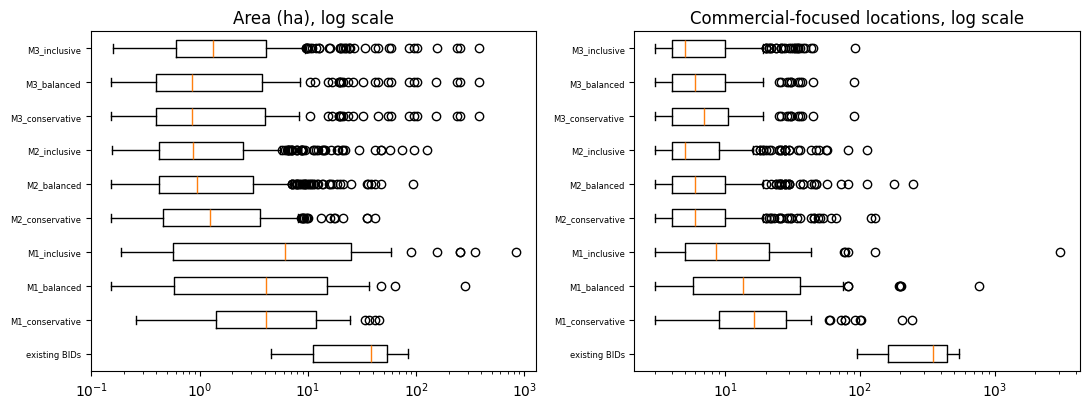

Largest existing BID: 84.5 ha
  M1_conservative: 0 candidate(s) > 5x the largest BID's area, 3 candidate(s) at the minimum-location floor
  M1_balanced: 0 candidate(s) > 5x the largest BID's area, 7 candidate(s) at the minimum-location floor
  M1_inclusive: 1 candidate(s) > 5x the largest BID's area, 7 candidate(s) at the minimum-location floor
  M2_conservative: 0 candidate(s) > 5x the largest BID's area, 54 candidate(s) at the minimum-location floor
  M2_balanced: 0 candidate(s) > 5x the largest BID's area, 52 candidate(s) at the minimum-location floor
  M2_inclusive: 0 candidate(s) > 5x the largest BID's area, 63 candidate(s) at the minimum-location floor
  M3_conservative: 0 candidate(s) > 5x the largest BID's area, 22 candidate(s) at the minimum-location floor
  M3_balanced: 0 candidate(s) > 5x the largest BID's area, 29 candidate(s) at the minimum-location floor
  M3_inclusive: 0 candidate(s) > 5x the largest BID's area, 59 candidate(s) at the minimum-location floor


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
area_data = [bid_stats["area_ha"].values] + [gdf["area_ha"].values for gdf in all_candidates.values()]
loc_data = [bid_stats["n_locations"].values] + [gdf["n_comm_locations"].values for gdf in all_candidates.values()]
tick_labels = ["existing BIDs"] + list(all_candidates.keys())

axes[0].boxplot(area_data, labels=tick_labels, vert=False)
axes[0].set_xscale("log"); axes[0].set_title("Area (ha), log scale"); axes[0].tick_params(axis="y", labelsize=6)
axes[1].boxplot(loc_data, labels=tick_labels, vert=False)
axes[1].set_xscale("log"); axes[1].set_title("Commercial-focused locations, log scale"); axes[1].tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.savefig(DIR_DIAGNOSTICS / "scale_comparison_bids_vs_candidates.png", dpi=DPI_SAVE)
plt.show()

bid_area_max = bid_stats["area_ha"].max()
print(f"Largest existing BID: {bid_area_max:.1f} ha")
for label, gdf in all_candidates.items():
    n_huge = int((gdf["area_ha"] > bid_area_max * 5).sum())
    n_tiny = int((gdf["n_comm_locations"] <= MIN_LOCATIONS_PER_CANDIDATE).sum())
    if n_huge or n_tiny:
        print(f"  {label}: {n_huge} candidate(s) > 5x the largest BID's area, {n_tiny} candidate(s) at the minimum-location floor")


### Interpretation

Most candidate corridors, across all three methods, fall within a plausible range relative to
existing BIDs -- similar order of magnitude in both area and location count, which is
reassuring given that none of the methods was tuned to match BID scale directly. The exceptions
are exactly the giant flatlands components flagged in Sections 6-8: a small number of
candidates, concentrated in the "inclusive" configurations, are considerably larger than any
existing BID. These are not necessarily wrong -- Oakland's flatlands commercial fabric may
genuinely be too continuous to fit inside a single BID-sized box -- but they are exactly the
candidates a City reviewer should look at first when deciding whether a large candidate should
be split into multiple corridors (a question we list explicitly in Section 16).

# Section 12 -- Optional Policy Polygon Comparison

Policy Polygons (Seventh Thrives, West Oakland, Little Saigon, Hegenberger, Beat19x, Fruitvale,
Telegraph Triangle, Old Oakland, Dimond) are pre-existing, researcher/City-defined areas of
planning interest. As stated in Section 1, they are used here only as **contextual, optional
comparison** -- never to define or constrain any of the three methods above. This section is
deliberately the last analytical step, run only after every candidate system already exists.

In [62]:
candidate_footprint = unary_union([unary_union(gdf.geometry.values) for gdf in primary_configs.values() if len(gdf)])

policy_rows = []
for _, row in policy_polygons.iterrows():
    geom = row.geometry
    inter = geom.intersection(candidate_footprint).area
    policy_rows.append(dict(
        policy_name=row.get(name_col, "unknown"),
        policy_area_ha=geom.area / 10000,
        pct_policy_covered_by_candidates=100 * inter / geom.area if geom.area > 0 else 0,
        pct_candidate_footprint_this_policy=100 * inter / candidate_footprint.area if candidate_footprint.area > 0 else 0,
    ))
policy_comparison = pd.DataFrame(policy_rows).sort_values("pct_policy_covered_by_candidates", ascending=False)
policy_comparison.round(1)


,policy_name,policy_area_ha,pct_policy_covered_by_candidates,pct_candidate_footprint_this_policy
3,Hegenberger_BID,462.7,44.1,8.1
8,Dimond,21.6,39.8,0.3
2,Little Saigon,48.0,28.0,0.5
1,West Oakland S,102.6,27.8,1.1
0,Seventh Thrives,60.4,27.0,0.6
4,Beat19x,270.6,20.9,2.2
7,Old_Oakland,52.8,17.9,0.4
6,Telegraph Triangle,28.4,1.2,0.0
5,Fruitvale_BID,38.7,0.1,0.0


In [63]:
total_policy_area = unary_union(policy_polygons.geometry.values).area
total_candidate_area = candidate_footprint.area
both = unary_union(policy_polygons.geometry.values).intersection(candidate_footprint).area
print(f"Total Policy Polygon area: {total_policy_area/10000:,.1f} ha")
print(f"Total candidate footprint area (union of 3 balanced configs): {total_candidate_area/10000:,.1f} ha")
print(f"Overlap (both): {both/10000:,.1f} ha")
print(f"Policy area not covered by any candidate: {(total_policy_area-both)/10000:,.1f} ha")
print(f"Candidate area outside any Policy Polygon: {(total_candidate_area-both)/10000:,.1f} ha")


Total Policy Polygon area: 1,037.8 ha
Total candidate footprint area (union of 3 balanced configs): 2,519.4 ha
Overlap (both): 324.0 ha
Policy area not covered by any candidate: 713.8 ha
Candidate area outside any Policy Polygon: 2,195.4 ha


### Interpretation

We report this comparison for context, not validation: agreement with a Policy Polygon is
interesting background, but the methods were not tuned toward it, and disagreement does not
mean either the candidate or the Policy Polygon is wrong -- they were built for different
purposes. Any Policy Polygon with low candidate coverage is simply an area worth a manual look,
not evidence against the algorithmic candidates.

# Section 13 -- Human Review Packages

**Goal:** turn nine method/parameter configurations into three clearly-derived packages that a
City review session can work through, without hand-drawing any boundary ourselves.

Every package below is built the same mechanical way -- by grid-vote agreement (the same
50 m-grid machinery from Section 10), just over a different *pool* of input configurations and
a different agreement threshold:

- **Package A -- Conservative / Core.** Ground where **at least 2 of the 3 methods'
  balanced configurations** agree. Fewer, tighter, higher-confidence candidates.
- **Package B -- Balanced.** Ground identified by **at least 1 of the 3 methods' balanced
  configurations**. Broader, but still built only from the middle-of-the-road parameter choices.
- **Package C -- Inclusive / Secondary.** Ground identified by **at least 1 of all nine kept
  configurations** (all three methods, all three strictness levels each). This deliberately
  widens the *input pool* rather than just lowering a threshold, so it can surface smaller,
  lower-density neighbourhood corridors that only show up under some method's looser setting.

No package is hand-edited after this point.

In [64]:
def build_agreement_patches(config_gdfs, grid):
    centroids = gpd.GeoDataFrame(geometry=grid.geometry.centroid, crs=grid.crs)
    membership = np.zeros(len(grid), dtype=int)
    for gdf in config_gdfs:
        if len(gdf) == 0:
            continue
        footprint = unary_union(gdf.geometry.values)
        membership += centroids.geometry.within(footprint).to_numpy()
    return grid.assign(membership=membership)


def patches_from_active_grid(grid_with_membership, min_membership):
    active = grid_with_membership[grid_with_membership["membership"] >= min_membership].reset_index(drop=True)
    if len(active) == 0:
        return gpd.GeoDataFrame(columns=["geometry", "max_membership"], crs=grid_with_membership.crs)
    idx_map = {(r, c): i for i, (r, c) in enumerate(zip(active["row"], active["col"]))}
    rr, cc = active["row"].to_numpy(), active["col"].to_numpy()
    offs = [(dr, dc) for dr in (-1, 0, 1) for dc in (-1, 0, 1) if not (dr == 0 and dc == 0)]
    src_list, dst_list = [], []
    for dr, dc in offs:
        nb_idx = np.array([idx_map.get(k, -1) for k in zip(rr + dr, cc + dc)])
        valid = nb_idx >= 0
        src_list.extend(np.where(valid)[0].tolist()); dst_list.extend(nb_idx[valid].tolist())
    n_comp, labels = components_from_pairs(len(active), np.array(src_list), np.array(dst_list))
    active["patch"] = labels
    patches = active.dissolve(by="patch", aggfunc="max").reset_index()
    patches = patches.rename(columns={"membership": "max_membership"})[["patch", "max_membership", "geometry"]]
    patches = patches[patches.geometry.area >= MIN_CANDIDATE_AREA_HA * 10000].reset_index(drop=True)
    return patches


def finalize_package(patches_gdf, prefix, bid_union_geom, agreement_vote_grid):
    if len(patches_gdf) == 0:
        return gpd.GeoDataFrame(columns=["candidate_id", "geometry"], crs=PROJ_CRS)
    out = patches_gdf.copy()
    out["geometry"] = out.geometry.difference(bid_union_geom)  # defensive re-clip against BID territory
    out = out[~out.geometry.is_empty].reset_index(drop=True)
    out["candidate_id"] = [f"{prefix}{i+1:02d}" for i in range(len(out))]
    metrics = compute_candidate_metrics(out[["candidate_id", "geometry"]])
    metrics = metrics[metrics["n_comm_locations"] >= MIN_LOCATIONS_PER_CANDIDATE].reset_index(drop=True)
    # agreement across the three primary (balanced) method configurations, for provenance
    centroids = gpd.GeoDataFrame(geometry=metrics.geometry.centroid, crs=PROJ_CRS)
    j = gpd.sjoin(centroids.reset_index().rename(columns={"index": "_i"}),
                  agreement_vote_grid[["row", "col", "agreement_count", "geometry"]], how="left", predicate="within")
    j = j.drop_duplicates("_i").set_index("_i")["agreement_count"]
    metrics["n_methods_agreeing"] = j.reindex(metrics.index).fillna(0).astype(int)
    metrics["flagged_bid_overlap"] = metrics["pct_overlap_bid"] > BID_RESIDUAL_OVERLAP_PCT_FLAG
    return gpd.GeoDataFrame(metrics, geometry="geometry", crs=PROJ_CRS)


In [65]:
# Package A: >=2-of-3 balanced-configuration agreement (reuses Section 10's vote directly)
patches_a = patches_from_active_grid(agreement_grid.rename(columns={"agreement_count": "membership"}), min_membership=2)
package_a = finalize_package(patches_a, "A", bid_union, agreement_grid)

# Package B: >=1-of-3 balanced-configuration agreement
patches_b = patches_from_active_grid(agreement_grid.rename(columns={"agreement_count": "membership"}), min_membership=1)
package_b = finalize_package(patches_b, "B", bid_union, agreement_grid)

# Package C: >=1-of-9 kept configurations (all three strictness levels, all three methods)
grid_all_configs = build_agreement_patches(list(all_candidates.values()), agreement_grid[["row", "col", "geometry"]])
patches_c = patches_from_active_grid(grid_all_configs, min_membership=1)
package_c = finalize_package(patches_c, "C", bid_union, agreement_grid)

for name, pkg in [("Package A (Conservative/Core)", package_a), ("Package B (Balanced)", package_b), ("Package C (Inclusive/Secondary)", package_c)]:
    print(f"{name}: {len(pkg)} candidate districts, "
          f"{pkg['n_comm_locations'].sum() if len(pkg) else 0:.0f} commercial-focused locations captured, "
          f"{pkg['area_ha'].sum() if len(pkg) else 0:,.0f} ha total")


Package A (Conservative/Core): 153 candidate districts, 1854 commercial-focused locations captured, 714 ha total
Package B (Balanced): 223 candidate districts, 2429 commercial-focused locations captured, 2,270 ha total
Package C (Inclusive/Secondary): 244 candidate districts, 2536 commercial-focused locations captured, 2,356 ha total


### Package contents

Each package row carries a stable candidate ID, area, physical business-location and entity
counts, dominant broad sector, sector diversity, relevant/business-containing parcel counts,
distance to the nearest BID, and how many of the three methods' balanced configurations agree
on that ground -- everything needed for a reviewer to open the map and the table side by
side.

In [66]:
review_columns = ["candidate_id", "area_ha", "n_comm_locations", "n_entities", "dominant_sector",
                   "n_sectors", "n_parcels", "n_business_parcels", "dist_to_bid_m", "n_methods_agreeing",
                   "compactness", "elongation_ratio", "flagged_bid_overlap"]
package_a[review_columns].round(1).head(10)


,candidate_id,area_ha,n_comm_locations,n_entities,dominant_sector,n_sectors,n_parcels,n_business_parcels,dist_to_bid_m,n_methods_agreeing,compactness,elongation_ratio,flagged_bid_overlap
0,A01,5.0,14.0,22.0,Retail Trade,8.0,25,22,5257.9,2,0.2,1.6,False
1,A02,26.2,28.0,76.0,Other Services,11.0,44,32,4586.6,2,0.1,1.5,False
2,A04,43.8,78.0,441.0,"Finance, Insurance & Real Estate",13.0,75,54,3157.1,0,0.0,2.3,False
3,A07,19.2,30.0,102.0,"Finance, Insurance & Real Estate",11.0,33,24,3286.0,0,0.1,2.5,False
4,A08,2.8,3.0,4.0,Accommodation & Food Services,3.0,1,1,3722.2,3,0.3,2.1,False
5,A09,21.2,25.0,81.0,"Finance, Insurance & Real Estate",9.0,24,22,3387.9,0,0.1,1.4,False
6,A10,71.8,32.0,100.0,Wholesale Trade,11.0,26,23,1967.8,2,0.1,1.0,False
7,A11,8.8,11.0,24.0,Manufacturing,5.0,10,10,2933.0,3,0.2,1.8,False
8,A13,4.2,10.0,18.0,"Finance, Insurance & Real Estate",5.0,16,10,4803.0,2,0.2,1.7,False
9,A14,0.5,3.0,7.0,Construction,3.0,5,5,5204.6,0,0.4,2.0,False


# Section 14 -- Review Maps

The maps below are built for a working meeting, not a publication: consistent citywide
extents, BIDs always visible as context, and no attempt to cram every candidate ID onto a
citywide map (candidate tables carry the IDs; the maps carry the shapes).

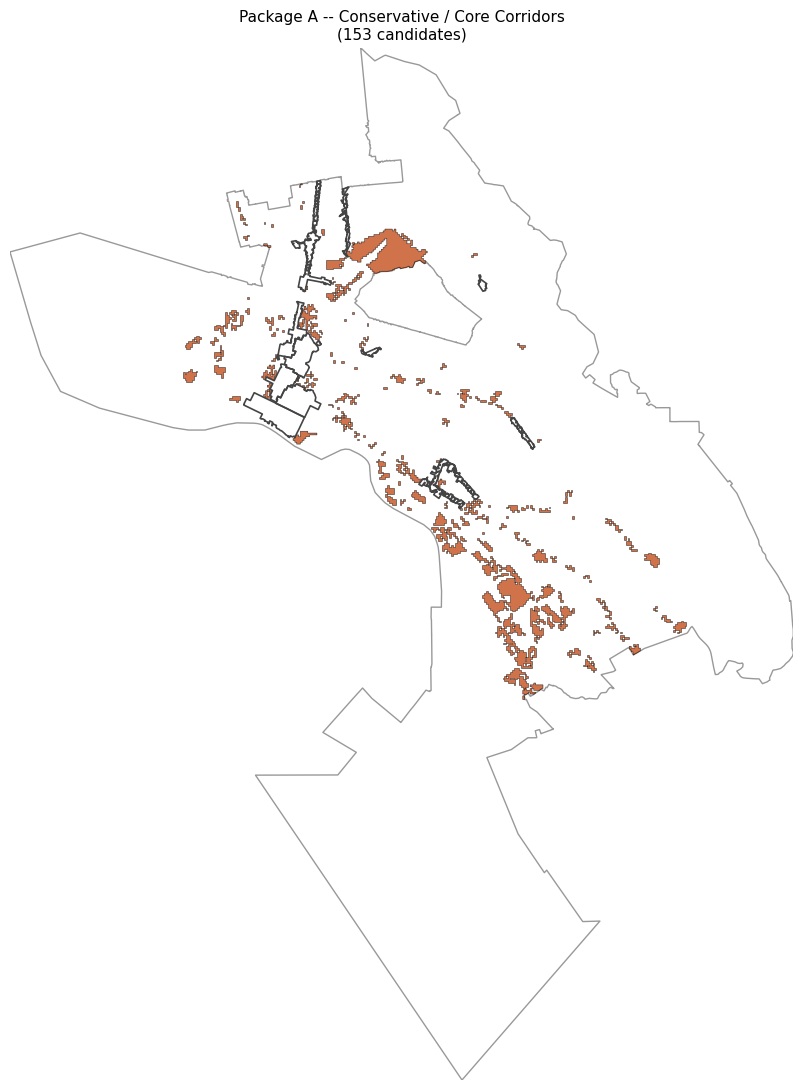

In [67]:
CITY_BOUNDS = oakland.total_bounds

def plot_package_citywide(ax, package_gdf, color, title):
    oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=1)
    bids.plot(ax=ax, facecolor="none", edgecolor=BID_COLOR, linewidth=1.2, zorder=3)
    if len(package_gdf):
        package_gdf.plot(ax=ax, color=color, edgecolor="black", linewidth=0.4, alpha=0.75, zorder=2)
    ax.set_xlim(CITY_BOUNDS[0], CITY_BOUNDS[2]); ax.set_ylim(CITY_BOUNDS[1], CITY_BOUNDS[3])
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
plot_package_citywide(ax, package_a, "#c1440e", f"Package A -- Conservative / Core Corridors\n({len(package_a)} candidates)")
plt.tight_layout()
plt.savefig(DIR_REVIEW / "map_package_a_citywide.png", dpi=DPI_SAVE)
plt.show()


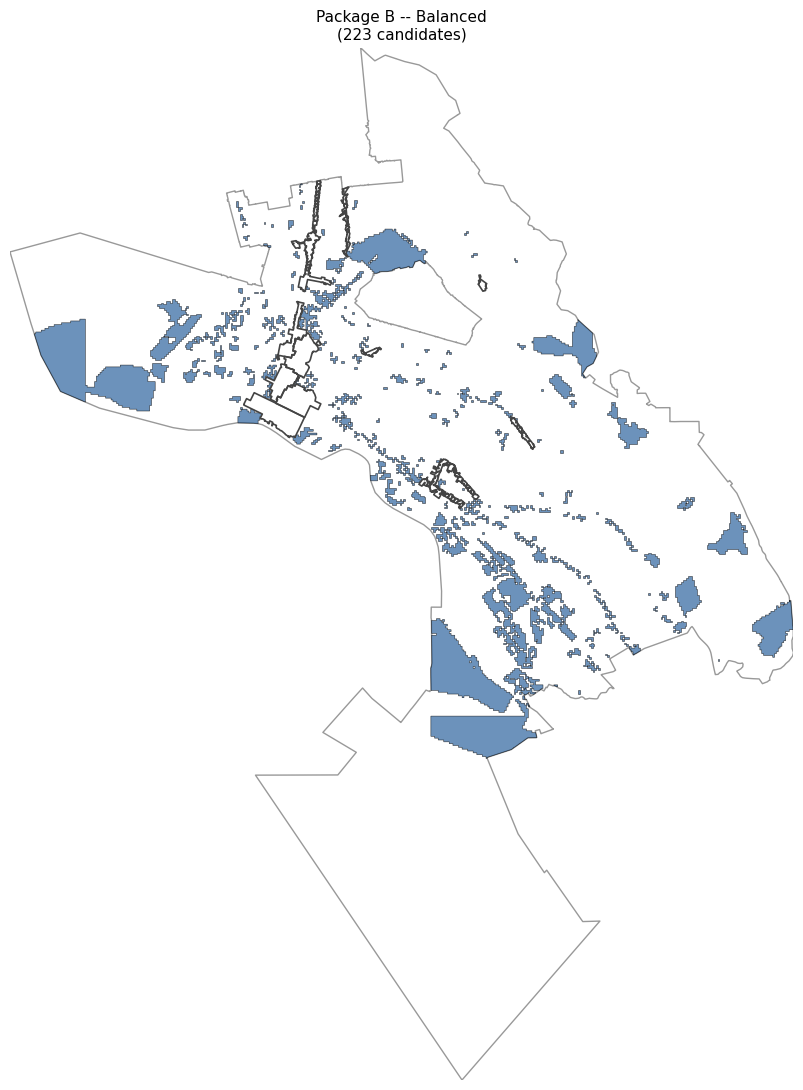

In [68]:
fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
plot_package_citywide(ax, package_b, "#3b6ea5", f"Package B -- Balanced\n({len(package_b)} candidates)")
plt.tight_layout()
plt.savefig(DIR_REVIEW / "map_package_b_citywide.png", dpi=DPI_SAVE)
plt.show()


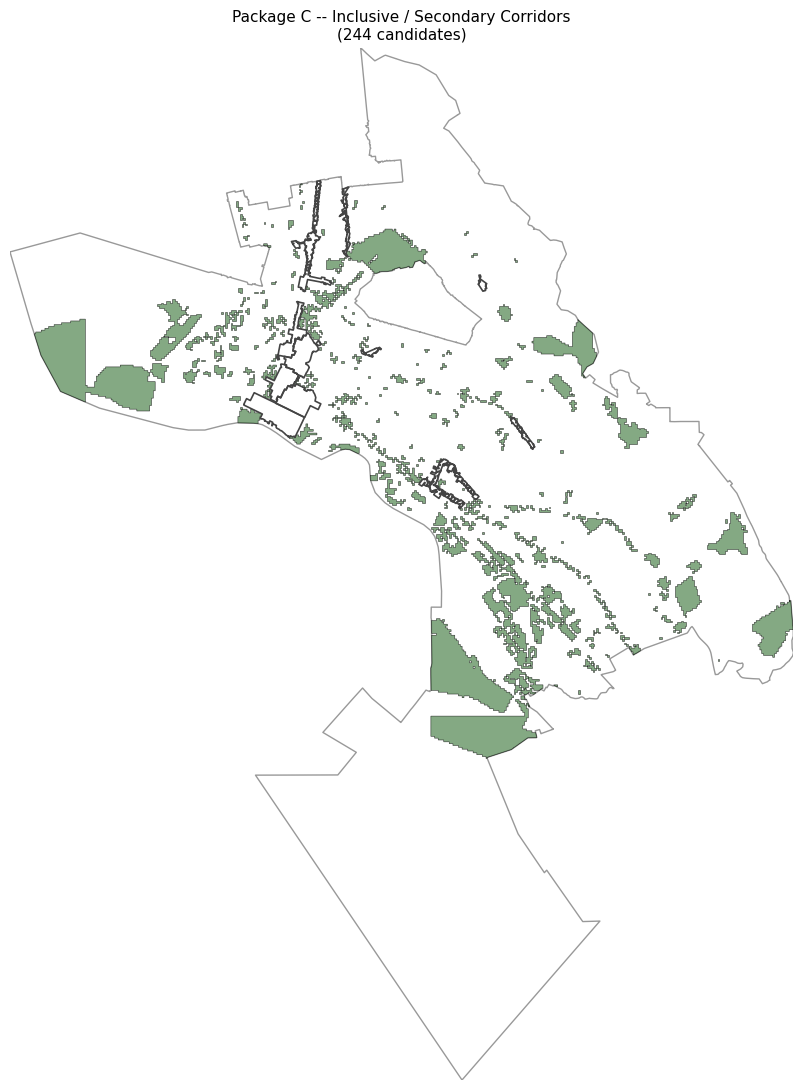

In [69]:
fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
plot_package_citywide(ax, package_c, "#5b8c5a", f"Package C -- Inclusive / Secondary Corridors\n({len(package_c)} candidates)")
plt.tight_layout()
plt.savefig(DIR_REVIEW / "map_package_c_citywide.png", dpi=DPI_SAVE)
plt.show()


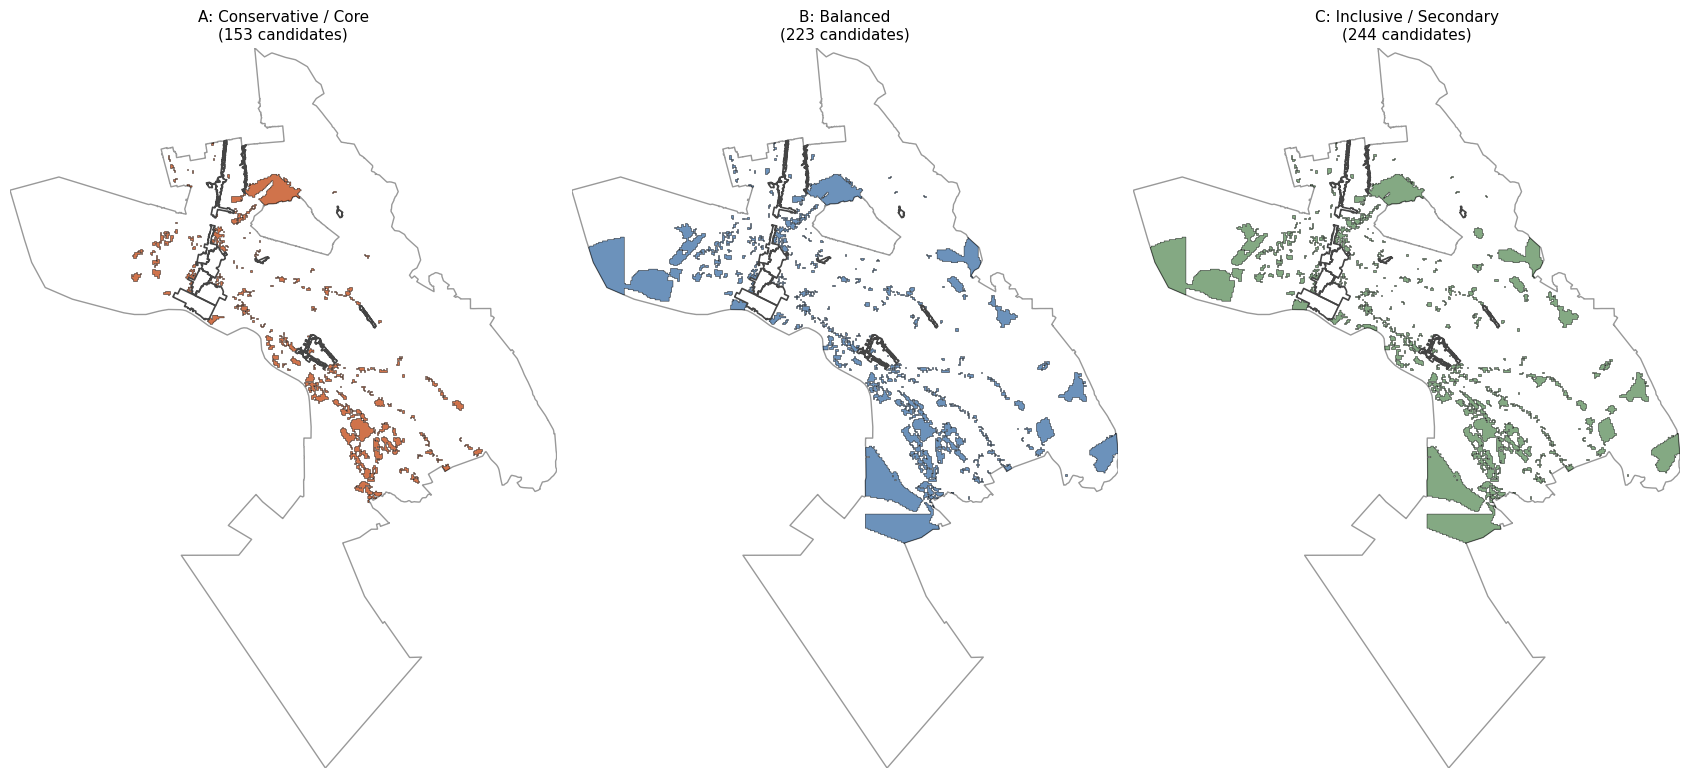

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(17, 8))
for ax, pkg, color, title in zip(axes, [package_a, package_b, package_c], ["#c1440e", "#3b6ea5", "#5b8c5a"],
                                   ["A: Conservative / Core", "B: Balanced", "C: Inclusive / Secondary"]):
    plot_package_citywide(ax, pkg, color, f"{title}\n({len(pkg)} candidates)")
plt.tight_layout()
plt.savefig(DIR_REVIEW / "map_three_package_comparison.png", dpi=DPI_SAVE)
plt.show()


### Interpretation

Package A is visibly the most conservative -- a handful of tight, high-confidence districts.
Package C is the most expansive, picking up smaller neighbourhood nodes that A and B miss
entirely, at the cost of also carrying forward the largest, least-certain candidates. Package B
sits in between and is the most reasonable single starting point for a first review pass, with
A and C available as "narrower" and "wider" alternate readings of the same underlying data.

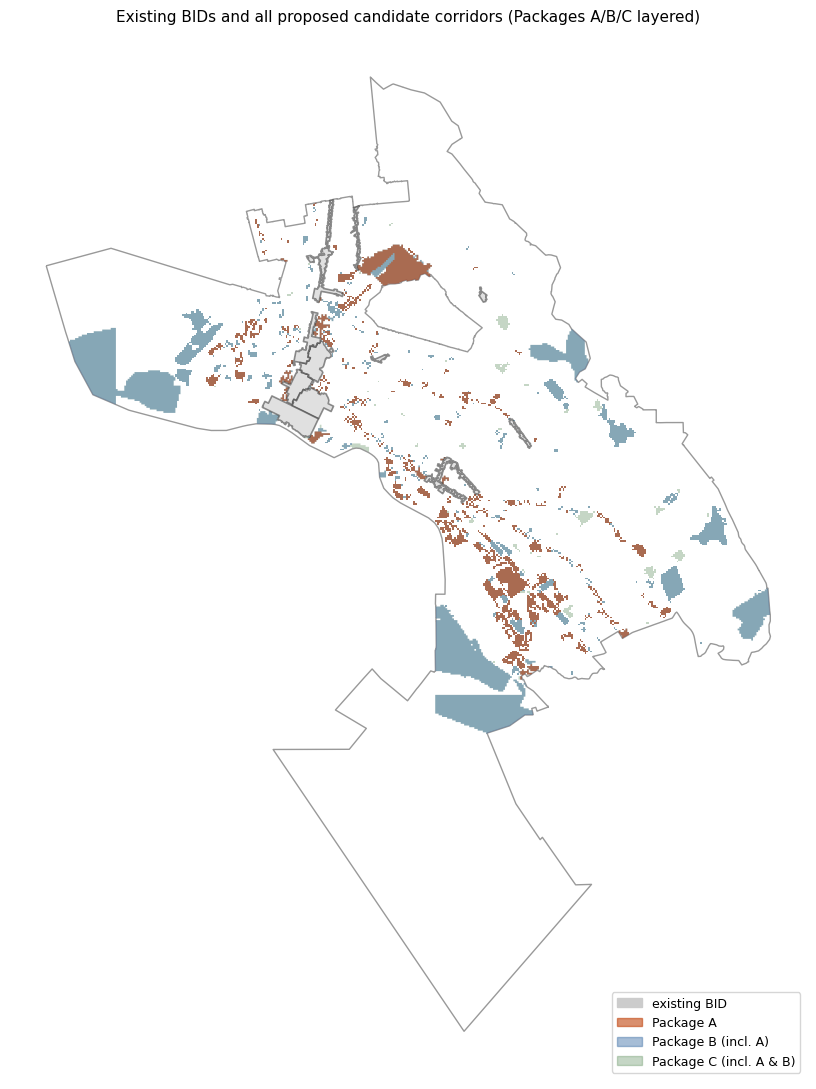

In [71]:
fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=1)
bids.plot(ax=ax, facecolor="#cccccc", edgecolor=BID_COLOR, linewidth=1.2, alpha=0.6, zorder=3, label="existing BID")
package_c.plot(ax=ax, color="#5b8c5a", alpha=0.35, edgecolor="none", zorder=1)
package_b.plot(ax=ax, color="#3b6ea5", alpha=0.45, edgecolor="none", zorder=2)
package_a.plot(ax=ax, color="#c1440e", alpha=0.6, edgecolor="none", zorder=2)
ax.set_title("Existing BIDs and all proposed candidate corridors (Packages A/B/C layered)", fontsize=11)
ax.set_axis_off()
handles = [mpatches.Patch(color="#cccccc", label="existing BID"),
           mpatches.Patch(color="#c1440e", alpha=0.6, label="Package A"),
           mpatches.Patch(color="#3b6ea5", alpha=0.45, label="Package B (incl. A)"),
           mpatches.Patch(color="#5b8c5a", alpha=0.35, label="Package C (incl. A & B)")]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(DIR_REVIEW / "map_bids_and_all_candidates.png", dpi=DPI_SAVE)
plt.show()


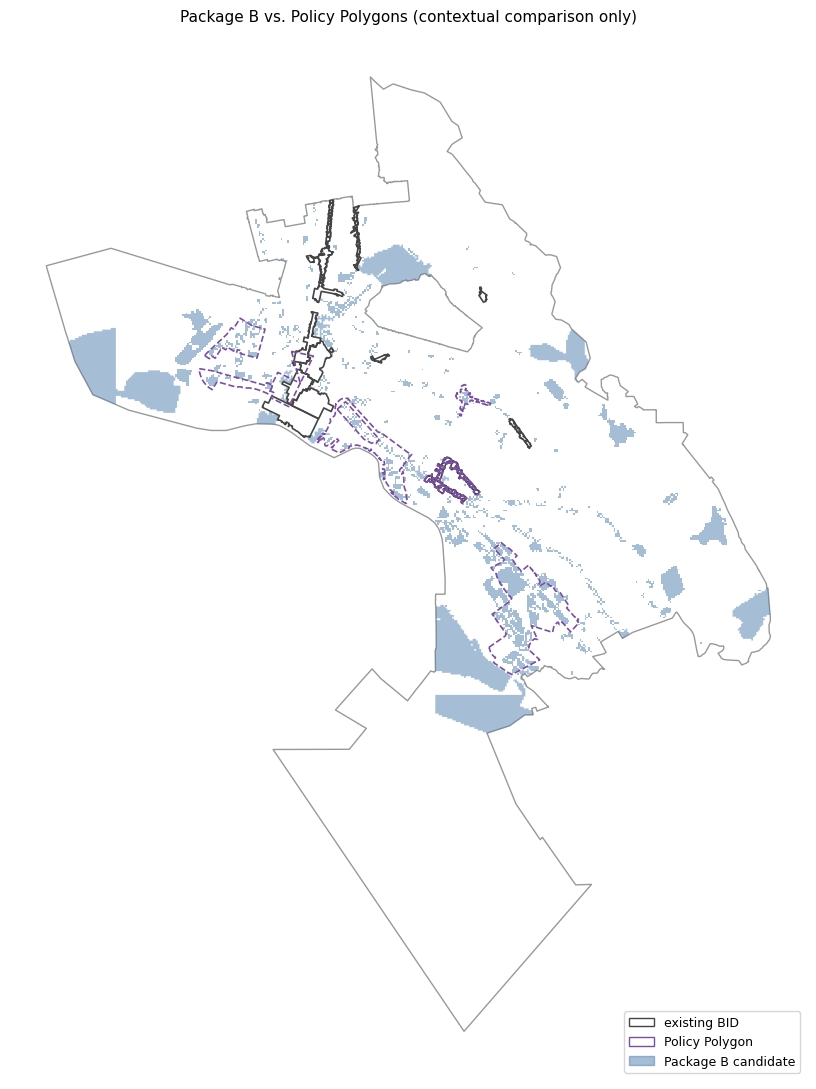

In [72]:
fig, ax = plt.subplots(figsize=FIGSIZE_CITYWIDE)
oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=1)
bids.plot(ax=ax, facecolor="none", edgecolor=BID_COLOR, linewidth=1.2, zorder=3)
policy_polygons.plot(ax=ax, facecolor="none", edgecolor="#7a4fa3", linewidth=1.2, linestyle="--", zorder=3)
package_b.plot(ax=ax, color="#3b6ea5", alpha=0.45, edgecolor="none", zorder=2)
ax.set_title("Package B vs. Policy Polygons (contextual comparison only)", fontsize=11)
ax.set_axis_off()
handles = [mpatches.Patch(facecolor="none", edgecolor=BID_COLOR, label="existing BID"),
           mpatches.Patch(facecolor="none", edgecolor="#7a4fa3", label="Policy Polygon"),
           mpatches.Patch(color="#3b6ea5", alpha=0.45, label="Package B candidate")]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(DIR_REVIEW / "map_policy_polygon_comparison.png", dpi=DPI_SAVE)
plt.show()


### Zoomed view -- Downtown / Central Oakland

Downtown is where BID density, candidate density, and the giant-component problem all overlap
most heavily, which makes a zoomed view materially more useful there than a citywide map alone.
We do not add further zooms for North or East Oakland -- at the citywide scale above, those
areas already read clearly enough (fewer, more separated candidates) that a zoom does not add
much beyond what Package B's citywide map already shows.

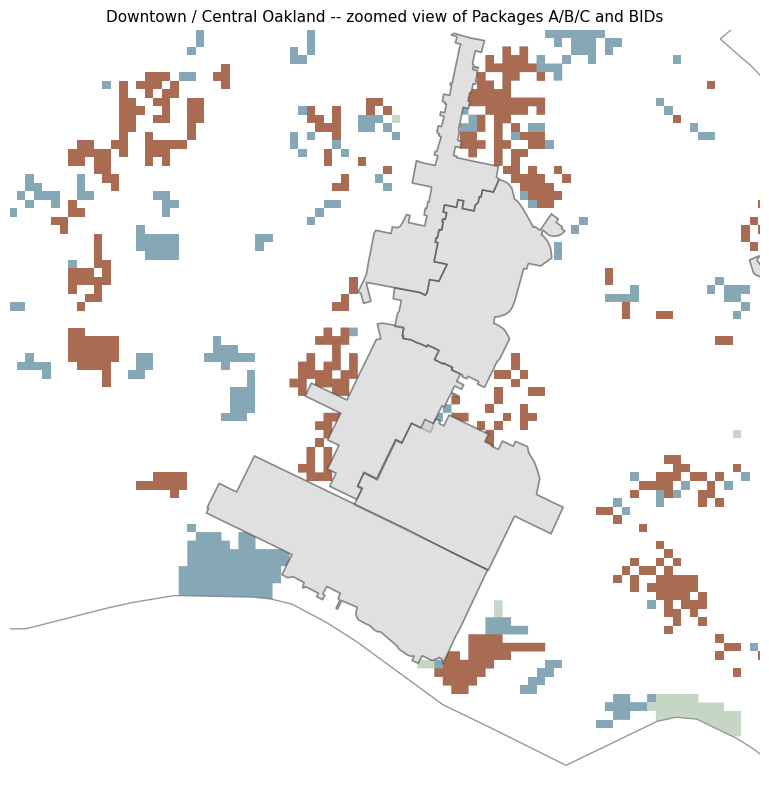

In [73]:
downtown_center = bids.loc[bids["BID"] == "Downtown", "geometry"].iloc[0].centroid if (bids["BID"] == "Downtown").any() else oakland_boundary.centroid
zoom_half_width = 2200
minx, maxx = downtown_center.x - zoom_half_width, downtown_center.x + zoom_half_width
miny, maxy = downtown_center.y - zoom_half_width, downtown_center.y + zoom_half_width

fig, ax = plt.subplots(figsize=(8, 8))
oakland.boundary.plot(ax=ax, color=OAKLAND_EDGE_COLOR, linewidth=1)
bids.plot(ax=ax, facecolor="#cccccc", edgecolor=BID_COLOR, linewidth=1.2, alpha=0.6, zorder=3)
package_c.cx[minx:maxx, miny:maxy].plot(ax=ax, color="#5b8c5a", alpha=0.35, edgecolor="none", zorder=1)
package_b.cx[minx:maxx, miny:maxy].plot(ax=ax, color="#3b6ea5", alpha=0.45, edgecolor="none", zorder=2)
package_a.cx[minx:maxx, miny:maxy].plot(ax=ax, color="#c1440e", alpha=0.6, edgecolor="none", zorder=2)
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
ax.set_title("Downtown / Central Oakland -- zoomed view of Packages A/B/C and BIDs", fontsize=11)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIR_REVIEW / "map_downtown_zoom.png", dpi=DPI_SAVE)
plt.show()


# Section 15 -- Exports

Everything this notebook produces lives under `data/corridors/260910_report/`. Method-specific
candidate layers were already written to disk in Sections 6-8 as they were built; this section
writes the final review packages and the cross-cutting comparison/lookup tables.

In [74]:
package_a.to_file(DIR_REVIEW / "corridor_package_a.gpkg", driver="GPKG")
package_b.to_file(DIR_REVIEW / "corridor_package_b.gpkg", driver="GPKG")
package_c.to_file(DIR_REVIEW / "corridor_package_c.gpkg", driver="GPKG")

lookup_cols = ["candidate_id", "area_ha", "perimeter_m", "compactness", "elongation_ratio",
               "n_locations", "n_entities", "n_comm_locations", "dominant_sector", "n_sectors",
               "n_parcels", "n_business_parcels", "n_usecode_parcels", "locations_per_ha",
               "pct_relevant_parcel_area_with_business", "dist_to_bid_m", "pct_overlap_bid",
               "flagged_bid_overlap", "n_methods_agreeing"]

lookup_rows = []
for pkg_name, pkg in [("A", package_a), ("B", package_b), ("C", package_c)]:
    if len(pkg) == 0:
        continue
    tmp = pkg[lookup_cols].copy()
    tmp.insert(0, "package", pkg_name)
    lookup_rows.append(tmp)
corridor_packages_summary = pd.concat(lookup_rows, ignore_index=True)
corridor_packages_summary.to_csv(DIR_REVIEW / "corridor_packages_summary.csv", index=False)
print(f"Saved {len(corridor_packages_summary)} candidate-corridor rows across all three packages")
corridor_packages_summary.head(10)


Saved 620 candidate-corridor rows across all three packages


,package,candidate_id,area_ha,perimeter_m,compactness,elongation_ratio,n_locations,n_entities,n_comm_locations,dominant_sector,n_sectors,n_parcels,n_business_parcels,n_usecode_parcels,locations_per_ha,pct_relevant_parcel_area_with_business,dist_to_bid_m,pct_overlap_bid,flagged_bid_overlap,n_methods_agreeing
0,A,A01,5.000000,2000.000000,0.157080,1.600001,14.0,22.0,14.0,Retail Trade,8.0,25,22,4,2.800000,88.000000,5257.928860,0.0,False,2
1,A,A02,26.164861,6807.557943,0.070949,1.473684,28.0,76.0,28.0,Other Services,11.0,44,32,25,1.070138,72.727273,4586.559238,0.0,False,2
2,A,A04,43.750000,12600.000000,0.034630,2.261683,78.0,441.0,78.0,"Finance, Insurance & Real Estate",13.0,75,54,49,1.782857,72.000000,3157.126398,0.0,False,0
3,A,A07,19.250000,5100.000000,0.093004,2.500000,31.0,102.0,30.0,"Finance, Insurance & Real Estate",11.0,33,24,19,1.610390,72.727273,3285.951527,0.0,False,0
4,A,A08,2.750000,1000.000000,0.345575,2.062500,3.0,4.0,3.0,Accommodation & Food Services,3.0,1,1,0,1.090909,100.000000,3722.197126,0.0,False,3
5,A,A09,21.250000,5500.000000,0.088276,1.374149,26.0,81.0,25.0,"Finance, Insurance & Real Estate",9.0,24,22,3,1.223529,91.666667,3387.915016,0.0,False,0
6,A,A10,71.750000,10600.000000,0.080245,1.024039,32.0,100.0,32.0,Wholesale Trade,11.0,26,23,5,0.445993,88.461538,1967.804499,0.0,False,2
7,A,A11,8.750000,2600.000000,0.162656,1.781815,11.0,24.0,11.0,Manufacturing,5.0,10,10,0,1.257143,100.000000,2933.031403,0.0,False,3
8,A,A13,4.250000,1600.000000,0.208621,1.652172,11.0,18.0,10.0,"Finance, Insurance & Real Estate",5.0,16,10,11,2.588235,62.500000,4802.972193,0.0,False,2
9,A,A14,0.500000,400.000000,0.392699,1.999986,3.0,7.0,3.0,Construction,3.0,5,5,0,6.000000,100.000000,5204.566763,0.0,False,0


In [75]:
# comparisons/method_configuration_summary.csv and comparisons/corridor_method_agreement.gpkg
# were already written in Sections 9 and 10. Confirm everything landed where expected.
for f in sorted(OUT_DIR.rglob("*")):
    if f.is_file():
        print(f.relative_to(OUT_DIR))


comparisons/corridor_method_agreement.gpkg
comparisons/cross_method_comparison.png
comparisons/method_agreement_map.png
comparisons/method_configuration_summary.csv
diagnostics/bid_scale_reference.csv
diagnostics/business_density_hexbin.png
diagnostics/nearest_neighbour_distances.png
diagnostics/outside_bid_locations.png
diagnostics/parcel_business_diagnostics.png
diagnostics/parcels_and_businesses_overview.png
diagnostics/scale_comparison_bids_vs_candidates.png
method_1_grid/grid_to_parcel_examples.png
method_1_grid/method1_M1_balanced.gpkg
method_1_grid/method1_M1_conservative.gpkg
method_1_grid/method1_M1_inclusive.gpkg
method_1_grid/method1_sensitivity_plots.png
method_1_grid/method1_sensitivity_sweep.csv
method_1_grid/method1_three_configs_citywide.png
method_1_grid/smoothing_comparison_75m.png
method_2_business_clusters/cluster_to_parcel_examples.png
method_2_business_clusters/method2_M2_balanced.gpkg
method_2_business_clusters/method2_M2_conservative.gpkg
method_2_business_clust

# Section 16 -- Final Notebook Summary

## What we learned

**Location vs. entity counts matter, a lot.** Almost half of Oakland's ~37,700 business
locations belong to a majority-office/professional/FIRE-sector universe, and about half of
*that* turns out to be property/rental-license paperwork rather than an operating business at a
storefront. Using unique physical locations (Universe B, outside BIDs: ~15,250 locations) as the
spatial unit, instead of raw entity counts, materially changes what "dense" means -- a single
multi-tenant building with 700 registered entities is one location, not 700 independent
signals.

**Every method finds a version of the same giant-flatlands problem.** DBSCAN (Method 2)
fuses the downtown-through-Fruitvale flatlands into a multi-thousand-location mega-cluster at
any practical `eps`; the grid (Method 1) does the same in raster form at moderate thresholds
with gap-bridging on; and even the parcel-native seed-and-grow (Method 3) -- despite a hard
rule against ever bridging through a zero-evidence parcel -- still produces a few large,
irreducible components in the same area. This is not a bug in any one method; it is a real
property of Oakland's commercial geography that any transparent, contiguity-based approach will
keep re-discovering. We flag it everywhere rather than solving it once and hoping it goes away.

**Parameter choices trade off capture against corridor scale, everywhere.** In all three
methods, looser thresholds/distances predictably raise both business-location capture and the
largest-candidate's share of total area, together. There is no parameter setting found in this
notebook that maximizes coverage *and* avoids at least one unusually large candidate.

**Parcels are what turns a detection signal into a usable shape.** Grid cells and DBSCAN
clusters are good at *finding* concentration; neither produces a shape a planner would recognize
as a corridor on its own. Every method here ends by converting to real parcel geometry, and the
resulting boundaries visibly trace lot lines and street frontage rather than raster edges or
circular buffers.

**BIDs matter as an exclusion and as a scale reference, not as a template.** Removing BID
territory up front (about 9% of all business locations) kept every method focused on the ~91%
of Oakland's commercial geography that has no existing district. Comparing candidate scale to
existing BID scale (Section 11) was useful for flagging implausible outputs, without ever
constraining the methods to match BID sizes directly.

## Candidate packages

- **Package A -- Conservative / Core**: ground where at least 2 of the 3 methods' balanced
  configurations agree. The fewest, tightest, highest-confidence candidates -- a reasonable
  floor of "almost certainly real" commercial concentration outside existing BIDs.
- **Package B -- Balanced**: ground identified by any one of the three methods' balanced
  configurations. Broader coverage of Oakland's non-BID commercial activity, while still built
  only from middle-of-the-road parameter choices -- the most reasonable single starting point
  for a first review pass.
- **Package C -- Inclusive / Secondary**: ground identified by any of all nine kept
  configurations (every method, every strictness level). Captures smaller, lower-density
  neighbourhood corridors that a stricter reading would miss entirely, at the cost of also
  carrying forward the least certain, largest candidates.

## Questions for City of Oakland review

- Does this candidate correspond to a recognizable commercial district or street you already
  think of as one?
- Should this candidate be split into multiple corridors (especially the largest, flagged
  candidates in Sections 6-8 and 11)?
- Should adjacent candidates -- especially ones separated only by a single street -- be merged?
- Does the boundary extend too far down a street beyond where the actual commercial activity
  stops?
- Are there important neighbourhood commercial streets that all three methods still miss
  entirely (Section 10's "category D" -- visible density, no stable candidate)?
- Are industrial/logistics-heavy areas being treated appropriately, or should they be handled
  as a different kind of district altogether?
- Are some of Package C's smaller, lower-density candidates locally important despite weak
  citywide business density?
- Are there places immediately outside an existing BID that should stay distinct from it,
  rather than reading as an extension of it?
- Which kinds of parcels should or should not be allowed to "bridge" a gap between two
  clearly-commercial areas (Sections 6.5, 7.3, 8.4)?
- At what point does a cluster of businesses stop being a corridor and start being better
  described as a single commercial node or shopping center?

## Recommended next methodological step

We do not recommend picking one method as "best." Based on this exploration:

- **Method 3 (parcel seed-and-grow) seems most useful as a base** for further refinement -- its
  geometry is the most directly parcel-native, its scoring logic is the most transparent line
  by line, and its growth rule (never bridge through zero-evidence parcels) is the most
  defensible in front of a room of planners.
- **Method 1 (the grid)** is the most useful *check* on Method 3, because it approaches the same
  question from an entirely different mechanism (raster density and continuity, no seed
  concept at all) -- where the two agree (Section 10), that agreement is genuinely informative
  about robustness rather than an artifact of a shared assumption.
- **Method 2 (business clusters)** is the most useful for surfacing smaller, business-driven
  nodes that a parcel-use-code view might underweight, even though its mega-cluster tendency
  makes it the least reliable of the three for the biggest candidates.

What remains genuinely unresolved, and is exactly the kind of judgment this notebook is meant
to hand off rather than automate: where the giant flatlands components should actually be cut
into multiple distinct corridors; which specific bridging parcels should or should not count;
and which small, low-density Package-C candidates reflect a real, locally-important commercial
street versus statistical noise. Those are the questions worth spending the review session on.